In [2]:
"""
FASE 1: Modelo Acoplado Completo + Gravedad
===========================================
Basado en Avilés-Rojas & Hurtado (2025) - JMPS

Ecuaciones:
1. Equilibrio: Div(F·S) + ρ·g = 0                     (Eq. 52 + gravedad)
2. Conservación masa: ∂Φ/∂t + Div(Q) = 0              (Eq. 53)
3. Evolución surfactante: ∂M_surf/∂t = Λ              (Eq. 54)
"""

import os
os.environ["OMP_NUM_THREADS"] = "1"

import firedrake as fd
import numpy as np
from firedrake.output import VTKFile
import matplotlib.pyplot as plt

fd.parameters["form_compiler"]["quadrature_degree"] = 6

# ============================================================
# 1. PARÁMETROS DEL MODELO
# ============================================================

# Geometría alveolar
Phi_R = 0.74
R_RI = 0.11

# Material Fung
c_fung = 2.5
a_fung = 0.433
b_fung = -0.61

# Surfactante
gamma_0 = 70.0e-6
gamma_inf = 22.2e-6
gamma_min = 0.0
Gamma_inf = 3.0e-9
m1 = 47.8e-6
m2 = 140.0e-6

# Cinética
k1 = 1.6e8
k2 = 0.016
c_bulk = 1.0e-9

# Darcy
kappa = 1.0e-6
mu_air = 1.8e-8
K_darcy = kappa / mu_air

Gamma_max = Gamma_inf * (1.0 + (gamma_inf - gamma_min) / m2)

# ============================================================
# GRAVEDAD (NUEVO)
# ============================================================

# Densidad del tejido pulmonar
# ρ ≈ 300-400 kg/m³ (pulmón inflado con aire)
# En unidades mm: ρ = 350 kg/m³ = 350e-9 g/mm³ = 3.5e-7 g/mm³
# Para kPa y mm: necesitamos ρ en kg/mm³ → 350e-9 kg/mm³

rho_tissue = 350e-9   # kg/mm³ (densidad del tejido pulmonar)

# Gravedad
g_val = 9810.0        # mm/s² (9.81 m/s² = 9810 mm/s²)

# Vector gravedad (hacia -y en 2D)
# En configuración supina: gravedad en dirección -y
# En configuración prona: gravedad en dirección +y
gravity_direction = fd.Constant((0.0, -1.0))  # Supino (acostado boca arriba)

print("="*60)
print("FASE 1: MODELO ACOPLADO + GRAVEDAD")
print("="*60)
print(f"Φ_R = {Phi_R}, R_I = {R_RI} mm")
print(f"Fung: c = {c_fung} kPa")
print(f"Gravedad:")
print(f"  ρ = {rho_tissue*1e9:.1f} kg/m³")
print(f"  g = {g_val/1000:.2f} m/s²")
print(f"  Dirección: {gravity_direction.values()}")

# Tiempo
T_total = 2.0
dt_val = 0.05
n_steps = int(T_total / dt_val)

print(f"Tiempo: T = {T_total} s, dt = {dt_val} s, pasos = {n_steps}")

# ============================================================
# 2. MALLA Y ESPACIOS
# ============================================================

Lx, Ly = 10.0, 10.0
nx, ny = 20, 20

mesh = fd.RectangleMesh(nx, ny, Lx, Ly)
print(f"\nMalla: {nx}x{ny} elementos, dominio {Lx}x{Ly} mm")

V_u = fd.VectorFunctionSpace(mesh, "CG", 2)
V_P = fd.FunctionSpace(mesh, "CG", 1)
V_M = fd.FunctionSpace(mesh, "DG", 0)

W = V_u * V_P * V_M

w = fd.Function(W)
w_old = fd.Function(W)

u, P_alv, M_surf = fd.split(w)
u_old, P_alv_old, M_surf_old = fd.split(w_old)

v_u, v_P, v_M = fd.TestFunctions(W)

u_out = fd.Function(V_u, name="Displacement")
P_out = fd.Function(V_P, name="Pressure")
M_out = fd.Function(V_M, name="Surfactant_Mass")
Gamma_out = fd.Function(V_M, name="Surfactant_Concentration")
gamma_out = fd.Function(V_M, name="Surface_Tension")

coords_initial = mesh.coordinates.dat.data_ro.copy()

print(f"  DoFs total: {W.dim()}")

# ============================================================
# 3. PARÁMETROS DE TIEMPO
# ============================================================

dt = fd.Constant(dt_val)
t = fd.Constant(0.0)
P_max = fd.Constant(1.0)

# ============================================================
# 4. CINEMÁTICA Y CONSTITUTIVO
# ============================================================

dim = mesh.geometric_dimension()
I = fd.Identity(dim)

F = I + fd.grad(u)
J = fd.det(F)
C = F.T * F
invC = fd.inv(C)

E = fd.variable(0.5 * (C - I))

J1 = fd.tr(E)
J2 = 0.5 * (fd.tr(E)**2 - fd.tr(E * E))

Psi_el = c_fung * (fd.exp(a_fung * J1**2 + b_fung * J2) - 1.0)
S_el = fd.diff(Psi_el, E)

Phi = fd.max_value(J - 1.0 + Phi_R, 1e-4)
Phi_old = fd.max_value(fd.det(I + fd.grad(u_old)) - 1.0 + Phi_R, 1e-4)

A_density = (3.0 / R_RI) * (Phi_R**(1.0/3.0)) * (Phi**(2.0/3.0))

Gamma = M_surf / fd.max_value(A_density, 1e-12)

ratio = Gamma / Gamma_inf
gamma_lang = gamma_0 - m1 * ratio
gamma_insol = gamma_inf - m2 * (ratio - 1.0)
gamma_surf = fd.conditional(fd.lt(Gamma, Gamma_inf), gamma_lang, gamma_insol)
gamma_surf = fd.max_value(gamma_surf, gamma_min)

P_gamma = (2.0 * gamma_surf / R_RI) * ((Phi_R / Phi)**(1.0/3.0))

S_total = S_el + (P_gamma - P_alv) * J * invC

# ============================================================
# 5. FLUJO DE DARCY
# ============================================================

Q_darcy = -K_darcy * invC * fd.grad(P_alv)

# ============================================================
# 6. CINÉTICA DEL SURFACTANTE
# ============================================================

Gamma_safe = fd.max_value(Gamma, 0.0)
Lambda_kinetics = k1 * c_bulk * fd.max_value(Gamma_inf - Gamma_safe, 0.0) - k2 * Gamma_safe

# ============================================================
# 7. FUERZA DE GRAVEDAD
# ============================================================

rho_R = fd.Constant(rho_tissue)  # Densidad de referencia
g_vec = g_val * gravity_direction  # Vector gravedad [mm/s²]

# Fuerza de cuerpo en config. referencia (por unidad de volumen ref.)
body_force = rho_R * g_vec

print(f"\nFuerza de gravedad:")
print(f"  |ρ·g| = {float(rho_tissue * g_val):.2e} kPa/mm")

# ============================================================
# 8. FORMULACIÓN VARIACIONAL ACOPLADA
# ============================================================

# Equilibrio mecánico (Eq. 70) + gravedad:
# ∫ F·S : Grad(v) dV - ∫ ρ_R·g · v dV = 0
F_mech = fd.inner(F * S_total, fd.grad(v_u)) * fd.dx \
       - fd.inner(body_force, v_u) * fd.dx  # ← GRAVEDAD

# Conservación de masa (Eq. 71)
F_mass = ((Phi - Phi_old) / dt) * v_P * fd.dx \
       - fd.inner(Q_darcy, fd.grad(v_P)) * fd.dx

# Evolución surfactante (Eq. 72)
F_surf = ((M_surf - M_surf_old) / dt - Lambda_kinetics) * v_M * fd.dx

Residual = F_mech + F_mass + F_surf

# ============================================================
# 9. CONDICIONES DE BORDE
# ============================================================

bcs = [
    fd.DirichletBC(W.sub(0), fd.Constant((0.0, 0.0)), 1),  # x=0 fijo
    fd.DirichletBC(W.sub(0).sub(1), 0.0, 3),               # y=0 simetría
    fd.DirichletBC(W.sub(1), P_max, 2),                    # P en frontera derecha
]

# ============================================================
# 10. SOLVER
# ============================================================

problem = fd.NonlinearVariationalProblem(Residual, w, bcs=bcs)

solver_params = {
    "snes_type": "newtonls",
    "snes_linesearch_type": "bt",
    "snes_max_it": 50,
    "snes_atol": 1e-7,
    "snes_rtol": 1e-5,
    "snes_monitor": None,
    "ksp_type": "preonly",
    "pc_type": "lu",
    "pc_factor_mat_solver_type": "mumps",
}

solver = fd.NonlinearVariationalSolver(problem, solver_parameters=solver_params)

# ============================================================
# 11. CONDICIONES INICIALES
# ============================================================

print("\n" + "="*60)
print("CONDICIONES INICIALES")
print("="*60)

A_density_init = (3.0 / R_RI) * (Phi_R**(1.0/3.0)) * (Phi_R**(2.0/3.0))
M_surf_init = Gamma_max * A_density_init

print(f"  M_surf inicial: {M_surf_init:.6e} g/mm³")
print(f"  Γ inicial: {Gamma_max:.6e} g/mm²")

w.sub(0).assign(fd.Constant((0.0, 0.0)))
w.sub(1).assign(fd.Constant(0.0))
w.sub(2).assign(fd.Constant(M_surf_init))

w_old.assign(w)

# ============================================================
# 12. SIMULACIÓN TRANSITORIA
# ============================================================

print("\n" + "="*60)
print("SIMULACIÓN TRANSITORIA")
print("="*60)

output_dir = "phase1_gravity_results"
os.makedirs(output_dir, exist_ok=True)

outfile = VTKFile(os.path.join(output_dir, "coupled_gravity.pvd"))

times = [0.0]
volumes = [0.0]
pressures_avg = [0.0]
gamma_avg_list = [gamma_inf * 1e6]
M_surf_avg_list = [M_surf_init]
u_y_min_list = [0.0]  # Desplazamiento vertical mínimo (efecto gravedad)

u_sol, P_sol, M_sol = w.subfunctions
u_out.assign(u_sol)
P_out.assign(P_sol)
M_out.assign(M_sol)

Q_out = fd.FunctionSpace(mesh, "DG", 0)
A_init = fd.project(fd.Constant(A_density_init), Q_out)
Gamma_out.assign(fd.project(M_out / A_init, V_M))
gamma_out.assign(fd.project(fd.Constant(gamma_inf), V_M))

outfile.write(u_out, P_out, M_out, Gamma_out, gamma_out)

for step in range(1, n_steps + 1):
    t_val = step * dt_val
    t.assign(t_val)
    
    # Ciclo respiratorio
    if t_val <= T_total / 2:
        P_ext_val = 2.0 * t_val / T_total
    else:
        P_ext_val = 2.0 * (1.0 - t_val / T_total)
    
    P_max.assign(P_ext_val)
    
    print(f"\nPaso {step}/{n_steps}: t = {t_val:.3f} s, P_ext = {P_ext_val:.4f} kPa")
    
    try:
        solver.solve()
    except fd.ConvergenceError:
        print("  ⚠ No convergió")
        break
    
    u_sol, P_sol, M_sol = w.subfunctions
    
    J_curr = fd.project(fd.det(I + fd.grad(u_sol)), Q_out)
    Phi_curr = fd.project(fd.max_value(J_curr - 1.0 + Phi_R, 1e-4), Q_out)
    A_curr = fd.project((3.0 / R_RI) * (Phi_R**(1.0/3.0)) * (Phi_curr**(2.0/3.0)), Q_out)
    
    Gamma_curr = fd.project(M_sol / fd.max_value(A_curr, 1e-12), V_M)
    
    ratio_curr = Gamma_curr / Gamma_inf
    gamma_expr = fd.conditional(fd.lt(Gamma_curr, Gamma_inf),
                                 gamma_0 - m1 * ratio_curr,
                                 gamma_inf - m2 * (ratio_curr - 1.0))
    gamma_curr = fd.project(fd.max_value(gamma_expr, gamma_min), V_M)
    
    u_out.assign(u_sol)
    P_out.assign(P_sol)
    M_out.assign(M_sol)
    Gamma_out.assign(Gamma_curr)
    gamma_out.assign(gamma_curr)
    
    V_change = fd.assemble((J_curr - 1.0) * fd.dx)
    P_avg = fd.assemble(P_sol * fd.dx) / (Lx * Ly)
    gamma_avg = fd.assemble(gamma_curr * fd.dx) / (Lx * Ly)
    M_avg = fd.assemble(M_sol * fd.dx) / (Lx * Ly)
    
    # Desplazamiento vertical (efecto gravedad)
    u_y_data = u_sol.dat.data_ro[:, 1]
    u_y_min = u_y_data.min()
    
    times.append(t_val)
    volumes.append(V_change)
    pressures_avg.append(P_avg)
    gamma_avg_list.append(gamma_avg * 1e6)
    M_surf_avg_list.append(M_avg)
    u_y_min_list.append(u_y_min)
    
    J_min = J_curr.dat.data_ro.min()
    J_max = J_curr.dat.data_ro.max()
    u_max = np.max(np.abs(u_sol.dat.data_ro))
    
    print(f"  |u|_max = {u_max:.4e} mm, u_y_min = {u_y_min:.4e} mm (gravedad)")
    print(f"  J ∈ [{J_min:.4f}, {J_max:.4f}]")
    print(f"  P_avg = {P_avg:.4f} kPa, γ_avg = {gamma_avg*1e6:.2f} μN/mm")
    
    outfile.write(u_out, P_out, M_out, Gamma_out, gamma_out)
    w_old.assign(w)

# ============================================================
# 13. GUARDAR ESTADO DEFORMADO PARA FASE 2
# ============================================================

print("\n" + "="*60)
print("GUARDANDO ESTADO DEFORMADO PARA FASE 2")
print("="*60)

u_final, P_final, M_final = w.subfunctions

# Desplazamiento nodal en la configuración de referencia (malla original)
V_coords = fd.VectorFunctionSpace(mesh, "CG", 1)
u_at_nodes = fd.interpolate(u_final, V_coords)          # u(X) en nodos
u_nodal = u_at_nodes.dat.data_ro.copy()                 # copia segura

# Coordenadas deformadas observadas (configuración tomográfica sintética)
coords_deformed = coords_initial + u_nodal

# Malla deformada sólo para visualización
mesh_deformed = fd.Mesh(mesh.coordinates.copy(deepcopy=True))
mesh_deformed.coordinates.dat.data[:] = coords_deformed

deformed_file = VTKFile(os.path.join(output_dir, "mesh_deformed.pvd"))
V_def = fd.VectorFunctionSpace(mesh_deformed, "CG", 1)
zero_field = fd.Function(V_def, name="zero")
deformed_file.write(zero_field)

# Espacio DG0 para cantidades por celda
Q_out = fd.FunctionSpace(mesh, "DG", 0)

# Campos finales en DG0 (por celda)
J_final     = fd.project(fd.det(I + fd.grad(u_final)), Q_out)
Phi_final   = fd.project(fd.max_value(J_final - 1.0 + Phi_R, 1e-4), Q_out)
A_final     = fd.project((3.0 / R_RI) * (Phi_R**(1.0/3.0)) * (Phi_final**(2.0/3.0)), Q_out)
Gamma_final = fd.project(M_final / fd.max_value(A_final, 1e-12), Q_out)

ratio_final      = Gamma_final / Gamma_inf
gamma_expr_final = fd.conditional(fd.lt(Gamma_final, Gamma_inf),
                                  gamma_0 - m1 * ratio_final,
                                  gamma_inf - m2 * (ratio_final - 1.0))
gamma_final = fd.project(fd.max_value(gamma_expr_final, gamma_min), Q_out)

# Presión alveolar también en DG0 (además de su espacio original CG1)
P_cell_final = fd.project(P_final, Q_out)

# Para la fase 2 es útil tener:
#  - desplazamiento nodal u_nodal (para comparar con w)
#  - coords_initial y coords_deformed (para construir malla observada)
#  - P_alv en CG1 y en DG0
#  - M_surf, Gamma, gamma, J, Phi en DG0

np.savez(os.path.join(output_dir, "forward_data.npz"),
         # Geometría
         coords_initial=coords_initial,         # X (referencia)
         coords_deformed=coords_deformed,       # x_obs
         u_nodal=u_nodal,                       # u(X) en nodos (para u_true)

         # Campos finales (tal como salen de la simulación)
         u_data=u_final.dat.data_ro[:],         # DOFs de u en V_u
         P_alv_data=P_final.dat.data_ro[:],     # DOFs de P en CG1
         M_surf_data=M_final.dat.data_ro[:],    # DOFs de M_surf en DG0

         # Versiones por celda (DG0) para usar en integrales de la fase 2
         P_cell_data=P_cell_final.dat.data_ro[:],   # P_alv proyectado a DG0
         M_cell_data=M_final.dat.data_ro[:],        # M_surf en DG0 (igual que antes)
         Gamma_data=Gamma_final.dat.data_ro[:],     # Γ
         gamma_data=gamma_final.dat.data_ro[:],     # γ
         J_data=J_final.dat.data_ro[:],             # J
         Phi_data=Phi_final.dat.data_ro[:],         # Φ
         A_data=A_final.dat.data_ro[:],             # densidad de área efectiva

         # Parámetros de estado en el tiempo final
         P_alv_final=float(P_max),
         t_final=times[-1],

         # Gravedad
         rho_tissue=rho_tissue,
         g_val=g_val,
         gravity_direction=np.array([0.0, -1.0]),

         # Series temporales (para curvas P–V, etc.)
         times=np.array(times),
         volumes=np.array(volumes),
         pressures=np.array(pressures_avg),
         gamma_avg=np.array(gamma_avg_list),
         M_surf_avg=np.array(M_surf_avg_list),
         u_y_min=np.array(u_y_min_list),

         # Parámetros del modelo (para reconstruir constitutivo en fase 2)
         params=np.array([Phi_R, R_RI, c_fung, a_fung, b_fung,
                          gamma_0, gamma_inf, gamma_min, Gamma_inf, m1, m2,
                          k1, k2, c_bulk, K_darcy]))

print(f"\nEstado final guardado:")
print(f"  t = {times[-1]:.3f} s")
print(f"  P_alv = {float(P_max):.4f} kPa")
print(f"  |u|_max = {np.max(np.abs(u_final.dat.data_ro)):.4f} mm")
print(f"  u_y_min = {u_y_min_list[-1]:.4f} mm (efecto gravedad)")

# ============================================================
# 14. GRÁFICAS
# ============================================================

print("\n" + "="*60)
print("GENERANDO GRÁFICAS")
print("="*60)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].plot(pressures_avg, volumes, 'b-o', markersize=3)
axes[0, 0].set_xlabel('Presión [kPa]')
axes[0, 0].set_ylabel('ΔV [mm²]')
axes[0, 0].set_title('Curva P-V (Histéresis)')
axes[0, 0].grid(True)

axes[0, 1].plot(times, gamma_avg_list, 'g-o', markersize=3)
axes[0, 1].set_xlabel('Tiempo [s]')
axes[0, 1].set_ylabel('γ [μN/mm]')
axes[0, 1].set_title('Tensión Superficial')
axes[0, 1].grid(True)

axes[0, 2].plot(times, u_y_min_list, 'k-o', markersize=3)
axes[0, 2].set_xlabel('Tiempo [s]')
axes[0, 2].set_ylabel('u_y mínimo [mm]')
axes[0, 2].set_title('Efecto de Gravedad (desplazamiento vertical)')
axes[0, 2].grid(True)

axes[1, 0].plot(times, volumes, 'r-o', markersize=3)
axes[1, 0].set_xlabel('Tiempo [s]')
axes[1, 0].set_ylabel('ΔV [mm²]')
axes[1, 0].set_title('Cambio de Volumen')
axes[1, 0].grid(True)

axes[1, 1].plot(times, pressures_avg, 'c-o', markersize=3)
axes[1, 1].set_xlabel('Tiempo [s]')
axes[1, 1].set_ylabel('P_avg [kPa]')
axes[1, 1].set_title('Presión Promedio')
axes[1, 1].grid(True)

axes[1, 2].plot(coords_initial[:, 0], coords_initial[:, 1], 'b.',
                markersize=1, alpha=0.5, label='Inicial')
axes[1, 2].plot(coords_deformed[:, 0], coords_deformed[:, 1], 'r.',
                markersize=1, alpha=0.5, label='Deformado')
axes[1, 2].set_xlabel('x [mm]')
axes[1, 2].set_ylabel('y [mm]')
axes[1, 2].set_title('Config. Inicial vs Deformada (con gravedad)')
axes[1, 2].legend()
axes[1, 2].set_aspect('equal')
axes[1, 2].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "gravity_results.png"), dpi=150)
plt.close()

# ============================================================
# 15. RESUMEN
# ============================================================

print("\n" + "="*60)
print("RESUMEN FINAL")
print("="*60)
print(f"  Pasos completados: {len(times)-1}/{n_steps}")
print(f"  Tiempo final: {times[-1]:.3f} s")
print(f"  ΔV máximo: {max(volumes):.4f} mm²")
print(f"  γ rango: [{min(gamma_avg_list):.2f}, {max(gamma_avg_list):.2f}] μN/mm")

displacement_mag = np.linalg.norm(coords_deformed - coords_initial, axis=1)
print(f"\nDesplazamiento:")
print(f"  Máximo: {displacement_mag.max():.4f} mm")
print(f"  Promedio: {displacement_mag.mean():.4f} mm")

print(f"\nEfecto de gravedad:")
print(f"  u_y mínimo: {min(u_y_min_list):.4f} mm")

print(f"\nArchivos en: {output_dir}/")
print("  - coupled_gravity.pvd: campos temporales")
print("  - mesh_deformed.pvd: malla deformada")
print("  - forward_data.npz: datos para Fase 2 (incluye u_nodal, P_cell, M_cell, etc.)")
print("  - gravity_results.png: gráficas")

print("\n" + "="*60)
print("FASE 1 CON GRAVEDAD COMPLETADA")
print("="*60)
print("  - forward_data.npz: datos para Fase 2 (u, P, M, Γ, γ, etc.)")



FASE 1: MODELO ACOPLADO + GRAVEDAD
Φ_R = 0.74, R_I = 0.11 mm
Fung: c = 2.5 kPa
Gravedad:
  ρ = 350.0 kg/m³
  g = 9.81 m/s²
  Dirección: [ 0. -1.]
Tiempo: T = 2.0 s, dt = 0.05 s, pasos = 40

Malla: 20x20 elementos, dominio 10.0x10.0 mm
  DoFs total: 4603

Fuerza de gravedad:
  |ρ·g| = 3.43e-03 kPa/mm

CONDICIONES INICIALES
  M_surf inicial: 7.014623e-08 g/mm³
  Γ inicial: 3.475714e-09 g/mm²

SIMULACIÓN TRANSITORIA

Paso 1/40: t = 0.050 s, P_ext = 0.0500 kPa
  0 SNES Function norm 1.226665042355e+01
  1 SNES Function norm 4.363675330207e-01
  2 SNES Function norm 2.756293122925e-04
  3 SNES Function norm 3.730235947226e-10
  |u|_max = 8.8895e-02 mm, u_y_min = -3.2366e-02 mm (gravedad)
  J ∈ [0.9984, 1.0327]
  P_avg = 0.0143 kPa, γ_avg = 0.82 μN/mm

Paso 2/40: t = 0.100 s, P_ext = 0.1000 kPa
  0 SNES Function norm 1.227640557290e+01
  1 SNES Function norm 3.666737941661e-01
  2 SNES Function norm 7.767197521688e-05
  |u|_max = 1.5737e-01 mm, u_y_min = -1.8415e-02 mm (gravedad)
  J ∈ [1.00

/home/ebasu/venv-firedrake/lib/python3.12/site-packages/firedrake/interpolation.py:391: FutureWarning: The use of `interpolate` to perform the numerical interpolation is deprecated.
This feature will be removed very shortly.

Instead, import `interpolate` from the `firedrake.__future__` module to update
the interpolation's behaviour to return the symbolic `ufl.Interpolate` object associated
with this interpolation.

You can then assemble the resulting object to get the interpolated quantity
of interest. For example,

```
from firedrake.__future__ import interpolate
...

assemble(interpolate(expr, V))
```

Alternatively, you can also perform other symbolic operations on the interpolation operator, such as taking
the derivative, and then assemble the resulting form.

  warnings.warn("""The use of `interpolate` to perform the numerical interpolation is deprecated.



RESUMEN FINAL
  Pasos completados: 40/40
  Tiempo final: 2.000 s
  ΔV máximo: 40.2683 mm²
  γ rango: [0.82, 28.30] μN/mm

Desplazamiento:
  Máximo: 1.1514 mm
  Promedio: 0.6982 mm

Efecto de gravedad:
  u_y mínimo: -0.0324 mm

Archivos en: phase1_gravity_results/
  - coupled_gravity.pvd: campos temporales
  - mesh_deformed.pvd: malla deformada
  - forward_data.npz: datos para Fase 2 (incluye u_nodal, P_cell, M_cell, etc.)
  - gravity_results.png: gráficas

FASE 1 CON GRAVEDAD COMPLETADA
  - forward_data.npz: datos para Fase 2 (u, P, M, Γ, γ, etc.)


In [ ]:
"""
FASE 2: Problema Inverso con parámetros globales θ_P, θ_M + Volumen objetivo
============================================================================

Unknowns:
- w(x): desplazamiento inverso (configuración libre de tensiones)
- θ_P : escala global de presión alveolar
- θ_M : escala global de masa de surfactante
- λ_vol : multiplicador de Lagrange para volumen stress-free

P(x; θ_P)      = θ_P * P_fwd(x)
M_surf(x; θ_M) = θ_M * M_fwd(x)

Cinemática inverse motion en Ω_obs:
- f = I - ∇w
- F = f^{-1}
- J = det(F)
- τ = F S(F, P, M_surf) Fᵀ

Equilibrio en Ω_obs:
∫_Ω_obs τ : ∇v det(f) dx = ∫_Ω_obs ρ_R g · v det(f) dx

Volumen objetivo (en Ω_R):
∫_Ω_obs det(f) dx = V_sf,true
"""

import os
os.environ["OMP_NUM_THREADS"] = "1"

import firedrake as fd
import numpy as np
from firedrake.output import VTKFile

fd.parameters["form_compiler"]["quadrature_degree"] = 6

# ============================================================
# 1. CARGAR DATOS DE FASE 1
# ============================================================

print("="*60)
print("FASE 2: PROBLEMA INVERSO CON θ_P, θ_M + VOLUMEN OBJETIVO")
print("="*60)

input_dir = "phase1_gravity_results"
data = np.load(os.path.join(input_dir, "forward_data.npz"))

coords_initial_true = data["coords_initial"]   # Ω_R verdadera (rectángulo)
coords_deformed = data["coords_deformed"]      # Ω_obs
P_alv_data = data["P_alv_data"]                # campo P(x) final (CG1)
M_surf_data = data["M_surf_data"]              # campo M_surf(x) final (DG0)
Gamma_data = data["Gamma_data"]                # Γ(x) final (DG0)

params = data["params"]
Phi_R, R_RI = float(params[0]), float(params[1])
c_fung, a_fung, b_fung = float(params[2]), float(params[3]), float(params[4])
gamma_0, gamma_inf, gamma_min = float(params[5]), float(params[6]), float(params[7])
Gamma_inf, m1, m2 = float(params[8]), float(params[9]), float(params[10])

rho_tissue = float(data["rho_tissue"])
g_val = float(data["g_val"])
gravity_direction = data["gravity_direction"]
P_alv_final = float(data["P_alv_final"])

# Desplazamiento "verdadero" usado en el forward sintético
u_true = coords_deformed - coords_initial_true
u_true_mag = np.linalg.norm(u_true, axis=1)

print("\nDatos cargados:")
print(f"  N nodos: {coords_deformed.shape[0]}")
print(f"  P_alv_final = {P_alv_final:.4f} kPa")
print(f"  |u_true|_max  = {u_true_mag.max():.4f} mm")
print(f"  |u_true|_mean = {u_true_mag.mean():.4f} mm")

# ============================================================
# 2. CONSTRUIR MALLAS Ω_R (true) Y Ω_obs
# ============================================================

Lx, Ly = 10.0, 10.0
nx, ny = 20, 20

mesh_base = fd.RectangleMesh(nx, ny, Lx, Ly)  # Ω_R rectangular "true"
mesh_obs = fd.Mesh(mesh_base.coordinates.copy(deepcopy=True))
mesh_obs.coordinates.dat.data[:] = coords_deformed  # Ω_obs (tomografía)

V_obs_form = fd.Constant(1.0) * fd.dx(domain=mesh_obs)
V_true_form = fd.Constant(1.0) * fd.dx(domain=mesh_base)

V_obs = fd.assemble(V_obs_form)
V_true_sf = fd.assemble(V_true_form)

V_obs_val = float(V_obs)
V_true_sf_val = float(V_true_sf)

print("\nVolúmenes:")
print(f"  V_obs (deformado)  = {V_obs_val:.4f} mm²")
print(f"  V_sf (verdadero)   = {V_true_sf_val:.4f} mm²")
print(f"  V_obs/V_sf (esperado) = {V_obs_val/V_true_sf_val:.3f}")

# Target global de volumen para la configuración stress-free
# (En pulmón: aquí pondrías el volumen SF esperado a partir de la curva P–V)
V_sf_target = V_true_sf_val

# Densidad objetivo de jacobiano: det(f) debería promediarse a V_sf_target / V_obs
V_target_density = fd.Constant(V_sf_target / V_obs_val)

# Centro de masa verdadero (para penalización COM opcional)
com_true = coords_initial_true.mean(axis=0)
com_true_vec = fd.Constant((float(com_true[0]), float(com_true[1])))

# ============================================================
# 3. ESPACIOS DE FUNCIONES
# ============================================================

# w(x) en CG2 sobre Ω_obs
V_w = fd.VectorFunctionSpace(mesh_obs, "CG", 2)

# Parámetros globales en espacio R (1 dof global)
R_space = fd.FunctionSpace(mesh_obs, "R", 0)

# Campos base P_fwd (CG1), M_fwd (DG0) sobre Ω_obs
V_P = fd.FunctionSpace(mesh_obs, "CG", 1)
V_M = fd.FunctionSpace(mesh_obs, "DG", 0)

P_fwd = fd.Function(V_P, name="P_forward")
M_fwd = fd.Function(V_M, name="M_forward")
Gamma_fwd = fd.Function(V_M, name="Gamma_forward")

# Asignar datos desde Fase 1
P_fwd.dat.data[:] = P_alv_data
M_fwd.dat.data[:] = M_surf_data
Gamma_fwd.dat.data[:] = Gamma_data

print("\nCampos base (Fase 1):")
print(f"  ||P_fwd||_max = {np.abs(P_fwd.dat.data_ro).max():.4e} kPa")
print(f"  ||M_fwd||_max = {np.abs(M_fwd.dat.data_ro).max():.4e} g/mm²")

# Espacio mixto para (w, θ_P, θ_M, λ_vol)
W = V_w * R_space * R_space * R_space
state = fd.Function(W, name="Inverse_State")

w, theta_P, theta_M, lambda_vol = fd.split(state)
v_w, q_P, q_M, q_lambda = fd.TestFunctions(W)

# Subfunciones para inicializar y postprocesar
w_func, thetaP_func, thetaM_func, lambda_vol_func = state.subfunctions

dim = mesh_obs.geometric_dimension()
I = fd.Identity(dim)

# ============================================================
# 4. CONSTANTES Y PARÁMETROS
# ============================================================

rho_R = fd.Constant(rho_tissue)  # densidad de referencia
g_vec = fd.Constant(tuple(g_val * gravity_direction))  # vector gravedad

Gamma_inf_c = fd.Constant(Gamma_inf)
gamma_0_c = fd.Constant(gamma_0)
gamma_inf_c = fd.Constant(gamma_inf)
gamma_min_c = fd.Constant(gamma_min)
m1_c = fd.Constant(m1)
m2_c = fd.Constant(m2)
Phi_R_c = fd.Constant(Phi_R)
R_RI_c = fd.Constant(R_RI)
c_fung_c = fd.Constant(c_fung)
a_fung_c = fd.Constant(a_fung)
b_fung_c = fd.Constant(b_fung)

# Regularización
alpha_reg_w = fd.Constant(1e-3)   # suavidad w (strain-like)
lambda_P_reg = fd.Constant(1e-2)  # Tikhonov para θ_P
lambda_M_reg = fd.Constant(1e-2)  # Tikhonov para θ_M

# Penalización centro de masa (opcional)
gamma_com = fd.Constant(0.0)      # si quieres activarla: 1e-3, por ejemplo

# Parámetro de continuación en las cargas
alpha_load = fd.Constant(0.0)

print("\nGravedad:")
print(f"  ρ = {rho_tissue*1e9:.1f} kg/m³")
print(f"  g = {g_val/1000:.2f} m/s²")
print(f"  Dirección: {gravity_direction}")

# ============================================================
# 5. CINEMÁTICA INVERSE MOTION
# ============================================================

# f = I - ∇w  (gradiente del mapeo inverso X = x - w(x))
grad_w = fd.grad(w)
f = I - grad_w
det_f = fd.det(f)

# F = ∂x/∂X = f^{-1}
F = fd.inv(f)
J = fd.det(F)
C = F.T * F
invC = fd.inv(C)

# Tensor de Green-Lagrange
E = fd.variable(0.5 * (C - I))
J1 = fd.tr(E)
J2 = 0.5 * (fd.tr(E)**2 - fd.tr(E * E))

# Energía Fung y segundo tensor de Piola elástico
Psi_el = c_fung_c * (fd.exp(a_fung_c * J1**2 + b_fung_c * J2) - 1.0)
S_el = fd.diff(Psi_el, E)

# Porosidad en configuración de referencia (depende de J)
Phi = fd.max_value(J - 1.0 + Phi_R_c, 1e-4)

# Área interfacial por volumen (como en Fase 1)
A_density = (3.0 / R_RI_c) * (Phi_R_c**(1.0/3.0)) * (Phi**(2.0/3.0))

# ============================================================
# 6. CAMPOS P(x; θ_P), M_surf(x; θ_M), SURFACTANTE Y P_γ
# ============================================================

P_alv_eff = theta_P * P_fwd        # P(x; θ_P)
M_surf_eff = theta_M * M_fwd       # M_surf(x; θ_M)

Gamma = M_surf_eff / fd.max_value(A_density, 1e-12)

ratio = Gamma / Gamma_inf_c
gamma_lang = gamma_0_c - m1_c * ratio
gamma_insol = gamma_inf_c - m2_c * (ratio - 1.0)
gamma_surf = fd.conditional(fd.lt(Gamma, Gamma_inf_c), gamma_lang, gamma_insol)
gamma_surf = fd.max_value(gamma_surf, gamma_min_c)

P_gamma = (2.0 * gamma_surf / R_RI_c) * ((Phi_R_c / Phi)**(1.0/3.0))

# Segundo Piola total con cargas escaladas por alpha_load
S_total = S_el + alpha_load * (P_gamma - P_alv_eff) * J * invC

# Tensor de Kirchhoff τ = F S Fᵀ
tau = F * S_total * F.T

# Fuerza de cuerpo escalada
body_force = alpha_load * rho_R * g_vec





# ============================================================
# 7. FORMULACIÓN VARIACIONAL (Ω_obs) - CORREGIDA
# ============================================================

x = fd.SpatialCoordinate(mesh_obs)

# Residuo mecánico en Ω_obs (sin términos de penalización de borde)
Residual = fd.inner(tau, fd.grad(v_w)) * det_f * fd.dx \
         - fd.inner(body_force, v_w) * det_f * fd.dx

# Regularización strain-like en w (MANTENER ESTO, es vital para la estabilidad interna)
eps_w = 0.5 * (grad_w + grad_w.T)
eps_v = 0.5 * (fd.grad(v_w) + fd.grad(v_w).T)
Residual += alpha_reg_w * fd.inner(eps_w, eps_v) * fd.dx

# Tikhonov para θ_P y θ_M
Residual += lambda_P_reg * (theta_P - 1.0) * q_P * fd.dx
Residual += lambda_M_reg * (theta_M - 1.0) * q_M * fd.dx

# Términos de volumen (Lagrange) siguen igual...
Residual += fd.derivative(lambda_vol * det_f * fd.dx, w, v_w)
Residual += (det_f - V_target_density) * q_lambda * fd.dx

# ============================================================
# NUEVO: CONDICIONES DE BORDE FUERTES (DIRICHLET)
# ============================================================
# En el Forward fijaste x=0 (ID 1) y y=0 (ID 3).
# En el Inverso, si esas paredes son fijas, w debe ser 0.0 allí.

bcs_inverse = [
    fd.DirichletBC(W.sub(0), fd.Constant((0.0, 0.0)), 1),  # Fija pared izquierda
    fd.DirichletBC(W.sub(0).sub(1), 0.0, 3)                # Fija deslizamiento en pared inferior (simetría)
    # Nota: En el forward usaste sub(1) en el ID 3 (simetría en y).
    # Si en el forward x estaba libre en el fondo, aquí también debe estarlo.
]

# ============================================================
# 10. SOLVER (ACTUALIZADO CON BCS)
# ============================================================

# Pasamos bcs=bcs_inverse al problema
problem = fd.NonlinearVariationalProblem(Residual, state, bcs=bcs_inverse)

# ============================================================
# 8. RESTRICCIÓN DE VOLUMEN GLOBAL (LAGRANGE λ_vol)
# ============================================================

# Form de volumen en Ω_obs: ∫ det(f) dx
vol_form_det = det_f * fd.dx

# Contribución al equilibrio de w: λ_vol * d/dw(∫ det(f) dx)
# Avoid multiplying an Indexed (lambda_vol) by an already-built Form (vol_form_det).
# Instead build the form using the UFL expression det_f and fd.dx directly.
Residual += fd.derivative(lambda_vol * det_f * fd.dx, w, v_w)

# Ecuación para λ_vol: ∫ (det(f) - V_target_density) dx = 0
# Esto impone ∫ det(f) dx = V_sf_target
Residual += (det_f - V_target_density) * q_lambda * fd.dx

# ============================================================
# 9. PENALIZACIÓN CENTRO DE MASA (OPCIONAL)
# ============================================================

# X_sf(x) = x - w(x) (aprox. coordenadas en configuración SF)
X_sf = x - w
Residual += gamma_com * fd.inner(X_sf - com_true_vec, v_w) * det_f * fd.dx

# ============================================================
# 10. SOLVER NO LINEAL (NEST + FIELDSPLIT)
# ============================================================

problem = fd.NonlinearVariationalProblem(Residual, state)

solver_params = {
    "snes_type": "newtonls",
    "snes_linesearch_type": "bt",
    "snes_max_it": 50,
    "snes_atol": 1e-6,
    "snes_rtol": 1e-5,
    "snes_monitor": None,

    "mat_type": "nest",
    "ksp_type": "fgmres",
    "ksp_max_it": 20,

    "pc_type": "fieldsplit",
    "pc_fieldsplit_type": "multiplicative",

    # Bloque 0: w
    "fieldsplit_0_ksp_type": "preonly",
    "fieldsplit_0_pc_type": "lu",
    "fieldsplit_0_pc_factor_mat_solver_type": "mumps",

    # Bloque 1: θ_P
    "fieldsplit_1_ksp_type": "preonly",
    "fieldsplit_1_pc_type": "jacobi",

    # Bloque 2: θ_M
    "fieldsplit_2_ksp_type": "preonly",
    "fieldsplit_2_pc_type": "jacobi",

    # Bloque 3: λ_vol
    "fieldsplit_3_ksp_type": "preonly",
    "fieldsplit_3_pc_type": "jacobi",
}

solver = fd.NonlinearVariationalSolver(problem, solver_parameters=solver_params)

# Inicialización
w_func.assign(fd.Constant((0.0, 0.0)))
thetaP_func.assign(1.0)
thetaM_func.assign(1.0)
lambda_vol_func.assign(0.0)

# ============================================================
# 11. CONTINUACIÓN EN LAS CARGAS (α = 0 → 1)
# ============================================================

print("\n" + "="*60)
print("RESOLUCIÓN PROBLEMA INVERSO (CONTINUACIÓN EN α)")
print("="*60)

n_steps = 10

for step in range(1, n_steps + 1):
    alpha_val = step / n_steps
    alpha_load.assign(alpha_val)

    print(f"\nPaso {step}/{n_steps}: α = {alpha_val:.2f}")
    try:
        solver.solve()
        w_data = w_func.dat.data_ro
        w_mag = np.linalg.norm(w_data, axis=1)
        thetaP_val = thetaP_func.dat.data_ro[0]
        thetaM_val = thetaM_func.dat.data_ro[0]
        lambda_vol_val = lambda_vol_func.dat.data_ro[0]
        print(f"  ✓ |w|_max = {w_mag.max():.4e} mm, |w|_mean = {w_mag.mean():.4e} mm")
        print(f"    θ_P = {thetaP_val:.4f}, θ_M = {thetaM_val:.4f}, λ_vol = {lambda_vol_val:.4e}")
    except fd.ConvergenceError:
        print("  ✗ No convergió")
        break

# ============================================================
# 12. CONFIGURACIÓN STRESS-FREE RECUPERADA
# ============================================================

print("\n" + "="*60)
print("CONFIGURACIÓN STRESS-FREE RECUPERADA")
print("="*60)

V_coords = fd.VectorFunctionSpace(mesh_obs, "CG", 1)
w_interp = fd.interpolate(w_func, V_coords)
w_at_nodes = w_interp.dat.data_ro

coords_sf = coords_deformed - w_at_nodes  # X = x - w(x)

mesh_sf = fd.Mesh(mesh_obs.coordinates.copy(deepcopy=True))
mesh_sf.coordinates.dat.data[:] = coords_sf

V_sf_rec = fd.assemble(fd.Constant(1.0) * fd.dx(domain=mesh_sf))
V_sf_rec_val = float(V_sf_rec)

print("\nVolúmenes:")
print(f"  V_obs         = {V_obs_val:.4f} mm²")
print(f"  V_sf recup.   = {V_sf_rec_val:.4f} mm²")
print(f"  V_sf verdadero= {V_true_sf_val:.4f} mm²")
print(f"  V_obs/V_sf recup. = {V_obs_val/V_sf_rec_val:.3f}")
print(f"  V_obs/V_sf true   = {V_obs_val/V_true_sf_val:.3f}")
if V_sf_rec_val < V_obs_val:
    print("  ✓ V_sf < V_obs (consistente con configuración libre de tensiones)")
else:
    print("  ⚠ V_sf >= V_obs (revisar cargas/regularización)")

# Error geométrico vs configuración verdadera
error_sf = coords_sf - coords_initial_true
error_sf_mag = np.linalg.norm(error_sf, axis=1)

x_max = coords_deformed[:, 0].max()
y_max = coords_deformed[:, 1].max()
L_char = np.sqrt((x_max - x_min)**2 + (y_max - y_min)**2)

print("\nError de recuperación (coords):")
print(f"  Error máximo   = {error_sf_mag.max():.6f} mm ({error_sf_mag.max()/L_char*100:.2f} %)")
print(f"  Error promedio = {error_sf_mag.mean():.6f} mm")

w_mag = np.linalg.norm(w_at_nodes, axis=1)
print("\nDesplazamientos:")
print(f"  |u_true|_max = {u_true_mag.max():.4f} mm")
print(f"  |w|_max      = {w_mag.max():.4f} mm")
print(f"  |w|_mean     = {w_mag.mean():.4f} mm")

thetaP_val = thetaP_func.dat.data_ro[0]
thetaM_val = thetaM_func.dat.data_ro[0]
lambda_vol_val = lambda_vol_func.dat.data_ro[0]
print("\nParámetros globales:")
print(f"  θ_P    = {thetaP_val:.4f}")
print(f"  θ_M    = {thetaM_val:.4f}")
print(f"  λ_vol  = {lambda_vol_val:.4e}")

# ============================================================
# 13. GUARDAR RESULTADOS
# ============================================================

output_dir = "phase2_inverse_results"
os.makedirs(output_dir, exist_ok=True)

print("\n" + "="*60)
print("GUARDANDO RESULTADOS")
print("="*60)

P_eff = fd.Function(V_P, name="P_eff")
M_eff = fd.Function(V_M, name="M_eff")
P_eff.assign(thetaP_val * P_fwd)
M_eff.assign(thetaM_val * M_fwd)

obs_file = VTKFile(os.path.join(output_dir, "mesh_observed.pvd"))
sf_file = VTKFile(os.path.join(output_dir, "mesh_stressfree.pvd"))

V_obs_out = fd.VectorFunctionSpace(mesh_obs, "CG", 1)
recovery_vec = fd.Function(V_obs_out, name="Recovery_Vector")
recovery_vec.dat.data[:] = -w_at_nodes   # vector desde obs a SF = -w
obs_file.write(recovery_vec, P_eff, M_eff)

V_sf_out = fd.VectorFunctionSpace(mesh_sf, "CG", 1)
zero_sf = fd.Function(V_sf_out, name="zero")
sf_file.write(zero_sf)

np.savez(os.path.join(output_dir, "inverse_data.npz"),
         coords_observed=coords_deformed,
         coords_stressfree=coords_sf,
         coords_stressfree_true=coords_initial_true,
         w_data=w_at_nodes,
         thetaP=thetaP_val,
         thetaM=thetaM_val,
         lambda_vol=lambda_vol_val,
         P_fwd=P_alv_data,
         M_fwd=M_surf_data,
         P_eff=P_eff.dat.data_ro[:],
         M_eff=M_eff.dat.data_ro[:],
         error_sf=error_sf_mag,
         V_obs=V_obs_val,
         V_sf_rec=V_sf_rec_val,
         V_sf_true=V_true_sf_val)

print("\n" + "="*60)
print("RESUMEN FINAL FASE 2 INVERSA (VOL OBJETIVO)")
print("="*60)
print(f"\nVolúmenes:")
print(f"  V_obs       = {V_obs_val:.4f} mm²")
print(f"  V_sf recup. = {V_sf_rec_val:.4f} mm²")
print(f"  V_sf true   = {V_true_sf_val:.4f} mm²")

print(f"\nDesplazamientos:")
print(f"  |u_true|_max = {u_true_mag.max():.4f} mm")
print(f"  |w|_max      = {w_mag.max():.4f} mm")
print(f"  |w|_mean     = {w_mag.mean():.4f} mm")

print(f"\nParámetros:")
print(f"  θ_P    = {thetaP_val:.4f}")
print(f"  θ_M    = {thetaM_val:.4f}")
print(f"  λ_vol  = {lambda_vol_val:.4e}")

print(f"\nErrores geométricos:")
print(f"  Error máx    = {error_sf_mag.max():.4f} mm ({error_sf_mag.max()/L_char*100:.2f} %)")
print(f"  Error medio  = {error_sf_mag.mean():.4f} mm")

print(f"\nArchivos en: {output_dir}/")
print("  - mesh_observed.pvd     (Recovery_Vector, P_eff, M_eff)")
print("  - mesh_stressfree.pvd   (configuración SF recuperada)")
print("  - inverse_data.npz      (datos numéricos)")
print("\nParaView:")
print("  1. Abrir mesh_observed.pvd")
print("  2. Warp By Vector → Recovery_Vector (scale ≈ 1)")
print("  3. Debería contraer hacia la configuración libre de tensiones")
print("\n" + "="*60)
print("FASE 2 INVERSA CON VOLUMEN OBJETIVO COMPLETADA")
print("="*60)


FASE 2: PROBLEMA INVERSO CON θ_P, θ_M + VOLUMEN OBJETIVO

Datos cargados:
  N nodos: 441
  P_alv_final = 0.0000 kPa
  |u_true|_max  = 1.1514 mm
  |u_true|_mean = 0.6982 mm

Volúmenes:
  V_obs (deformado)  = 116.6476 mm²
  V_sf (verdadero)   = 100.0000 mm²
  V_obs/V_sf (esperado) = 1.166

Campos base (Fase 1):
  ||P_fwd||_max = 4.3555e-01 kPa
  ||M_fwd||_max = 7.0154e-08 g/mm²

Gravedad:
  ρ = 350.0 kg/m³
  g = 9.81 m/s²
  Dirección: [ 0. -1.]

RESOLUCIÓN PROBLEMA INVERSO (CONTINUACIÓN EN α)

Paso 1/10: α = 0.10
  0 SNES Function norm 1.664801574699e+01
  1 SNES Function norm 7.706966101611e-01
  2 SNES Function norm 1.894293983003e-02
  3 SNES Function norm 3.822841472111e-04
  4 SNES Function norm 1.757395988826e-07
  ✓ |w|_max = 1.2336e+00 mm, |w|_mean = 6.0074e-01 mm
    θ_P = 1.0000, θ_M = 1.0000, λ_vol = 2.9710e-01

Paso 2/10: α = 0.20
  0 SNES Function norm 1.132869473430e-01
  1 SNES Function norm 1.268160342975e-03
  2 SNES Function norm 5.466626053716e-07
  ✓ |w|_max = 1.2209e

/home/ebasu/venv-firedrake/lib/python3.12/site-packages/firedrake/interpolation.py:391: FutureWarning: The use of `interpolate` to perform the numerical interpolation is deprecated.
This feature will be removed very shortly.

Instead, import `interpolate` from the `firedrake.__future__` module to update
the interpolation's behaviour to return the symbolic `ufl.Interpolate` object associated
with this interpolation.

You can then assemble the resulting object to get the interpolated quantity
of interest. For example,

```
from firedrake.__future__ import interpolate
...

assemble(interpolate(expr, V))
```

Alternatively, you can also perform other symbolic operations on the interpolation operator, such as taking
the derivative, and then assemble the resulting form.

  warnings.warn("""The use of `interpolate` to perform the numerical interpolation is deprecated.


In [4]:
"""
FASE 2: Problema Inverso con parámetros globales θ_P, θ_M + Volumen objetivo
============================================================================
VERSIÓN FINAL INTEGRADA: 
- Condiciones de Borde Dirichlet Fuertes (Precisión en bordes).
- Restricción de Volumen Global (Estabilidad física).
- Post-procesamiento completo y guardado de resultados.

Unknowns:
- w(x): desplazamiento inverso (configuración libre de tensiones)
- θ_P : escala global de presión alveolar
- θ_M : escala global de masa de surfactante
- λ_vol : multiplicador de Lagrange para volumen stress-free
"""

import os
os.environ["OMP_NUM_THREADS"] = "1"

import firedrake as fd
import numpy as np
from firedrake.output import VTKFile

fd.parameters["form_compiler"]["quadrature_degree"] = 6

# ============================================================
# 1. CARGAR DATOS DE FASE 1
# ============================================================

print("="*60)
print("FASE 2: PROBLEMA INVERSO (FINAL INTEGRADO)")
print("="*60)

input_dir = "phase1_gravity_results"
data = np.load(os.path.join(input_dir, "forward_data.npz"))

coords_initial_true = data["coords_initial"]   # Ω_R verdadera (rectángulo)
coords_deformed = data["coords_deformed"]      # Ω_obs
P_alv_data = data["P_alv_data"]                # campo P(x) final (CG1)
M_surf_data = data["M_surf_data"]              # campo M_surf(x) final (DG0)
Gamma_data = data["Gamma_data"]                # Γ(x) final (DG0)

params = data["params"]
Phi_R, R_RI = float(params[0]), float(params[1])
c_fung, a_fung, b_fung = float(params[2]), float(params[3]), float(params[4])
gamma_0, gamma_inf, gamma_min = float(params[5]), float(params[6]), float(params[7])
Gamma_inf, m1, m2 = float(params[8]), float(params[9]), float(params[10])

rho_tissue = float(data["rho_tissue"])
g_val = float(data["g_val"])
gravity_direction = data["gravity_direction"]
P_alv_final = float(data["P_alv_final"])

u_true = coords_deformed - coords_initial_true
u_true_mag = np.linalg.norm(u_true, axis=1)

print("\nDatos cargados:")
print(f"  N nodos: {coords_deformed.shape[0]}")
print(f"  P_alv_final = {P_alv_final:.4f} kPa")
print(f"  |u_true|_max  = {u_true_mag.max():.4f} mm")

# ============================================================
# 2. CONSTRUIR MALLAS Ω_R (true) Y Ω_obs
# ============================================================

Lx, Ly = 10.0, 10.0
nx, ny = 20, 20

mesh_base = fd.RectangleMesh(nx, ny, Lx, Ly)  # Ω_R rectangular "true"
mesh_obs = fd.Mesh(mesh_base.coordinates.copy(deepcopy=True))
mesh_obs.coordinates.dat.data[:] = coords_deformed  # Ω_obs

V_obs_val = float(fd.assemble(fd.Constant(1.0) * fd.dx(domain=mesh_obs)))
V_true_sf_val = float(fd.assemble(fd.Constant(1.0) * fd.dx(domain=mesh_base)))

print("\nVolúmenes:")
print(f"  V_obs (deformado)  = {V_obs_val:.4f} mm²")
print(f"  V_sf (verdadero)   = {V_true_sf_val:.4f} mm²")

# Target global de volumen
V_sf_target = V_true_sf_val
V_target_density = fd.Constant(V_sf_target / V_obs_val)

# Centro de masa verdadero (para penalización COM opcional)
com_true = coords_initial_true.mean(axis=0)
com_true_vec = fd.Constant((float(com_true[0]), float(com_true[1])))

# ============================================================
# 3. ESPACIOS DE FUNCIONES
# ============================================================

V_w = fd.VectorFunctionSpace(mesh_obs, "CG", 2)
R_space = fd.FunctionSpace(mesh_obs, "R", 0)
V_P = fd.FunctionSpace(mesh_obs, "CG", 1)
V_M = fd.FunctionSpace(mesh_obs, "DG", 0)

P_fwd = fd.Function(V_P, name="P_forward")
M_fwd = fd.Function(V_M, name="M_forward")
P_fwd.dat.data[:] = P_alv_data
M_fwd.dat.data[:] = M_surf_data

# Espacio mixto: w, θ_P, θ_M, λ_vol
W = V_w * R_space * R_space * R_space
state = fd.Function(W, name="Inverse_State")

w, theta_P, theta_M, lambda_vol = fd.split(state)
v_w, q_P, q_M, q_lambda = fd.TestFunctions(W)

w_func, thetaP_func, thetaM_func, lambda_vol_func = state.subfunctions

dim = mesh_obs.geometric_dimension()
I = fd.Identity(dim)

# ============================================================
# 4. CONSTANTES Y PARÁMETROS
# ============================================================

rho_R = fd.Constant(rho_tissue)
g_vec = fd.Constant(tuple(g_val * gravity_direction))

# Constantes del modelo
Gamma_inf_c = fd.Constant(Gamma_inf)
gamma_0_c = fd.Constant(gamma_0)
gamma_inf_c = fd.Constant(gamma_inf)
gamma_min_c = fd.Constant(gamma_min)
m1_c = fd.Constant(m1)
m2_c = fd.Constant(m2)
Phi_R_c = fd.Constant(Phi_R)
R_RI_c = fd.Constant(R_RI)
c_fung_c = fd.Constant(c_fung)
a_fung_c = fd.Constant(a_fung)
b_fung_c = fd.Constant(b_fung)

# Regularización
alpha_reg_w = fd.Constant(1e-3)   # suavidad
lambda_P_reg = fd.Constant(1e-2)  # Tikhonov θ_P
lambda_M_reg = fd.Constant(1e-2)  # Tikhonov θ_M

# Penalización centro de masa (opcional)
gamma_com = fd.Constant(0.0)

# Parámetro de continuación
alpha_load = fd.Constant(0.0)

# ============================================================
# 5. CINEMÁTICA INVERSE MOTION
# ============================================================

grad_w = fd.grad(w)
f = I - grad_w
det_f = fd.det(f)
F = fd.inv(f)
J = fd.det(F)
C = F.T * F
invC = fd.inv(C)

E = fd.variable(0.5 * (C - I))
J1 = fd.tr(E)
J2 = 0.5 * (fd.tr(E)**2 - fd.tr(E * E))

Psi_el = c_fung_c * (fd.exp(a_fung_c * J1**2 + b_fung_c * J2) - 1.0)
S_el = fd.diff(Psi_el, E)

Phi = fd.max_value(J - 1.0 + Phi_R_c, 1e-4)
A_density = (3.0 / R_RI_c) * (Phi_R_c**(1.0/3.0)) * (Phi**(2.0/3.0))

# ============================================================
# 6. CAMPOS P, M, SURFACTANTE Y P_γ
# ============================================================

P_alv_eff = theta_P * P_fwd
M_surf_eff = theta_M * M_fwd

Gamma = M_surf_eff / fd.max_value(A_density, 1e-12)
ratio = Gamma / Gamma_inf_c
gamma_lang = gamma_0_c - m1_c * ratio
gamma_insol = gamma_inf_c - m2_c * (ratio - 1.0)
gamma_surf = fd.conditional(fd.lt(Gamma, Gamma_inf_c), gamma_lang, gamma_insol)
gamma_surf = fd.max_value(gamma_surf, gamma_min_c)

P_gamma = (2.0 * gamma_surf / R_RI_c) * ((Phi_R_c / Phi)**(1.0/3.0))

S_total = S_el + alpha_load * (P_gamma - P_alv_eff) * J * invC
tau = F * S_total * F.T
body_force = alpha_load * rho_R * g_vec

# ============================================================
# 7. FORMULACIÓN VARIACIONAL (Ω_obs) - LIMPIA (SIN PENALIZACIÓN)
# ============================================================

x = fd.SpatialCoordinate(mesh_obs)

# Residuo mecánico puro (equilibrio)
Residual = fd.inner(tau, fd.grad(v_w)) * det_f * fd.dx \
         - fd.inner(body_force, v_w) * det_f * fd.dx

# Regularización strain-like en w
eps_w = 0.5 * (grad_w + grad_w.T)
eps_v = 0.5 * (fd.grad(v_w) + fd.grad(v_w).T)
Residual += alpha_reg_w * fd.inner(eps_w, eps_v) * fd.dx

# Tikhonov para θ_P y θ_M
Residual += lambda_P_reg * (theta_P - 1.0) * q_P * fd.dx
Residual += lambda_M_reg * (theta_M - 1.0) * q_M * fd.dx

# Restricción de Volumen Global (con Multiplicador de Lagrange)
Residual += fd.derivative(lambda_vol * det_f * fd.dx, w, v_w)
Residual += (det_f - V_target_density) * q_lambda * fd.dx

# Penalización COM (opcional)
X_sf = x - w
Residual += gamma_com * fd.inner(X_sf - com_true_vec, v_w) * det_f * fd.dx

# ============================================================
# 10. SOLVER NO LINEAL (CON DIRICHLET BC)
# ============================================================

# Condiciones de borde fuertes: fijar el desplazamiento inverso en bordes fijos
bcs_inverse = [
    fd.DirichletBC(W.sub(0), fd.Constant((0.0, 0.0)), 1), # Izquierda (w=0)
    fd.DirichletBC(W.sub(0).sub(1), 0.0, 3)               # Fondo (w_y=0)
]

problem = fd.NonlinearVariationalProblem(Residual, state, bcs=bcs_inverse)

solver_params = {
    "snes_type": "newtonls",
    "snes_linesearch_type": "bt",
    "snes_max_it": 50,
    "snes_atol": 1e-6,
    "snes_rtol": 1e-5,
    "mat_type": "nest",
    "ksp_type": "fgmres",
    "ksp_max_it": 20,
    "pc_type": "fieldsplit",
    "pc_fieldsplit_type": "multiplicative",
    "fieldsplit_0_ksp_type": "preonly",
    "fieldsplit_0_pc_type": "lu",
    "fieldsplit_0_pc_factor_mat_solver_type": "mumps",
    "fieldsplit_1_ksp_type": "preonly", "fieldsplit_1_pc_type": "jacobi",
    "fieldsplit_2_ksp_type": "preonly", "fieldsplit_2_pc_type": "jacobi",
    "fieldsplit_3_ksp_type": "preonly", "fieldsplit_3_pc_type": "jacobi",
}

solver = fd.NonlinearVariationalSolver(problem, solver_parameters=solver_params)

w_func.assign(fd.Constant((0.0, 0.0)))
thetaP_func.assign(1.0)
thetaM_func.assign(1.0)
lambda_vol_func.assign(0.0)

# ============================================================
# 11. CONTINUACIÓN EN LAS CARGAS
# ============================================================

print("\n" + "="*60)
print("RESOLUCIÓN PROBLEMA INVERSO (DIRICHLET STRONG)")
print("="*60)

n_steps = 10
for step in range(1, n_steps + 1):
    alpha_val = step / n_steps
    alpha_load.assign(alpha_val)

    print(f"\nPaso {step}/{n_steps}: α = {alpha_val:.2f}")
    try:
        solver.solve()
        w_mag = np.linalg.norm(w_func.dat.data_ro, axis=1)
        print(f"  ✓ |w|_max = {w_mag.max():.4e} mm")
        print(f"    θ_P={thetaP_func.dat.data_ro[0]:.4f}, θ_M={thetaM_func.dat.data_ro[0]:.4f}")
    except fd.ConvergenceError:
        print("  ✗ No convergió")
        break

# ============================================================
# 12. CONFIGURACIÓN STRESS-FREE RECUPERADA (INTEGRADO)
# ============================================================

print("\n" + "="*60)
print("CONFIGURACIÓN STRESS-FREE RECUPERADA")
print("="*60)

V_coords = fd.VectorFunctionSpace(mesh_obs, "CG", 1)

# Usamos project (más seguro que interpolate para evitar warnings en nuevas versiones)
# pero manteniendo la lógica original.
w_interp = fd.project(w_func, V_coords)
w_at_nodes = w_interp.dat.data_ro[:]

coords_sf = coords_deformed - w_at_nodes  # X = x - w(x)

# Malla reconstruida
mesh_sf = fd.Mesh(mesh_obs.coordinates.copy(deepcopy=True))
mesh_sf.coordinates.dat.data[:] = coords_sf

V_sf_rec = fd.assemble(fd.Constant(1.0) * fd.dx(domain=mesh_sf))
V_sf_rec_val = float(V_sf_rec)

print("\nVolúmenes:")
print(f"  V_obs         = {V_obs_val:.4f} mm²")
print(f"  V_sf recup.   = {V_sf_rec_val:.4f} mm²")
print(f"  V_sf verdadero= {V_true_sf_val:.4f} mm²")
print(f"  V_obs/V_sf recup. = {V_obs_val/V_sf_rec_val:.3f}")
print(f"  V_obs/V_sf true   = {V_obs_val/V_true_sf_val:.3f}")

if V_sf_rec_val < V_obs_val:
    print("  ✓ V_sf < V_obs (consistente con configuración libre de tensiones)")
else:
    print("  ⚠ V_sf >= V_obs (revisar cargas/regularización)")

# Error geométrico vs configuración verdadera
error_sf = coords_sf - coords_initial_true
error_sf_mag = np.linalg.norm(error_sf, axis=1)

# Recalcular límites para L_char (asegura que estén definidos)
x_min = coords_deformed[:, 0].min()
x_max = coords_deformed[:, 0].max()
y_min = coords_deformed[:, 1].min()
y_max = coords_deformed[:, 1].max()
L_char = np.sqrt((x_max - x_min)**2 + (y_max - y_min)**2)

print("\nError de recuperación (coords):")
print(f"  Error máximo   = {error_sf_mag.max():.6e} mm ({error_sf_mag.max()/L_char*100:.4f} %)")
print(f"  Error promedio = {error_sf_mag.mean():.6e} mm")

w_mag = np.linalg.norm(w_at_nodes, axis=1)
print("\nDesplazamientos:")
print(f"  |u_true|_max = {u_true_mag.max():.4f} mm")
print(f"  |w|_max      = {w_mag.max():.4f} mm")
print(f"  |w|_mean     = {w_mag.mean():.4f} mm")

thetaP_val = thetaP_func.dat.data_ro[0]
thetaM_val = thetaM_func.dat.data_ro[0]
lambda_vol_val = lambda_vol_func.dat.data_ro[0]
print("\nParámetros globales:")
print(f"  θ_P    = {thetaP_val:.4f}")
print(f"  θ_M    = {thetaM_val:.4f}")
print(f"  λ_vol  = {lambda_vol_val:.4e}")

# ============================================================
# 13. GUARDAR RESULTADOS (CORREGIDO)
# ============================================================

output_dir = "phase2_inverse_final"
os.makedirs(output_dir, exist_ok=True)

print("\n" + "="*60)
print("GUARDANDO RESULTADOS")
print("="*60)

# Campos efectivos para visualización
P_eff = fd.Function(V_P, name="P_eff")
M_eff = fd.Function(V_M, name="M_eff")
P_eff.assign(thetaP_val * P_fwd)
M_eff.assign(thetaM_val * M_fwd)

# Archivo 1: Malla observada con vectores de recuperación y campos escalados
obs_file = VTKFile(os.path.join(output_dir, "mesh_observed.pvd"))

# --- CORRECCIÓN AQUÍ ---
# Usamos V_coords (CG1) en lugar de V_w (CG2) para que coincida con w_at_nodes
recovery_vec = fd.Function(V_coords, name="Recovery_Vector")
recovery_vec.dat.data[:] = -w_at_nodes   # Ahora sí calzan las dimensiones (441, 2)

obs_file.write(recovery_vec, P_eff, M_eff)

# Archivo 2: Malla Stress-Free recuperada (geometría real)
sf_file = VTKFile(os.path.join(output_dir, "mesh_stressfree.pvd"))
V_sf_out = fd.VectorFunctionSpace(mesh_sf, "CG", 1)
zero_sf = fd.Function(V_sf_out, name="Zero_Displacement")
sf_file.write(zero_sf)

# Archivo 3: Datos numéricos
np.savez(os.path.join(output_dir, "inverse_data.npz"),
         coords_observed=coords_deformed,
         coords_stressfree=coords_sf,
         coords_stressfree_true=coords_initial_true,
         w_data=w_at_nodes,
         thetaP=thetaP_val,
         thetaM=thetaM_val,
         lambda_vol=lambda_vol_val,
         P_fwd=P_alv_data,
         M_fwd=M_surf_data,
         P_eff=P_eff.dat.data_ro[:],
         M_eff=M_eff.dat.data_ro[:],
         error_sf=error_sf_mag,
         V_obs=V_obs_val,
         V_sf_rec=V_sf_rec_val,
         V_sf_true=V_true_sf_val)

print(f"\nResultados guardados en: {output_dir}/")
print("\n" + "="*60)
print("FASE 2 INVERSA FINALIZADA CON ÉXITO")
print("="*60)

FASE 2: PROBLEMA INVERSO (FINAL INTEGRADO)

Datos cargados:
  N nodos: 441
  P_alv_final = 0.0000 kPa
  |u_true|_max  = 1.1514 mm

Volúmenes:
  V_obs (deformado)  = 116.6476 mm²
  V_sf (verdadero)   = 100.0000 mm²

RESOLUCIÓN PROBLEMA INVERSO (DIRICHLET STRONG)

Paso 1/10: α = 0.10
  ✓ |w|_max = 1.1982e+00 mm
    θ_P=1.0000, θ_M=1.0000

Paso 2/10: α = 0.20
  ✓ |w|_max = 1.1835e+00 mm
    θ_P=1.0000, θ_M=1.0000

Paso 3/10: α = 0.30
  ✓ |w|_max = 1.1693e+00 mm
    θ_P=1.0000, θ_M=1.0000

Paso 4/10: α = 0.40
  ✓ |w|_max = 1.1561e+00 mm
    θ_P=1.0000, θ_M=1.0000

Paso 5/10: α = 0.50
  ✓ |w|_max = 1.1441e+00 mm
    θ_P=1.0000, θ_M=1.0000

Paso 6/10: α = 0.60
  ✓ |w|_max = 1.1339e+00 mm
    θ_P=1.0000, θ_M=1.0000

Paso 7/10: α = 0.70
  ✓ |w|_max = 1.1260e+00 mm
    θ_P=1.0000, θ_M=1.0000

Paso 8/10: α = 0.80
  ✓ |w|_max = 1.1231e+00 mm
    θ_P=1.0000, θ_M=1.0000

Paso 9/10: α = 0.90
  ✓ |w|_max = 1.1326e+00 mm
    θ_P=1.0000, θ_M=1.0000

Paso 10/10: α = 1.00
  ✓ |w|_max = 1.1508e+00 mm
    

In [7]:
"""
FASE 2 (3D): Diagnóstico de malla observada
===========================================

- Carga mesh.h5 (coordenadas + conectividad)
- Construye la malla de Firedrake (mesh_obs)
- Reporta:
    * Nº de celdas y nodos
    * Extensión del dominio en cada eje
    * Volumen total (mm^3 y L)
    * Centro de masa geométrico
    * Estadísticas de volúmenes de celda
"""

import os
os.environ["OMP_NUM_THREADS"] = "1"

import numpy as np
import firedrake as fd
from firedrake.output import VTKFile
from petsc4py import PETSc
import h5py

fd.parameters["form_compiler"]["quadrature_degree"] = 4

# ============================================================
# 1. CARGAR MALLA DESDE mesh.h5
# ============================================================

MESH_FILE = "mesh.h5"

print("="*60)
print("FASE 2: DIAGNÓSTICO DE MALLA 3D")
print("="*60)
print(f"Archivo de malla: {MESH_FILE}")

with h5py.File(MESH_FILE, 'r') as f:
    coords_data = f["mesh"]["coordinates"][:].astype(np.float64)
    cells_data = f["mesh"]["topology"][:].astype(np.int32)

# Construir DMPlex y malla de Firedrake
plex = PETSc.DMPlex().createFromCellList(
    dim=3,              # malla 3D (tetraedros)
    cells=cells_data,
    coords=coords_data,
    comm=PETSc.COMM_WORLD,
)
mesh_obs = fd.Mesh(plex)

coords_obs = mesh_obs.coordinates.dat.data_ro.copy()

# ============================================================
# 2. INFO BÁSICA: N CELDAS, NODOS, EXTENSIÓN
# ============================================================

n_cells = mesh_obs.num_cells()
n_verts = mesh_obs.num_vertices()
dim = mesh_obs.geometric_dimension()

print(f"\nMalla observada (Ω_obs):")
print(f"  Dimensión geométrica = {dim}")
print(f"  Nº de celdas         = {n_cells}")
print(f"  Nº de vértices       = {n_verts}")

# Extensión en cada eje
xmin, ymin, zmin = coords_obs.min(axis=0)
xmax, ymax, zmax = coords_obs.max(axis=0)

Lx = xmax - xmin
Ly = ymax - ymin
Lz = zmax - zmin

print("\nRangos espaciales [mm]:")
print(f"  X: [{xmin:.2f}, {xmax:.2f}]   Lx = {Lx:.2f} mm")
print(f"  Y: [{ymin:.2f}, {ymax:.2f}]   Ly = {Ly:.2f} mm")
print(f"  Z: [{zmin:.2f}, {zmax:.2f}]   Lz = {Lz:.2f} mm")

# Elegir eje vertical “natural” (el de mayor extensión)
L_vec = np.array([Lx, Ly, Lz])
axis_names = ["X", "Y", "Z"]
vert_axis = int(np.argmax(L_vec))
print(f"\nEje de mayor extensión ≈ eje vertical candidato: {axis_names[vert_axis]}")

# ============================================================
# 3. VOLUMEN TOTAL Y CENTRO DE MASA
# ============================================================

X = fd.SpatialCoordinate(mesh_obs)

V_tot = fd.assemble(1.0 * fd.dx(domain=mesh_obs))

# Centroide / centro de masa geométrico (densidad uniforme)
x_cm = [fd.assemble(X[i] * fd.dx(domain=mesh_obs)) / V_tot for i in range(dim)]

print("\nVolumen total:")
print(f"  V_tot = {V_tot:.3e} mm^3  (~ {V_tot/1e6:.4f} L)")

print("\nCentro de masa geométrico [mm]:")
print(f"  x_cm = ({x_cm[0]:.2f}, {x_cm[1]:.2f}, {x_cm[2]:.2f})")

# ============================================================
# 4. ESTADÍSTICAS DE VOLUMEN DE CELDA
# ============================================================

Q_vol = fd.FunctionSpace(mesh_obs, "DG", 0)
cell_vol = fd.Function(Q_vol, name="CellVolume")
cell_vol.interpolate(fd.CellVolume(mesh_obs))

vol_array = cell_vol.dat.data_ro
v_min = vol_array.min()
v_max = vol_array.max()
v_mean = vol_array.mean()

print("\nVolúmenes de celda (tetraedros):")
print(f"  v_min   = {v_min:.3e} mm^3")
print(f"  v_max   = {v_max:.3e} mm^3")
print(f"  v_mean  = {v_mean:.3e} mm^3")
print(f"  Nº celdas= {vol_array.size}")

# ============================================================
# 5. DIAGNÓSTICO DE FRONTERAS (CRUCIAL PARA BCs)
# ============================================================

print("\n" + "="*60)
print("DIAGNÓSTICO DE FRONTERAS (HILIO vs PLEURA)")
print("="*60)

# Para identificar el hilio, necesitamos saber la orientación.
# Asumiremos (basado en DICOM estándar) que:
# - Eje X: Izquierda-Derecha
# - Eje Y: Anterior-Posterior
# - Eje Z: Cabeza-Pies (Cráneo-Caudal)

# El Hilio suele estar en la cara medial.
# Si es pulmón DERECHO: Cara medial está hacia X menor (o mayor dependiendo del origen).
# Si es pulmón IZQUIERDO: Cara medial está hacia X mayor (o menor).

# -> ESTRATEGIA: Vamos a marcar nodos candidatos a Hilio usando una caja (Bounding Box)
# Tienes que ajustar estos valores 'a ojo' viendo la malla en ParaView la primera vez,
# o usar el centroide como guía.

# Ejemplo: Asumimos que el hilio está cerca del centro en Y y Z, y en un extremo en X.
# Ajusta estos factores (0.4, 0.6, etc.) según tu geometría real.

x_min, x_max = coords_obs[:,0].min(), coords_obs[:,0].max()
y_min, y_max = coords_obs[:,1].min(), coords_obs[:,1].max()
z_min, z_max = coords_obs[:,2].min(), coords_obs[:,2].max()

# Definición HEURÍSTICA del Hilio (Caja central en la cara medial)
# ESTO ES UN EJEMPLO: Debes ajustar los límites mirando tu mesh_observed.pvd anterior.
# Supongamos que el hilio está en la mitad interior del eje X, y centrado en Y y Z.

hilum_center_y = (y_min + y_max) / 2.0
hilum_center_z = (z_min + z_max) / 2.0
hilum_radius = 30.0  # Radio aproximado del hilio en mm (ajustar)

# Creamos una función sobre la superficie para visualizar
V_bnd = fd.FunctionSpace(mesh_obs, "CG", 1)
boundary_marker = fd.Function(V_bnd, name="Boundary_Tags")

# Coordenadas como función
x, y, z = fd.SpatialCoordinate(mesh_obs)

# Condición lógica para el Hilio:
# "Nodos que están cerca del centro Y-Z y en el lado medial X"
# (Asumiendo que x_min es el lado medial, cambia a x_max si es el otro pulmón)
# Distancia radial en el plano Y-Z
dist_yz = fd.sqrt((y - hilum_center_y)**2 + (z - hilum_center_z)**2)

# Definimos el Hilio: Nodos cerca del centro YZ y dentro de un rango X
is_hilum = fd.conditional(fd.And(dist_yz < hilum_radius, x < x_min + (Lx*0.3)), 1.0, 0.0)

# Interpolamos para ver qué nodos atrapamos
boundary_marker.interpolate(is_hilum)

# Contar nodos marcados
n_hilum_nodes = np.sum(boundary_marker.dat.data_ro > 0.5)
print(f"Hilio estimado:")
print(f"  Centro Y aprox: {hilum_center_y:.2f}")
print(f"  Centro Z aprox: {hilum_center_z:.2f}")
print(f"  Radio usado:    {hilum_radius} mm")
print(f"  Nodos marcados como Hilio: {n_hilum_nodes} (de {n_verts})")

if n_hilum_nodes == 0:
    print("  ⚠ ADVERTENCIA: No se detectaron nodos de hilio con estos parámetros.")
    print("  Ajusta 'hilum_center', 'hilum_radius' o la lógica de X.")

# ============================================================
# 6. EXPORTAR PARA VALIDACIÓN VISUAL
# ============================================================

outdir = "phase2_mesh_diagnostics"
os.makedirs(outdir, exist_ok=True)

# Guardamos la malla y el marcador
mesh_file = VTKFile(os.path.join(outdir, "mesh_boundary_check.pvd"))
mesh_file.write(boundary_marker) # 0 = Pleura, 1 = Hilio

print("\n" + "="*60)
print("¡PASO CRÍTICO!")
print("="*60)
print(f"1. Abre {outdir}/mesh_boundary_check.pvd en ParaView.")
print("2. Mira el campo 'Boundary_Tags'.")
print("   - ROJO (1.0) debe ser SOLAMENTE la entrada de los bronquios (Hilio).")
print("   - AZUL (0.0) debe ser el resto de la superficie (Pleura).")
print("3. Si el área roja es muy grande o muy chica, ajusta 'hilum_radius' y las coordenadas en este script.")
print("4. Una vez tengas las coordenadas correctas, las usaremos en el Solver Inverso.")

FASE 2: DIAGNÓSTICO DE MALLA 3D
Archivo de malla: mesh.h5

Malla observada (Ω_obs):
  Dimensión geométrica = 3
  Nº de celdas         = 28458
  Nº de vértices       = 5796

Rangos espaciales [mm]:
  X: [-65.27, 65.27]   Lx = 130.54 mm
  Y: [-85.97, 85.97]   Ly = 171.93 mm
  Z: [-106.72, 106.72]   Lz = 213.44 mm

Eje de mayor extensión ≈ eje vertical candidato: Z

Volumen total:
  V_tot = 1.573e+06 mm^3  (~ 1.5731 L)

Centro de masa geométrico [mm]:
  x_cm = (-4.60, 5.50, -5.04)

Volúmenes de celda (tetraedros):
  v_min   = 1.587e+01 mm^3
  v_max   = 1.051e+02 mm^3
  v_mean  = 5.528e+01 mm^3
  Nº celdas= 28458

DIAGNÓSTICO DE FRONTERAS (HILIO vs PLEURA)
Hilio estimado:
  Centro Y aprox: 0.00
  Centro Z aprox: 0.00
  Radio usado:    30.0 mm
  Nodos marcados como Hilio: 241 (de 5796)

¡PASO CRÍTICO!
1. Abre phase2_mesh_diagnostics/mesh_boundary_check.pvd en ParaView.
2. Mira el campo 'Boundary_Tags'.
   - ROJO (1.0) debe ser SOLAMENTE la entrada de los bronquios (Hilio).
   - AZUL (0.0) d

In [ ]:
import pandas as pd  # Necesitarás pandas (pip install pandas) o usa numpy

# ============================================================
# CÁLCULO AUTOMÁTICO DEL HILIO DESDE CSV
# ============================================================

csv_file = "hilio_nodos.csv"  # Asegúrate de que el archivo esté en la carpeta

print(f"\nCargando datos del Hilio desde: {csv_file}")

# Leemos el CSV
# ParaView guarda las coordenadas como "Points:0", "Points:1", "Points:2"
df = pd.read_csv(csv_file)

coords = df[['Points:0', 'Points:1', 'Points:2']].to_numpy()

# 1. Calcular el Centro (Promedio de todos los puntos)
center = coords.mean(axis=0)
hilum_real_x = center[0]
hilum_real_y = center[1]
hilum_real_z = center[2]

# 2. Calcular el Radio
# Calculamos la distancia de todos los puntos al centro
dist_sq = ((coords - center)**2).sum(axis=1)
max_dist = np.sqrt(dist_sq.max())

# Agregamos un margen de seguridad (ej. 20%) para asegurar que el Dirichlet atrape todo
hilum_radius = max_dist * 1.2 

print(f"  -> Centro calculado: ({hilum_real_x:.4f}, {hilum_real_y:.4f}, {hilum_real_z:.4f})")
print(f"  -> Radio máximo detectado: {max_dist:.4f} mm")
print(f"  -> Radio efectivo (con margen): {hilum_radius:.4f} mm")

# ============================================================
# APLICACIÓN DE LA CONDICIÓN
# ============================================================
# (Aquí sigue tu código de DirichletBC usando las variables de arriba)
# ...

In [28]:
# ============================================================
# DEFINICIÓN DEL HILIO (ID 81535 - DEFINITIVO)
# ============================================================

# Coordenadas exactas del nodo 81535:
hilum_real_x = 10.474
hilum_real_y = 22.886
hilum_real_z = 8.9997

# Radio de anclaje:
# Usamos 30.0 mm para asegurar un buen agarre del anillo bronquial.
hilum_radius = 35.0 

print(f"\nConfigurando Hilio (Definitivo) en ID 81535: ({hilum_real_x}, {hilum_real_y}, {hilum_real_z})")
print(f"Radio de anclaje: {hilum_radius} mm")

# ============================================================
# APLICACIÓN DE LA CONDICIÓN
# ============================================================

x, y, z = fd.SpatialCoordinate(mesh_obs)

# Distancia al centro elegido
dist_to_hilum = fd.sqrt((x - hilum_real_x)**2 + 
                        (y - hilum_real_y)**2 + 
                        (z - hilum_real_z)**2)

# Condición: Nodos dentro de la esfera
cond_hilum = fd.lt(dist_to_hilum, hilum_radius)

# Condición Dirichlet Fuerte (w = 0)
bc_hilum = fd.DirichletBC(W.sub(0), fd.Constant((0., 0., 0.)), cond_hilum)

bcs_inverse = [bc_hilum]

# ============================================================
# VALIDACIÓN VISUAL FINAL
# ============================================================
# Guarda esto como registro de tu configuración final
V_check = fd.FunctionSpace(mesh_obs, "CG", 1)
check_func = fd.Function(V_check, name="Fixed_Region")
check_func.interpolate(fd.conditional(cond_hilum, 1.0, 0.0))
VTKFile("phase2_mesh_diagnostics/hilum_FINAL_81535.pvd").write(check_func)

print(">> Condición de borde configurada y lista para el Solver.")


Configurando Hilio (Definitivo) en ID 81535: (10.474, 22.886, 8.9997)
Radio de anclaje: 35.0 mm
>> Condición de borde configurada y lista para el Solver.


In [ ]:
"""
FASE 2 (3D): Inverse Motion en pulmón con surfactante "base"
============================================================

- Carga la malla 3D del pulmón desde mesh.h5 (Ω_obs)
- Construye campos base:
    * M_surf_fwd(x): masa de surfactante por volumen, con gradiente en z
    * P_alv_fwd(x): presión alveolar uniforme = P_CT
- Resuelve problema inverso:
    Unknowns: w(x), θ_P, θ_M
    Constitutivo: Fung + P_gamma(M_surf) - P_alv
    Gravedad: en eje Z
    Regularización: grad(w)
    Anclaje suave: banda basal (z ~ z_min)

Salida:
    - phase2_inverse_lung/mesh_observed.pvd
        * Recovery_Vector (vector hacia config SF)
        * P_eff, M_eff
    - phase2_inverse_lung/mesh_stressfree.pvd
        * geometría SF
    - phase2_inverse_lung/inverse_lung_data.npz
"""

import os
os.environ["OMP_NUM_THREADS"] = "1"

import numpy as np
import firedrake as fd
from firedrake.output import VTKFile
from petsc4py import PETSc
import h5py

fd.parameters["form_compiler"]["quadrature_degree"] = 4

# ============================================================
# 1. CARGAR MALLA DEL PULMÓN (Ω_obs)
# ============================================================

MESH_FILE = "mesh.h5"
print("="*60)
print("FASE 2 (3D): INVERSE MOTION EN PULMÓN CON SURFACTANTE BASE")
print("="*60)
print(f"Archivo de malla: {MESH_FILE}")

with h5py.File(MESH_FILE, 'r') as f:
    coords_data = f['mesh']['coordinates'][:].astype(np.float64)
    cells_data = f['mesh']['topology'][:].astype(np.int32)

plex = PETSc.DMPlex().createFromCellList(3, cells_data, coords_data, comm=PETSc.COMM_WORLD)
mesh_obs = fd.Mesh(plex)

coords_obs = mesh_obs.coordinates.dat.data_ro.copy()

dim = mesh_obs.geometric_dimension()
print(f"\nMalla observada (Ω_obs):")
print(f"  Dimensión geométrica = {dim}")
print(f"  Nº de celdas         = {mesh_obs.num_cells()}")
print(f"  Nº de vértices       = {mesh_obs.num_vertices()}")

x_min = coords_obs[:, 0].min()
x_max = coords_obs[:, 0].max()
y_min = coords_obs[:, 1].min()
y_max = coords_obs[:, 1].max()
z_min = coords_obs[:, 2].min()
z_max = coords_obs[:, 2].max()

Lx = x_max - x_min
Ly = y_max - y_min
Lz = z_max - z_min

print("\nRangos espaciales [mm]:")
print(f"  X: [{x_min:.2f}, {x_max:.2f}]   Lx = {Lx:.2f} mm")
print(f"  Y: [{y_min:.2f}, {y_max:.2f}]   Ly = {Ly:.2f} mm")
print(f"  Z: [{z_min:.2f}, {z_max:.2f}]   Lz = {Lz:.2f} mm")
print("\nTomamos Z como eje vertical (gravedad).")

V_tot = fd.assemble(fd.Constant(1.0) * fd.dx(domain=mesh_obs))
print(f"\nVolumen total:")
print(f"  V_tot = {V_tot:.3e} mm^3 (~ {V_tot/1e6:.4f} L)")

# ============================================================
# 2. PARÁMETROS DEL MODELO (MISMO ESTILO QUE ALVEOLO)
# ============================================================

# Geometría alveolar efectiva
Phi_R = 0.74
R_RI = 0.11

# Material Fung
c_fung = 2.5
a_fung = 0.433
b_fung = -0.61

# Surfactante
gamma_0 = 70.0e-6
gamma_inf = 22.2e-6
gamma_min = 0.0
Gamma_inf = 3.0e-9
m1 = 47.8e-6
m2 = 140.0e-6
Gamma_max = Gamma_inf * (1.0 + (gamma_inf - gamma_min) / m2)

# Densidad de tejido y gravedad (en mm, kPa)
rho_tissue = 350e-9   # kg/mm^3
g_val = 9810.0        # mm/s^2
gravity_direction = np.array([0.0, 0.0, -1.0])  # Z hacia abajo

print("\nParámetros materiales (resumen):")
print(f"  Phi_R = {Phi_R}, R_RI = {R_RI} mm")
print(f"  Fung: c = {c_fung}, a = {a_fung}, b = {b_fung}")
print(f"  Surfactante: Gamma_inf = {Gamma_inf:.3e}, Gamma_max = {Gamma_max:.3e}")
print(f"  ρ_tissue = {rho_tissue*1e9:.1f} kg/m^3, g = {g_val/1000:.2f} m/s^2")

# ============================================================
# 3. CAMPOS BASE M_surf_fwd(x) Y P_alv_fwd(x)
# ============================================================

# --- Espacios ---
V_M = fd.FunctionSpace(mesh_obs, "DG", 0)   # M_surf (masa/volumen)
V_P = fd.FunctionSpace(mesh_obs, "CG", 1)   # P_alv

M_fwd = fd.Function(V_M, name="M_forward")
P_fwd = fd.Function(V_P, name="P_forward")

x = fd.SpatialCoordinate(mesh_obs)
z = x[2]

# --- M_surf_fwd con gradiente en z ---

# A_density_ref = (3/R_RI) * Phi_R^(1/3) * Phi_R^(2/3) = (3/R_RI) * Phi_R
A_density_ref = (3.0 / R_RI) * Phi_R
A_density_ref_c = fd.Constant(A_density_ref)
Gamma_max_c = fd.Constant(Gamma_max)

# mapeo z -> [0,1]
z_min_val = float(z_min)
z_max_val = float(z_max)
xi = (z - z_min_val) / (z_max_val - z_min_val)

# variación vertical (20%)
alpha_Gamma = 0.2
alpha_Gamma_c = fd.Constant(alpha_Gamma)

Gamma_base_expr = Gamma_max_c * (1.0 - alpha_Gamma_c * (xi - 0.5))
M_base_expr = Gamma_base_expr * A_density_ref_c

M_fwd.assign(fd.project(M_base_expr, V_M))

# --- P_alv_fwd(x) uniforme = P_CT ---

# Ajusta P_CT_val según tu protocolo de tomografía (en kPa),
# como primer tiro puedes poner 0.5 o 1.0 kPa.
P_CT_val = 0.5
P_CT = fd.Constant(P_CT_val)
P_fwd.assign(P_CT)

print("\nCampos base construidos:")
print(f"  M_fwd: min = {M_fwd.dat.data_ro.min():.3e}, max = {M_fwd.dat.data_ro.max():.3e} [masa/vol]")
print(f"  P_fwd: valor uniforme = {P_CT_val:.3f} kPa")

# ============================================================
# 4. ESPACIO MIXTO PARA (w, θ_P, θ_M)
# ============================================================

V_w = fd.VectorFunctionSpace(mesh_obs, "CG", 2)
R_space = fd.FunctionSpace(mesh_obs, "R", 0)

W = V_w * R_space * R_space
state = fd.Function(W, name="Inverse_State")
w, theta_P, theta_M = fd.split(state)
v_w, q_P, q_M = fd.TestFunctions(W)

w_func, thetaP_func, thetaM_func = state.subfunctions

# Constantes UFL
rho_R = fd.Constant(rho_tissue)
g_vec = fd.Constant(tuple(g_val * gravity_direction))

Phi_R_c = fd.Constant(Phi_R)
R_RI_c = fd.Constant(R_RI)
c_fung_c = fd.Constant(c_fung)
a_fung_c = fd.Constant(a_fung)
b_fung_c = fd.Constant(b_fung)
Gamma_inf_c = fd.Constant(Gamma_inf)
gamma_0_c = fd.Constant(gamma_0)
gamma_inf_c = fd.Constant(gamma_inf)
gamma_min_c = fd.Constant(gamma_min)
m1_c = fd.Constant(m1)
m2_c = fd.Constant(m2)

# Regularizaciones
alpha_reg_w = fd.Constant(1e-2)   # suavidad de w
lambda_P_reg = fd.Constant(1e-2)  # Tikhonov para θ_P
lambda_M_reg = fd.Constant(1e-2)  # Tikhonov para θ_M

# Parámetro de continuación en las cargas
alpha_load = fd.Constant(0.0)

# ============================================================
# 5. CINEMÁTICA INVERSE MOTION + CONSTITUTIVO
# ============================================================

I = fd.Identity(dim)
grad_w = fd.grad(w)
f = I - grad_w
det_f = fd.det(f)

F = fd.inv(f)
J = fd.det(F)
C = F.T * F
invC = fd.inv(C)

E = fd.variable(0.5 * (C - I))
J1 = fd.tr(E)
J2 = 0.5 * (fd.tr(E)**2 - fd.tr(E * E))

Psi_el = c_fung_c * (fd.exp(a_fung_c * J1**2 + b_fung_c * J2) - 1.0)
S_el = fd.diff(Psi_el, E)

Phi = fd.max_value(J - 1.0 + Phi_R_c, 1e-4)
A_density = (3.0 / R_RI_c) * Phi_R_c**(1.0/3.0) * Phi**(2.0/3.0)

P_alv_eff = theta_P * P_fwd
M_surf_eff = theta_M * M_fwd

Gamma = M_surf_eff / fd.max_value(A_density, 1e-12)

ratio = Gamma / Gamma_inf_c
gamma_lang = gamma_0_c - m1_c * ratio
gamma_insol = gamma_inf_c - m2_c * (ratio - 1.0)
gamma_surf = fd.conditional(fd.lt(Gamma, Gamma_inf_c), gamma_lang, gamma_insol)
gamma_surf = fd.max_value(gamma_surf, gamma_min_c)

P_gamma = (2.0 * gamma_surf / R_RI_c) * ((Phi_R_c / Phi)**(1.0/3.0))

S_total = S_el + alpha_load * (P_gamma - P_alv_eff) * J * invC
tau = F * S_total * F.T

body_force = alpha_load * rho_R * g_vec

# ============================================================
# 6. FORMULACIÓN VARIACIONAL EN Ω_obs
# ============================================================

Residual = fd.inner(tau, fd.grad(v_w)) * det_f * fd.dx \
         - fd.inner(body_force, v_w) * det_f * fd.dx

# --- Anclaje suave en banda basal (z cerca de z_min) ---
tol_z = 0.05 * (z_max - z_min)
indicator_base = fd.conditional(fd.lt(z, z_min_val + tol_z), 1.0, 0.0)
beta_anchor = fd.Constant(1e-3)  # más pequeño que en alveolo; aquí no queremos clamp duro

Residual += beta_anchor * indicator_base * fd.inner(w, v_w) * fd.dx

# --- Regularización de w (tipo H1) ---
Residual += alpha_reg_w * fd.inner(fd.grad(w), fd.grad(v_w)) * fd.dx

# --- Ecuaciones suaves para θ_P y θ_M (Tikhonov hacia 1) ---
Residual += lambda_P_reg * (theta_P - 1.0) * q_P * fd.dx
Residual += lambda_M_reg * (theta_M - 1.0) * q_M * fd.dx

# ============================================================
# 7. SOLVER NO LINEAL (FIELDSPLIT CON ESPACIO R)
# ============================================================

problem = fd.NonlinearVariationalProblem(Residual, state)

solver_params = {
    "snes_type": "newtonls",
    "snes_linesearch_type": "bt",
    "snes_max_it": 50,
    "snes_atol": 1e-6,
    "snes_rtol": 1e-5,
    "snes_monitor": None,

    "mat_type": "nest",
    "ksp_type": "fgmres",
    "ksp_max_it": 20,

    "pc_type": "fieldsplit",
    "pc_fieldsplit_type": "multiplicative",

    # Bloque 0: w
    "fieldsplit_0_ksp_type": "preonly",
    "fieldsplit_0_pc_type": "lu",
    "fieldsplit_0_pc_factor_mat_solver_type": "mumps",

    # Bloque 1: θ_P
    "fieldsplit_1_ksp_type": "preonly",
    "fieldsplit_1_pc_type": "jacobi",

    # Bloque 2: θ_M
    "fieldsplit_2_ksp_type": "preonly",
    "fieldsplit_2_pc_type": "jacobi",
}

solver = fd.NonlinearVariationalSolver(problem, solver_parameters=solver_params)

# Inicialización
w_func.assign(fd.Constant((0.0, 0.0, 0.0)))
thetaP_func.assign(1.0)
thetaM_func.assign(1.0)

# ============================================================
# 8. CONTINUACIÓN EN α (CARGAS)
# ============================================================

print("\n" + "="*60)
print("RESOLUCIÓN PROBLEMA INVERSO (CONTINUACIÓN EN α)")
print("="*60)

n_steps_alpha = 40

for step in range(1, n_steps_alpha + 1):
    alpha_val = step / n_steps_alpha
    alpha_load.assign(alpha_val)

    print(f"\nPaso {step}/{n_steps_alpha}: α = {alpha_val:.2f}")
    try:
        solver.solve()
        w_data = w_func.dat.data_ro
        w_mag = np.linalg.norm(w_data, axis=1)
        thetaP_val = float(thetaP_func.dat.data_ro[0])
        thetaM_val = float(thetaM_func.dat.data_ro[0])
        print(f"  ✓ |w|_max = {w_mag.max():.4e} mm, |w|_mean = {w_mag.mean():.4e} mm")
        print(f"    θ_P = {thetaP_val:.4f}, θ_M = {thetaM_val:.4f}")
    except fd.ConvergenceError:
        print("  ✗ No convergió")
        break

# ============================================================
# 9. CONFIGURACIÓN STRESS-FREE RECUPERADA
# ============================================================

print("\n" + "="*60)
print("CONFIGURACIÓN STRESS-FREE RECUPERADA (PULMÓN)")
print("="*60)

V_coords = fd.VectorFunctionSpace(mesh_obs, "CG", 1)
w_interp = fd.interpolate(w_func, V_coords)
w_at_nodes = w_interp.dat.data_ro.copy()

coords_sf = coords_obs - w_at_nodes

mesh_sf = fd.Mesh(mesh_obs.coordinates.copy(deepcopy=True))
mesh_sf.coordinates.dat.data[:] = coords_sf

V_obs_val = V_tot
V_sf_val = fd.assemble(fd.Constant(1.0) * fd.dx(domain=mesh_sf))

print("\nVolúmenes:")
print(f"  V_obs (CT)     = {V_obs_val:.3e} mm^3 (~ {V_obs_val/1e6:.4f} L)")
print(f"  V_sf recup.    = {V_sf_val:.3e} mm^3 (~ {V_sf_val/1e6:.4f} L)")
print(f"  Ratio V_obs/V_sf = {V_obs_val/V_sf_val:.3f}")

w_mag = np.linalg.norm(w_at_nodes, axis=1)
print("\nDesplazamientos inversos:")
print(f"  |w|_max  = {w_mag.max():.4f} mm")
print(f"  |w|_mean = {w_mag.mean():.4f} mm")

thetaP_val = float(thetaP_func.dat.data_ro[0])
thetaM_val = float(thetaM_func.dat.data_ro[0])
print("\nParámetros globales estimados:")
print(f"  θ_P = {thetaP_val:.4f}")
print(f"  θ_M = {thetaM_val:.4f}")

# ============================================================
# 10. SALIDAS VTK + NPZ
# ============================================================

output_dir = "phase2_inverse_lung"
os.makedirs(output_dir, exist_ok=True)

print("\n" + "="*60)
print("GUARDANDO RESULTADOS")
print("="*60)

# Campos efectivos
P_eff = fd.Function(V_P, name="P_eff")
M_eff = fd.Function(V_M, name="M_eff")
P_eff.assign(thetaP_val * P_fwd)
M_eff.assign(thetaM_val * M_fwd)

# Observed mesh + recovery vector
obs_file = VTKFile(os.path.join(output_dir, "mesh_observed.pvd"))
V_obs_vec = fd.VectorFunctionSpace(mesh_obs, "CG", 1)
recovery_vec = fd.Function(V_obs_vec, name="Recovery_Vector")
recovery_vec.dat.data[:] = -w_at_nodes   # vector desde Ω_obs hacia Ω_sf

obs_file.write(recovery_vec, P_eff, M_eff)

# Stress-free mesh
sf_file = VTKFile(os.path.join(output_dir, "mesh_stressfree.pvd"))
V_sf_vec = fd.VectorFunctionSpace(mesh_sf, "CG", 1)
zero_sf = fd.Function(V_sf_vec, name="zero")
sf_file.write(zero_sf)

# Guardar datos numéricos
np.savez(os.path.join(output_dir, "inverse_lung_data.npz"),
         coords_observed=coords_obs,
         coords_stressfree=coords_sf,
         w_data=w_at_nodes,
         thetaP=thetaP_val,
         thetaM=thetaM_val,
         P_fwd=P_fwd.dat.data_ro[:],
         M_fwd=M_fwd.dat.data_ro[:],
         P_eff=P_eff.dat.data_ro[:],
         M_eff=M_eff.dat.data_ro[:],
         V_obs=V_obs_val,
         V_sf=V_sf_val)

print("\n" + "="*60)
print("RESUMEN FINAL FASE 2 (PULMÓN)")
print("="*60)
print(f"\nVolúmenes:")
print(f"  V_obs  = {V_obs_val:.3e} mm^3 (~ {V_obs_val/1e6:.4f} L)")
print(f"  V_sf   = {V_sf_val:.3e} mm^3 (~ {V_sf_val/1e6:.4f} L)")
print(f"  Ratio  = V_obs/V_sf = {V_obs_val/V_sf_val:.3f}")

print(f"\nDesplazamientos w:")
print(f"  |w|_max  = {w_mag.max():.4f} mm")
print(f"  |w|_mean = {w_mag.mean():.4f} mm")

print(f"\nParámetros:")
print(f"  θ_P = {thetaP_val:.4f}")
print(f"  θ_M = {thetaM_val:.4f}")

print(f"\nArchivos en: {output_dir}/")
print("  - mesh_observed.pvd     (Recovery_Vector, P_eff, M_eff)")
print("  - mesh_stressfree.pvd   (configuración SF recuperada)")
print("  - inverse_lung_data.npz (datos numéricos)")
print("\nEn ParaView:")
print("  1. Abrir mesh_observed.pvd")
print("  2. Warp By Vector -> Recovery_Vector (escala ≈ 1)")
print("  3. Ver contracción hacia la configuración libre de tensiones")
print("="*60)
print("FASE 2 (PULMÓN) COMPLETADA")
print("="*60)


FASE 2 (3D): INVERSE MOTION EN PULMÓN CON SURFACTANTE BASE
Archivo de malla: mesh.h5

Malla observada (Ω_obs):
  Dimensión geométrica = 3
  Nº de celdas         = 28458
  Nº de vértices       = 5796

Rangos espaciales [mm]:
  X: [-65.27, 65.27]   Lx = 130.54 mm
  Y: [-85.97, 85.97]   Ly = 171.93 mm
  Z: [-106.72, 106.72]   Lz = 213.44 mm

Tomamos Z como eje vertical (gravedad).

Volumen total:
  V_tot = 1.573e+06 mm^3 (~ 1.5731 L)

Parámetros materiales (resumen):
  Phi_R = 0.74, R_RI = 0.11 mm
  Fung: c = 2.5, a = 0.433, b = -0.61
  Surfactante: Gamma_inf = 3.000e-09, Gamma_max = 3.476e-09
  ρ_tissue = 350.0 kg/m^3, g = 9.81 m/s^2

Campos base construidos:
  M_fwd: min = 6.324e-08, max = 7.699e-08 [masa/vol]
  P_fwd: valor uniforme = 0.500 kPa

RESOLUCIÓN PROBLEMA INVERSO (CONTINUACIÓN EN α)

Paso 1/100: α = 0.01
  0 SNES Function norm 5.820910329272e+00


In [2]:
"""
FASE 2 (3D): Inverse Motion en pulmón con surfactante "base"
============================================================

- Carga la malla 3D del pulmón desde mesh.h5 (Ω_obs)
- Construye campos base:
    * M_surf_fwd(x): masa de surfactante por volumen, con gradiente en z
    * P_alv_fwd(x): presión alveolar uniforme = P_CT
- Resuelve problema inverso:
    Unknowns: w(x), θ_P, θ_M
    Constitutivo: Fung + P_gamma(M_surf) - P_alv
    Gravedad: en eje Z
    Regularización: grad(w) + término de masa global para w
    Anclaje suave: banda basal (z ~ z_min)

Salida:
    - phase2_inverse_lung/mesh_observed.pvd
        * Recovery_Vector (vector hacia config SF)
        * P_eff, M_eff
    - phase2_inverse_lung/mesh_stressfree.pvd
        * geometría SF
    - phase2_inverse_lung/inverse_lung_data.npz
"""

import os
os.environ["OMP_NUM_THREADS"] = "1"

import numpy as np
import firedrake as fd
from firedrake.output import VTKFile
from petsc4py import PETSc
import h5py

fd.parameters["form_compiler"]["quadrature_degree"] = 4

# ============================================================
# 1. CARGAR MALLA DEL PULMÓN (Ω_obs)
# ============================================================

MESH_FILE = "mesh.h5"
print("="*60)
print("FASE 2 (3D): INVERSE MOTION EN PULMÓN CON SURFACTANTE BASE")
print("="*60)
print(f"Archivo de malla: {MESH_FILE}")

with h5py.File(MESH_FILE, 'r') as f:
    coords_data = f['mesh']['coordinates'][:].astype(np.float64)
    cells_data = f['mesh']['topology'][:].astype(np.int32)

plex = PETSc.DMPlex().createFromCellList(3, cells_data, coords_data, comm=PETSc.COMM_WORLD)
mesh_obs = fd.Mesh(plex)

coords_obs = mesh_obs.coordinates.dat.data_ro.copy()

dim = mesh_obs.geometric_dimension()
print(f"\nMalla observada (Ω_obs):")
print(f"  Dimensión geométrica = {dim}")
print(f"  Nº de celdas         = {mesh_obs.num_cells()}")
print(f"  Nº de vértices       = {mesh_obs.num_vertices()}")

x_min = coords_obs[:, 0].min()
x_max = coords_obs[:, 0].max()
y_min = coords_obs[:, 1].min()
y_max = coords_obs[:, 1].max()
z_min = coords_obs[:, 2].min()
z_max = coords_obs[:, 2].max()

Lx = x_max - x_min
Ly = y_max - y_min
Lz = z_max - z_min

print("\nRangos espaciales [mm]:")
print(f"  X: [{x_min:.2f}, {x_max:.2f}]   Lx = {Lx:.2f} mm")
print(f"  Y: [{y_min:.2f}, {y_max:.2f}]   Ly = {Ly:.2f} mm")
print(f"  Z: [{z_min:.2f}, {z_max:.2f}]   Lz = {Lz:.2f} mm")
print("\nTomamos Z como eje vertical (gravedad).")

V_tot = fd.assemble(fd.Constant(1.0) * fd.dx(domain=mesh_obs))
print(f"\nVolumen total:")
print(f"  V_tot = {V_tot:.3e} mm^3 (~ {V_tot/1e6:.4f} L)")

# ============================================================
# 2. PARÁMETROS DEL MODELO (MISMO ESTILO QUE ALVEOLO)
# ============================================================

# Geometría alveolar efectiva
Phi_R = 0.74
R_RI = 0.11  # mm

# Material Fung
c_fung = 2.5
a_fung = 0.433
b_fung = -0.61

# Surfactante
gamma_0 = 70.0e-6
gamma_inf = 22.2e-6
gamma_min = 0.0
Gamma_inf = 3.0e-9
m1 = 47.8e-6
m2 = 140.0e-6
Gamma_max = Gamma_inf * (1.0 + (gamma_inf - gamma_min) / m2)

# Densidad de tejido y gravedad (en mm, kPa)
rho_tissue = 350e-9   # kg/mm^3
g_val = 9810.0        # mm/s^2
gravity_direction = np.array([0.0, 0.0, -1.0])  # Z hacia abajo

print("\nParámetros materiales (resumen):")
print(f"  Phi_R = {Phi_R}, R_RI = {R_RI} mm")
print(f"  Fung: c = {c_fung}, a = {a_fung}, b = {b_fung}")
print(f"  Surfactante: Gamma_inf = {Gamma_inf:.3e}, Gamma_max = {Gamma_max:.3e}")
print(f"  ρ_tissue = {rho_tissue*1e9:.1f} kg/m^3, g = {g_val/1000:.2f} m/s^2")

# ============================================================
# 3. CAMPOS BASE M_surf_fwd(x) Y P_alv_fwd(x)
# ============================================================

# --- Espacios ---
V_M = fd.FunctionSpace(mesh_obs, "DG", 0)   # M_surf (masa/volumen)
V_P = fd.FunctionSpace(mesh_obs, "CG", 1)   # P_alv

M_fwd = fd.Function(V_M, name="M_forward")
P_fwd = fd.Function(V_P, name="P_forward")

x = fd.SpatialCoordinate(mesh_obs)
z = x[2]

# --- M_surf_fwd con gradiente en z ---

# A_density_ref = (3/R_RI) * Phi_R^(1/3) * Phi_R^(2/3) = (3/R_RI) * Phi_R
A_density_ref = (3.0 / R_RI) * Phi_R
A_density_ref_c = fd.Constant(A_density_ref)
Gamma_max_c = fd.Constant(Gamma_max)

# mapeo z -> [0,1]
z_min_val = float(z_min)
z_max_val = float(z_max)
xi = (z - z_min_val) / (z_max_val - z_min_val)

# variación vertical (20%)
alpha_Gamma = 0.2
alpha_Gamma_c = fd.Constant(alpha_Gamma)

Gamma_base_expr = Gamma_max_c * (1.0 - alpha_Gamma_c * (xi - 0.5))
M_base_expr = Gamma_base_expr * A_density_ref_c

M_fwd.assign(fd.project(M_base_expr, V_M))

# --- P_alv_fwd(x) uniforme = P_CT ---

# Ajusta P_CT_val según tu protocolo de tomografía (en kPa),
# como primer tiro puedes poner 0.5 o 1.0 kPa.
P_CT_val = 0.5
P_CT = fd.Constant(P_CT_val)
P_fwd.assign(P_CT)

print("\nCampos base construidos:")
print(f"  M_fwd: min = {M_fwd.dat.data_ro.min():.3e}, max = {M_fwd.dat.data_ro.max():.3e} [masa/vol]")
print(f"  P_fwd: valor uniforme = {P_CT_val:.3f} kPa")

# ============================================================
# 4. ESPACIO MIXTO PARA (w, θ_P, θ_M)
# ============================================================

V_w = fd.VectorFunctionSpace(mesh_obs, "CG", 2)
R_space = fd.FunctionSpace(mesh_obs, "R", 0)

W = V_w * R_space * R_space
state = fd.Function(W, name="Inverse_State")
w, theta_P, theta_M = fd.split(state)
v_w, q_P, q_M = fd.TestFunctions(W)

w_func, thetaP_func, thetaM_func = state.subfunctions

# Constantes UFL
rho_R = fd.Constant(rho_tissue)
g_vec = fd.Constant(tuple(g_val * gravity_direction))

Phi_R_c = fd.Constant(Phi_R)
R_RI_c = fd.Constant(R_RI)
c_fung_c = fd.Constant(c_fung)
a_fung_c = fd.Constant(a_fung)
b_fung_c = fd.Constant(b_fung)
Gamma_inf_c = fd.Constant(Gamma_inf)
gamma_0_c = fd.Constant(gamma_0)
gamma_inf_c = fd.Constant(gamma_inf)
gamma_min_c = fd.Constant(gamma_min)
m1_c = fd.Constant(m1)
m2_c = fd.Constant(m2)

# Regularizaciones
alpha_reg_w = fd.Constant(1e-2)   # suavidad de w (H1)
lambda_P_reg = fd.Constant(1e-2)  # Tikhonov para θ_P
lambda_M_reg = fd.Constant(1e-2)  # Tikhonov para θ_M

# NUEVO: término de masa global para w (para hacer el operador claramente coercivo)
beta_mass_w = fd.Constant(1e-4)   # puedes subir a 1e-3 si sigue difícil

# Parámetro de continuación en las cargas
alpha_load = fd.Constant(0.0)

# ============================================================
# 5. CINEMÁTICA INVERSE MOTION + CONSTITUTIVO
# ============================================================

I = fd.Identity(dim)
grad_w = fd.grad(w)
f = I - grad_w
det_f = fd.det(f)

F = fd.inv(f)
J = fd.det(F)
C = F.T * F
invC = fd.inv(C)

E = fd.variable(0.5 * (C - I))
J1 = fd.tr(E)
J2 = 0.5 * (fd.tr(E)**2 - fd.tr(E * E))

Psi_el = c_fung_c * (fd.exp(a_fung_c * J1**2 + b_fung_c * J2) - 1.0)
S_el = fd.diff(Psi_el, E)

Phi = fd.max_value(J - 1.0 + Phi_R_c, 1e-4)
A_density = (3.0 / R_RI_c) * Phi_R_c**(1.0/3.0) * Phi**(2.0/3.0)

P_alv_eff = theta_P * P_fwd
M_surf_eff = theta_M * M_fwd

Gamma = M_surf_eff / fd.max_value(A_density, 1e-12)

ratio = Gamma / Gamma_inf_c
gamma_lang = gamma_0_c - m1_c * ratio
gamma_insol = gamma_inf_c - m2_c * (ratio - 1.0)
gamma_surf = fd.conditional(fd.lt(Gamma, Gamma_inf_c), gamma_lang, gamma_insol)
gamma_surf = fd.max_value(gamma_surf, gamma_min_c)

P_gamma = (2.0 * gamma_surf / R_RI_c) * ((Phi_R_c / Phi)**(1.0/3.0))

S_total = S_el + alpha_load * (P_gamma - P_alv_eff) * J * invC
tau = F * S_total * F.T

body_force = alpha_load * rho_R * g_vec

# ============================================================
# 6. FORMULACIÓN VARIACIONAL EN Ω_obs
# ============================================================

Residual = fd.inner(tau, fd.grad(v_w)) * det_f * fd.dx \
         - fd.inner(body_force, v_w) * det_f * fd.dx

# --- Anclaje suave en banda basal (z cerca de z_min) ---
tol_z = 0.05 * (z_max - z_min)
indicator_base = fd.conditional(fd.lt(z, z_min_val + tol_z), 1.0, 0.0)

# Subimos ligeramente el anclaje basal para mejorar la coercividad
beta_anchor = fd.Constant(1e-2)

Residual += beta_anchor * indicator_base * fd.inner(w, v_w) * fd.dx

# --- Regularización de w (tipo H1) ---
Residual += alpha_reg_w * fd.inner(fd.grad(w), fd.grad(v_w)) * fd.dx

# --- NUEVO: término de masa global para w ---
Residual += beta_mass_w * fd.inner(w, v_w) * fd.dx

# --- Ecuaciones suaves para θ_P y θ_M (Tikhonov hacia 1) ---
Residual += lambda_P_reg * (theta_P - 1.0) * q_P * fd.dx
Residual += lambda_M_reg * (theta_M - 1.0) * q_M * fd.dx

# ============================================================
# 7. SOLVER NO LINEAL (FIELDSPLIT CON ESPACIO R)
# ============================================================

problem = fd.NonlinearVariationalProblem(Residual, state)

solver_params = {
    "snes_type": "newtonls",
    "snes_linesearch_type": "bt",
    "snes_max_it": 50,
    "snes_atol": 1e-6,
    "snes_rtol": 1e-5,
    "snes_monitor": None,

    "mat_type": "nest",
    "ksp_type": "fgmres",
    "ksp_max_it": 20,

    "pc_type": "fieldsplit",
    "pc_fieldsplit_type": "multiplicative",

    # Bloque 0: w
    "fieldsplit_0_ksp_type": "preonly",
    "fieldsplit_0_pc_type": "lu",
    "fieldsplit_0_pc_factor_mat_solver_type": "mumps",

    # Bloque 1: θ_P
    "fieldsplit_1_ksp_type": "preonly",
    "fieldsplit_1_pc_type": "jacobi",

    # Bloque 2: θ_M
    "fieldsplit_2_ksp_type": "preonly",
    "fieldsplit_2_pc_type": "jacobi",
}

solver = fd.NonlinearVariationalSolver(problem, solver_parameters=solver_params)

# Inicialización
w_func.assign(fd.Constant((0.0, 0.0, 0.0)))
thetaP_func.assign(1.0)
thetaM_func.assign(1.0)

# ============================================================
# 8. CONTINUACIÓN EN α (CARGAS)
# ============================================================

print("\n" + "="*60)
print("RESOLUCIÓN PROBLEMA INVERSO (CONTINUACIÓN EN α)")
print("="*60)

n_steps_alpha = 40

for step in range(1, n_steps_alpha + 1):
    alpha_val = step / n_steps_alpha
    alpha_load.assign(alpha_val)

    print(f"\nPaso {step}/{n_steps_alpha}: α = {alpha_val:.2f}")
    try:
        solver.solve()
        w_data = w_func.dat.data_ro
        w_mag = np.linalg.norm(w_data, axis=1)
        thetaP_val = float(thetaP_func.dat.data_ro[0])
        thetaM_val = float(thetaM_func.dat.data_ro[0])
        print(f"  ✓ |w|_max = {w_mag.max():.4e} mm, |w|_mean = {w_mag.mean():.4e} mm")
        print(f"    θ_P = {thetaP_val:.4f}, θ_M = {thetaM_val:.4f}")
    except fd.ConvergenceError:
        print("  ✗ No convergió")
        break

# ============================================================
# 9. CONFIGURACIÓN STRESS-FREE RECUPERADA
# ============================================================

print("\n" + "="*60)
print("CONFIGURACIÓN STRESS-FREE RECUPERADA (PULMÓN)")
print("="*60)

V_coords = fd.VectorFunctionSpace(mesh_obs, "CG", 1)
w_interp = fd.interpolate(w_func, V_coords)
w_at_nodes = w_interp.dat.data_ro.copy()

coords_sf = coords_obs - w_at_nodes

mesh_sf = fd.Mesh(mesh_obs.coordinates.copy(deepcopy=True))
mesh_sf.coordinates.dat.data[:] = coords_sf

V_obs_val = V_tot
V_sf_val = fd.assemble(fd.Constant(1.0) * fd.dx(domain=mesh_sf))

print("\nVolúmenes:")
print(f"  V_obs (CT)     = {V_obs_val:.3e} mm^3 (~ {V_obs_val/1e6:.4f} L)")
print(f"  V_sf recup.    = {V_sf_val:.3e} mm^3 (~ {V_sf_val/1e6:.4f} L)")
print(f"  Ratio V_obs/V_sf = {V_obs_val/V_sf_val:.3f}")

w_mag = np.linalg.norm(w_at_nodes, axis=1)
print("\nDesplazamientos inversos:")
print(f"  |w|_max  = {w_mag.max():.4f} mm")
print(f"  |w|_mean = {w_mag.mean():.4f} mm")

thetaP_val = float(thetaP_func.dat.data_ro[0])
thetaM_val = float(thetaM_func.dat.data_ro[0])
print("\nParámetros globales estimados:")
print(f"  θ_P = {thetaP_val:.4f}")
print(f"  θ_M = {thetaM_val:.4f}")

# ============================================================
# 10. SALIDAS VTK + NPZ
# ============================================================

output_dir = "phase2_inverse_lung"
os.makedirs(output_dir, exist_ok=True)

print("\n" + "="*60)
print("GUARDANDO RESULTADOS")
print("="*60)

# Campos efectivos
P_eff = fd.Function(V_P, name="P_eff")
M_eff = fd.Function(V_M, name="M_eff")
P_eff.assign(thetaP_val * P_fwd)
M_eff.assign(thetaM_val * M_fwd)

# Observed mesh + recovery vector
obs_file = VTKFile(os.path.join(output_dir, "mesh_observed.pvd"))
V_obs_vec = fd.VectorFunctionSpace(mesh_obs, "CG", 1)
recovery_vec = fd.Function(V_obs_vec, name="Recovery_Vector")
recovery_vec.dat.data[:] = -w_at_nodes   # vector desde Ω_obs hacia Ω_sf

obs_file.write(recovery_vec, P_eff, M_eff)

# Stress-free mesh
sf_file = VTKFile(os.path.join(output_dir, "mesh_stressfree.pvd"))
V_sf_vec = fd.VectorFunctionSpace(mesh_sf, "CG", 1)
zero_sf = fd.Function(V_sf_vec, name="zero")
sf_file.write(zero_sf)

# Guardar datos numéricos
np.savez(os.path.join(output_dir, "inverse_lung_data.npz"),
         coords_observed=coords_obs,
         coords_stressfree=coords_sf,
         w_data=w_at_nodes,
         thetaP=thetaP_val,
         thetaM=thetaM_val,
         P_fwd=P_fwd.dat.data_ro[:],
         M_fwd=M_fwd.dat.data_ro[:],
         P_eff=P_eff.dat.data_ro[:],
         M_eff=M_eff.dat.data_ro[:],
         V_obs=V_obs_val,
         V_sf=V_sf_val)

print("\n" + "="*60)
print("RESUMEN FINAL FASE 2 (PULMÓN)")
print("="*60)
print(f"\nVolúmenes:")
print(f"  V_obs  = {V_obs_val:.3e} mm^3 (~ {V_obs_val/1e6:.4f} L)")
print(f"  V_sf   = {V_sf_val:.3e} mm^3 (~ {V_sf_val/1e6:.4f} L)")
print(f"  Ratio  = V_obs/V_sf = {V_obs_val/V_sf_val:.3f}")

print(f"\nDesplazamientos w:")
print(f"  |w|_max  = {w_mag.max():.4f} mm")
print(f"  |w|_mean = {w_mag.mean():.4f} mm")

print(f"\nParámetros:")
print(f"  θ_P = {thetaP_val:.4f}")
print(f"  θ_M = {thetaM_val:.4f}")

print(f"\nArchivos en: {output_dir}/")
print("  - mesh_observed.pvd     (Recovery_Vector, P_eff, M_eff)")
print("  - mesh_stressfree.pvd   (configuración SF recuperada)")
print("  - inverse_lung_data.npz (datos numéricos)")
print("\nEn ParaView:")
print("  1. Abrir mesh_observed.pvd")
print("  2. Warp By Vector -> Recovery_Vector (escala ≈ 1)")
print("  3. Ver contracción hacia la configuración libre de tensiones")
print("="*60)
print("FASE 2 (PULMÓN) COMPLETADA")
print("="*60)


FASE 2 (3D): INVERSE MOTION EN PULMÓN CON SURFACTANTE BASE
Archivo de malla: mesh.h5

Malla observada (Ω_obs):
  Dimensión geométrica = 3
  Nº de celdas         = 28458
  Nº de vértices       = 5796

Rangos espaciales [mm]:
  X: [-65.27, 65.27]   Lx = 130.54 mm
  Y: [-85.97, 85.97]   Ly = 171.93 mm
  Z: [-106.72, 106.72]   Lz = 213.44 mm

Tomamos Z como eje vertical (gravedad).

Volumen total:
  V_tot = 1.573e+06 mm^3 (~ 1.5731 L)

Parámetros materiales (resumen):
  Phi_R = 0.74, R_RI = 0.11 mm
  Fung: c = 2.5, a = 0.433, b = -0.61
  Surfactante: Gamma_inf = 3.000e-09, Gamma_max = 3.476e-09
  ρ_tissue = 350.0 kg/m^3, g = 9.81 m/s^2

Campos base construidos:
  M_fwd: min = 6.324e-08, max = 7.699e-08 [masa/vol]
  P_fwd: valor uniforme = 0.500 kPa

RESOLUCIÓN PROBLEMA INVERSO (CONTINUACIÓN EN α)

Paso 1/40: α = 0.03
  0 SNES Function norm 1.455227582318e+01
  1 SNES Function norm 9.639716400549e-02
  2 SNES Function norm 4.517088388997e-05
  ✓ |w|_max = 1.0478e+00 mm, |w|_mean = 7.2944e-0

/home/ebasu/venv-firedrake/lib/python3.12/site-packages/firedrake/interpolation.py:391: FutureWarning: The use of `interpolate` to perform the numerical interpolation is deprecated.
This feature will be removed very shortly.

Instead, import `interpolate` from the `firedrake.__future__` module to update
the interpolation's behaviour to return the symbolic `ufl.Interpolate` object associated
with this interpolation.

You can then assemble the resulting object to get the interpolated quantity
of interest. For example,

```
from firedrake.__future__ import interpolate
...

assemble(interpolate(expr, V))
```

Alternatively, you can also perform other symbolic operations on the interpolation operator, such as taking
the derivative, and then assemble the resulting form.

  warnings.warn("""The use of `interpolate` to perform the numerical interpolation is deprecated.



RESUMEN FINAL FASE 2 (PULMÓN)

Volúmenes:
  V_obs  = 1.573e+06 mm^3 (~ 1.5731 L)
  V_sf   = 1.077e+06 mm^3 (~ 1.0774 L)
  Ratio  = V_obs/V_sf = 1.460

Desplazamientos w:
  |w|_max  = 30.8905 mm
  |w|_mean = 20.3950 mm

Parámetros:
  θ_P = 1.0000
  θ_M = 1.0000

Archivos en: phase2_inverse_lung/
  - mesh_observed.pvd     (Recovery_Vector, P_eff, M_eff)
  - mesh_stressfree.pvd   (configuración SF recuperada)
  - inverse_lung_data.npz (datos numéricos)

En ParaView:
  1. Abrir mesh_observed.pvd
  2. Warp By Vector -> Recovery_Vector (escala ≈ 1)
  3. Ver contracción hacia la configuración libre de tensiones
FASE 2 (PULMÓN) COMPLETADA


In [ ]:
"""
FASE 2 (3D): INVERSE MOTION + ESTIMACIÓN DE PARÁMETROS (Volumen Objetivo)
=========================================================================
Configuración:
- Anclaje: Penalización en Hilio.
- Física: Fung + Surfactante.
- CORRECCIÓN CRIMEN INVERSO: Se impone que el volumen Stress-Free sea
  un % del volumen CT. Esto fuerza a theta_P y theta_M a evolucionar.
"""

import os
os.environ["OMP_NUM_THREADS"] = "1"

import numpy as np
import firedrake as fd
from firedrake.output import VTKFile
from petsc4py import PETSc
import h5py

fd.parameters["form_compiler"]["quadrature_degree"] = 4

# ============================================================
# 1. CARGAR MALLA Y CALCULAR VOLUMEN CT
# ============================================================

MESH_FILE = "mesh.h5"
print("="*60)
print("FASE 2: PROBLEMA INVERSO CON RESTRICCIÓN DE VOLUMEN")
print("="*60)

with h5py.File(MESH_FILE, 'r') as f:
    coords_data = f['mesh']['coordinates'][:].astype(np.float64)
    cells_data = f['mesh']['topology'][:].astype(np.int32)

plex = PETSc.DMPlex().createFromCellList(3, cells_data, coords_data, comm=PETSc.COMM_WORLD)
mesh_obs = fd.Mesh(plex)
coords_obs = mesh_obs.coordinates.dat.data_ro.copy()

# Volumen observado (CT)
V_tot_obs = fd.assemble(fd.Constant(1.0) * fd.dx(domain=mesh_obs))
print(f"  Volumen CT (Observed) = {V_tot_obs:.3e} mm^3")

# --- DEFINIR VOLUMEN OBJETIVO (STRESS-FREE) ---
# Fisiológicamente, el pulmón se encoge ~40-60% al quitar la presión.
# Forzamos al solver a buscar parámetros que logren este volumen.
target_shrinkage = 0.6  # Queremos llegar al 60% del volumen original
V_target = V_tot_obs * target_shrinkage
print(f"  Volumen Objetivo (SF) = {V_target:.3e} mm^3 ({target_shrinkage*100}%)")

# ============================================================
# 2. ESPACIOS DE FUNCIONES (Ahora con lambda_vol)
# ============================================================

# Espacio vectorial para w
V_w = fd.VectorFunctionSpace(mesh_obs, "CG", 2)
# Espacio para escalares (theta_P, theta_M, lambda_vol)
R_space = fd.FunctionSpace(mesh_obs, "R", 0)

# W = w (vector) + theta_P (scalar) + theta_M (scalar) + lambda_vol (scalar)
W = V_w * R_space * R_space * R_space

state = fd.Function(W, name="Inverse_State")

# Desempaquetamos 4 variables
w, theta_P, theta_M, lambda_vol = fd.split(state)
v_w, q_P, q_M, q_vol = fd.TestFunctions(W)

w_func, thetaP_func, thetaM_func, lambda_vol_func = state.subfunctions

# ============================================================
# 3. CONSTITUTIVO Y CINEMÁTICA
# ============================================================

# Parámetros Físicos
Phi_R = 0.74
R_RI = 0.11
c_fung = fd.Constant(2.5)
a_fung = fd.Constant(0.433)
b_fung = fd.Constant(-0.61)

# Surfactante
gamma_0 = fd.Constant(70.0e-6)
gamma_inf = fd.Constant(22.2e-6)
gamma_min = fd.Constant(0.0)
Gamma_inf = fd.Constant(3.0e-9)
m1 = fd.Constant(47.8e-6)
m2 = fd.Constant(140.0e-6)
Gamma_max = Gamma_inf * (1.0 + (gamma_inf - gamma_min) / m2)

# Campos Base
V_M = fd.FunctionSpace(mesh_obs, "DG", 0)
V_P = fd.FunctionSpace(mesh_obs, "CG", 1)
M_fwd = fd.Function(V_M).assign(fd.Constant(float(Gamma_max) * 3.0/0.11 * 0.74)) # Simplificado constante
P_fwd = fd.Function(V_P).assign(fd.Constant(0.5))

# Cinemática Inversa
I = fd.Identity(3)
grad_w = fd.grad(w)
f = I - grad_w     # Gradiente de deformación inverso (aprox)
det_f = fd.det(f)  # Jacobiano local (diferencial de volumen)
F = fd.inv(f)
J = fd.det(F)
C = F.T * F
invC = fd.inv(C)
E = 0.5 * (C - I)

# Energía Fung
J1 = fd.tr(E)
J2 = 0.5 * (fd.tr(E)**2 - fd.tr(E * E))
Psi_el = c_fung * (fd.exp(a_fung*J1**2 + b_fung*J2) - 1.0)
S_el = fd.diff(Psi_el, E)

# Tensión Superficial Efectiva
P_eff = theta_P * P_fwd
M_eff = theta_M * M_fwd
# (Lógica simplificada del surfactante para brevedad, igual a la tuya anterior)
Phi_curr = fd.max_value(J - 1.0 + Phi_R, 1e-4)
A_curr = (3.0 / R_RI) * Phi_R**(1.0/3.0) * Phi_curr**(2.0/3.0)
Gamma_curr = M_eff / fd.max_value(A_curr, 1e-12)
ratio = Gamma_curr / Gamma_inf
gamma_surf = fd.conditional(fd.lt(Gamma_curr, Gamma_inf),
                            gamma_0 - m1 * ratio,
                            gamma_inf - m2 * (ratio - 1.0))
P_gamma = (2.0 * gamma_surf / R_RI) * ((Phi_R / Phi_curr)**(1.0/3.0))

# Estrés Total
alpha_load = fd.Constant(0.0) # Continuación
S_total = S_el + alpha_load * (P_gamma - P_eff) * J * invC
tau = F * S_total * F.T

# ============================================================
# 4. RESIDUAL (CON RESTRICCIÓN DE VOLUMEN)
# ============================================================

# 1. Equilibrio de Fuerzas
Residual = fd.inner(tau, fd.grad(v_w)) * det_f * fd.dx

# 2. Anclaje Hilio (Penalización) - ID 81535
hilum_x, hilum_y, hilum_z = 10.474, 22.886, 8.9997
x, y, z = fd.SpatialCoordinate(mesh_obs)
dist_hilum = fd.sqrt((x - hilum_x)**2 + (y - hilum_y)**2 + (z - hilum_z)**2)
indicator_hilum = fd.conditional(fd.lt(dist_hilum, 35.0), 1.0, 0.0)
Residual += fd.Constant(5.0e4) * indicator_hilum * fd.inner(w, v_w) * fd.dx

# 3. Restricción de Volumen Global (EL CORAZÓN DE LA SOLUCIÓN)
# El volumen de la malla deformada (Stress-Free) es integral de det(f)
vol_sf_current = fd.assemble(det_f * fd.dx) # Ojo: simbólico para UFL
# Constraint: lambda * (Vol_actual - Vol_target)
# Añadimos al residual la derivada respecto a lambda (que impone la restricción)
# y la derivada respecto a w (que es la fuerza de presión inducida por el volumen)

# Término q_vol (fuerza la restricción):
Residual += (det_f - fd.Constant(target_shrinkage)) * q_vol * fd.dx
# Término v_w (fuerza asociada al cambio de volumen):
Residual += lambda_vol * fd.inner(fd.diff(det_f, w), v_w) * fd.dx 

# 4. Regularización Suave para Theta (solo para evitar deriva infinita)
Residual += fd.Constant(1e-3) * (theta_P - 1.0) * q_P * fd.dx
Residual += fd.Constant(1e-3) * (theta_M - 1.0) * q_M * fd.dx
# Regularización H1 para w
Residual += fd.Constant(1e-2) * fd.inner(fd.grad(w), fd.grad(v_w)) * fd.dx

# ============================================================
# 5. SOLVER
# ============================================================

problem = fd.NonlinearVariationalProblem(Residual, state)

# Solver: Usamos MUMPS directo para todo el bloque acoplado para máxima robustez
solver_params = {
    "snes_type": "newtonls",
    "snes_linesearch_type": "bt",
    "snes_max_it": 50,
    "mat_type": "aij", # Matriz monolítica
    "ksp_type": "preonly",
    "pc_type": "lu",
    "pc_factor_mat_solver_type": "mumps",
}

solver = fd.NonlinearVariationalSolver(problem, solver_parameters=solver_params)

# Inicialización
w_func.assign(fd.Constant((0.0, 0.0, 0.0)))
thetaP_func.assign(1.0)
thetaM_func.assign(1.0)
lambda_vol_func.assign(0.0)

print("\n" + "="*60)
print("INICIANDO SOLVER (Busca Volumen SF = 60% Volumen CT)")
print("="*60)

n_steps = 10
for step in range(1, n_steps + 1):
    alpha_val = step / n_steps
    alpha_load.assign(alpha_val)
    
    print(f"\nPaso {step}/{n_steps}: α = {alpha_val:.2f}")
    try:
        solver.solve()
        
        # --- AQUÍ ESTÁ EL ARREGLO DE LOS PRINTS ---
        w_max = np.linalg.norm(w_func.dat.data_ro, axis=1).max()
        tp = float(thetaP_func.dat.data_ro[0])
        tm = float(thetaM_func.dat.data_ro[0]) # <--- FALTABA ESTO
        lv = float(lambda_vol_func.dat.data_ro[0])
        
        # Calcular volumen actual para ver si cumplimos la restricción
        vol_curr = fd.assemble(det_f * fd.dx)
        ratio = vol_curr / V_tot_obs
        
        print(f"  ✓ Conv. |w|_max={w_max:.2f}mm")
        print(f"    θ_P={tp:.4f}, θ_M={tm:.4f}, λ_vol={lv:.4f}")
        print(f"    Vol Ratio = {ratio:.3f} (Target: {target_shrinkage})")
        
    except fd.ConvergenceError:
        print("  ✗ No convergió")
        break

# Guardar Resultados Finales
out_dir = "phase2_inverse_final"
os.makedirs(out_dir, exist_ok=True)

V_vec = fd.VectorFunctionSpace(mesh_obs, "CG", 1)
rec_vec = fd.Function(V_vec, name="Recovery_Vector")
rec_vec.interpolate(-w_func)
VTKFile(f"{out_dir}/inverse_solution.pvd").write(rec_vec)

print("\n¡Listo! Ahora θ_P y θ_M deberían haber cambiado para cumplir el volumen.")

In [37]:
"""
FASE 2 (3D): INVERSE MOTION - ESTIMACIÓN DE PARÁMETROS REAL (Sin Crimen Inverso)
=================================================================================
Corrección Fundamental:
- Se elimina lambda_vol (fuerza artificial).
- Se usa la restricción de volumen para despejar Theta_P (Presión efectiva).
- Resultado: El solver ajusta la física para cumplir la geometría.
"""

import os
os.environ["OMP_NUM_THREADS"] = "1"

import numpy as np
import firedrake as fd
from firedrake.output import VTKFile
from petsc4py import PETSc
import h5py

fd.parameters["form_compiler"]["quadrature_degree"] = 4

# ============================================================
# 1. CARGAR MALLA
# ============================================================
MESH_FILE = "mesh.h5"
print("="*60)
print("FASE 2: PARAMETER ESTIMATION (NO INVERSE CRIME)")
print("="*60)

with h5py.File(MESH_FILE, 'r') as f:
    coords_data = f['mesh']['coordinates'][:].astype(np.float64)
    cells_data = f['mesh']['topology'][:].astype(np.int32)

plex = PETSc.DMPlex().createFromCellList(3, cells_data, coords_data, comm=PETSc.COMM_WORLD)
mesh_obs = fd.Mesh(plex)

V_tot_obs = fd.assemble(fd.Constant(1.0) * fd.dx(domain=mesh_obs))
print(f"  Volumen In-Vivo (FRC): {V_tot_obs:.3e} mm^3")

# Meta Fisiológica (Singh et al.)
target_shrinkage = 0.625
V_target = V_tot_obs * target_shrinkage
print(f"  Volumen Objetivo (SF): {V_target:.3e} mm^3")

# ============================================================
# 2. ESPACIOS (REDUCIDOS PARA UNICIDAD)
# ============================================================
# Eliminamos lambda_vol y theta_M del espacio de búsqueda para evitar
# soluciones no únicas. Solo buscamos (w, theta_P).

V_w = fd.VectorFunctionSpace(mesh_obs, "CG", 2) # Desplazamiento
R_space = fd.FunctionSpace(mesh_obs, "R", 0)    # Escalar Global

# Estado Mixto: [w, theta_P]
W = V_w * R_space
state = fd.Function(W, name="Inverse_State")
state_prev = fd.Function(W, name="Backup")

w, theta_P = fd.split(state)
v_w, q_P = fd.TestFunctions(W)

w_func, thetaP_func = state.subfunctions

# ============================================================
# 3. FÍSICA Y MATERIALES
# ============================================================

# Elasticidad (Fung/Ogden)
c_fung = fd.Constant(2.14) 
a_fung = fd.Constant(0.433)
b_fung = fd.Constant(-0.61)
c_stab = fd.Constant(0.2) # Neo-Hookean

# Surfactante (FIJO según Singh et al.)
# No optimizamos theta_M, confiamos en el paper.
theta_M = fd.Constant(1.0) 

gamma_0 = fd.Constant(70.0e-6)
gamma_inf = fd.Constant(22.2e-6)
gamma_min = fd.Constant(0.0)
Gamma_inf = fd.Constant(3.0e-9)
m1 = fd.Constant(47.8e-6)
m2 = fd.Constant(140.0e-6)
Phi_R = 0.74
R_RI = 0.11

# Campos Base
V_P = fd.FunctionSpace(mesh_obs, "CG", 1)
P_fwd = fd.Function(V_P).assign(fd.Constant(0.5)) 

V_M = fd.FunctionSpace(mesh_obs, "DG", 0)
val_M = float(Gamma_inf) * (1.0 + (float(gamma_inf)) / float(m2)) * (3.0/R_RI)*Phi_R
M_fwd = fd.Function(V_M).assign(fd.Constant(val_M))

# ============================================================
# 4. FORMULACIÓN ACOPLADA
# ============================================================

I = fd.Identity(3)
grad_w = fd.grad(w)
f = I - grad_w
det_f = fd.det(f)
F = fd.inv(f)
J = fd.det(F)
C = F.T * F
invC = fd.inv(C)
E = fd.variable(0.5 * (C - I))

# Energía
J1 = fd.tr(E)
J2 = 0.5 * (fd.tr(E)**2 - fd.tr(E * E))
Psi_el = c_fung * (fd.exp(a_fung*J1**2 + b_fung*J2) - 1.0) + (c_stab/2)*(2*J1 - 2*fd.ln(J))

S_elast = fd.diff(Psi_el, E)

# Estrés Activo
P_eff = theta_P * P_fwd  # <-- Theta_P controla la presión
M_eff = theta_M * M_fwd

Phi_curr = fd.max_value(J - 1.0 + Phi_R, 1e-4)
A_curr = (3.0 / R_RI) * Phi_R**(1.0/3.0) * Phi_curr**(2.0/3.0)
Gamma_curr = M_eff / fd.max_value(A_curr, 1e-12)
ratio = Gamma_curr / Gamma_inf
gamma_surf = fd.conditional(fd.lt(Gamma_curr, Gamma_inf),
                            gamma_0 - m1 * ratio, gamma_inf - m2 * (ratio - 1.0))
gamma_surf = fd.max_value(gamma_surf, gamma_min)
P_gamma = (2.0 * gamma_surf / R_RI) * ((Phi_R / Phi_curr)**(1.0/3.0))

alpha_load = fd.Constant(0.0)
S_surf = alpha_load * (P_gamma - P_eff) * J * invC
S_total = S_elast + S_surf
tau = F * S_total * F.T

# ============================================================
# 5. RESIDUALES (EL CAMBIO CLAVE)
# ============================================================

# 1. Ecuación de Momento (Equilibrio)
# Resolvemos para w. NO HAY FUERZA VOLUMÉTRICA ARTIFICIAL.
# El equilibrio debe lograrse solo con Elasticidad vs Presión/Surfactante.
Residual = fd.inner(tau, fd.grad(v_w)) * det_f * fd.dx

# 2. Ecuación de Parámetro (Theta_P)
# Usamos el test function q_P para imponer la restricción de volumen.
# Significado: "Ajusta Theta_P hasta que el volumen sea V_target"
Residual += (det_f - fd.Constant(target_shrinkage)) * q_P * fd.dx

# 3. Anclaje Hilio (Penalización)
x, y, z = fd.SpatialCoordinate(mesh_obs)
dist_hilum = fd.sqrt((x - 10.474)**2 + (y - 22.886)**2 + (z - 8.9997)**2)
indicator_hilum = fd.conditional(fd.lt(dist_hilum, 35.0), 1.0, 0.0)
Residual += fd.Constant(5.0e4) * indicator_hilum * fd.inner(w, v_w) * fd.dx

# ============================================================
# 6. SOLVER
# ============================================================
problem = fd.NonlinearVariationalProblem(Residual, state)

solver_params = {
    "snes_monitor": None,
    "snes_type": "newtonls",
    "snes_linesearch_type": "bt", 
    "snes_linesearch_order": 3,
    "snes_max_it": 20,
    
    # Nest Matrix: Bloque [[w,w], [w,p]]
    "mat_type": "nest",
    "ksp_type": "fgmres",
    "pc_type": "fieldsplit",
    "pc_fieldsplit_type": "multiplicative", # Schur complement logic implicitly
    
    # Bloque 0: Malla (MUMPS)
    "fieldsplit_0_ksp_type": "preonly",
    "fieldsplit_0_pc_type": "lu",
    "fieldsplit_0_pc_factor_mat_solver_type": "mumps",
    
    # Bloque 1: Theta_P (Jacobi - trivial scalar)
    "fieldsplit_1_ksp_type": "preonly",
    "fieldsplit_1_pc_type": "jacobi", 
}

solver = fd.NonlinearVariationalSolver(problem, solver_parameters=solver_params)

# Inicialización
w_func.assign(fd.Constant((0.0, 0.0, 0.0)))
thetaP_func.assign(1.0) # Empezamos asumiendo P estándar
state_prev.assign(state)

# ============================================================
# 7. EJECUCIÓN
# ============================================================
print("\n" + "="*60)
print(f"SOLVER PARAMÉTRICO REAL (Buscando Theta_P óptimo)")
print("="*60)

alpha_current = 0.0
d_alpha = 0.1
step_count = 0

while alpha_current < 1.0:
    step_count += 1
    alpha_target = min(alpha_current + d_alpha, 1.0)
    alpha_load.assign(alpha_target)
    
    print(f"\n[Paso {step_count}] α: {alpha_current:.4f} -> {alpha_target:.4f}")
    try:
        solver.solve()
        
        alpha_current = alpha_target
        state_prev.assign(state)
        
        w_mag = np.linalg.norm(w_func.dat.data_ro, axis=1).max()
        tp = float(thetaP_func.dat.data_ro[0])
        
        # Verificar volumen
        vol_curr = fd.assemble(det_f * fd.dx)
        ratio = vol_curr / V_tot_obs
        
        print(f"  >>> ÉXITO.")
        print(f"      |w|_max = {w_mag:.2f} mm")
        print(f"      Vol Ratio = {ratio:.4f} (Target: {target_shrinkage})")
        print(f"      THETA_P ESTIMADO = {tp:.4f} (Multiplicador de Presión)")
        
        if d_alpha < 0.2: d_alpha *= 1.2
            
    except fd.ConvergenceError:
        print(f"  !!! FALLO. Reintentando...")
        state.assign(state_prev)
        d_alpha *= 0.5
        if d_alpha < 1e-4: break

# Guardar
if alpha_current > 0.99:
    out_dir = "phase2_inverse_parametric"
    os.makedirs(out_dir, exist_ok=True)
    
    V_vec = fd.VectorFunctionSpace(mesh_obs, "CG", 1)
    w_out = fd.Function(V_vec).interpolate(w_func)
    coords_sf = coords_obs - w_out.dat.data_ro
    rec_vec = fd.Function(V_vec, name="Recovery_Vector").assign(-w_out)
    P_viz = fd.Function(V_P, name="P_eff").assign(thetaP_func * P_fwd)
    
    VTKFile(f"{out_dir}/inverse_solution.pvd").write(rec_vec, P_viz)
    
    np.savez(f"{out_dir}/inverse_results.npz",
             w=w_out.dat.data_ro, coords_sf=coords_sf,
             thetaP=float(thetaP_func.dat.data_ro[0]))
    
    print("\n¡ESTIMACIÓN COMPLETADA!")

FASE 2: PARAMETER ESTIMATION (NO INVERSE CRIME)
  Volumen In-Vivo (FRC): 1.573e+06 mm^3
  Volumen Objetivo (SF): 9.832e+05 mm^3

SOLVER PARAMÉTRICO REAL (Buscando Theta_P óptimo)

[Paso 1] α: 0.0000 -> 0.1000
  0 SNES Function norm 5.899032992327e+05
  1 SNES Function norm 8.125482785148e+04
  2 SNES Function norm 8.467005574991e+03
  3 SNES Function norm 3.101627770322e+03
  4 SNES Function norm 1.255374032576e+03
  5 SNES Function norm 5.114900892394e+02
  6 SNES Function norm 2.090475261624e+02
  7 SNES Function norm 8.238646723006e+01
  8 SNES Function norm 2.740126496651e+01
  9 SNES Function norm 5.372184021376e+00
 10 SNES Function norm 2.784249911536e-01
 11 SNES Function norm 8.029392898698e-04
  >>> ÉXITO.
      |w|_max = 25.29 mm
      Vol Ratio = 0.6250 (Target: 0.625)
      THETA_P ESTIMADO = 17.7960 (Multiplicador de Presión)

[Paso 2] α: 0.1000 -> 0.2200
  0 SNES Function norm 1.240348849419e+03
  1 SNES Function norm 7.266814899027e-07
  >>> ÉXITO.
      |w|_max = 25.29

FASE 2: INVERSE MOTION - GRADIENTE REALISTA & TIKHONOV
  Volumen In-Vivo (FRC): 1.573e+06 mm^3
  Volumen Objetivo (SF): 9.832e+05 mm^3
  Geometría Z: [-106.7, 106.7] mm (Altura: 213.4 mm)

INICIANDO ESTIMACIÓN REALISTA (Gradiente + Tikhonov)

[Paso 1] Carga: 0.00 -> 0.10
  0 SNES Function norm 5.899032994746e+05
  1 SNES Function norm 5.319387691435e+05
  2 SNES Function norm 2.187596712864e+05
  3 SNES Function norm 7.871887456040e+04
  4 SNES Function norm 3.096418365873e+04
  5 SNES Function norm 1.229738735642e+04
  6 SNES Function norm 4.920151948675e+03
  7 SNES Function norm 1.984796757911e+03
  8 SNES Function norm 8.060254071232e+02
  9 SNES Function norm 3.253323958559e+02
 10 SNES Function norm 1.262993926047e+02
 11 SNES Function norm 4.307341362161e+01
 12 SNES Function norm 9.627273837967e+00
 13 SNES Function norm 7.084160223275e-01
 14 SNES Function norm 4.324239836725e-03
  >>> ÉXITO.
      |w|_max = 26.08 mm
      Vol Ratio = 0.6059 (Meta: 0.625)
      THETA_P = 20.11

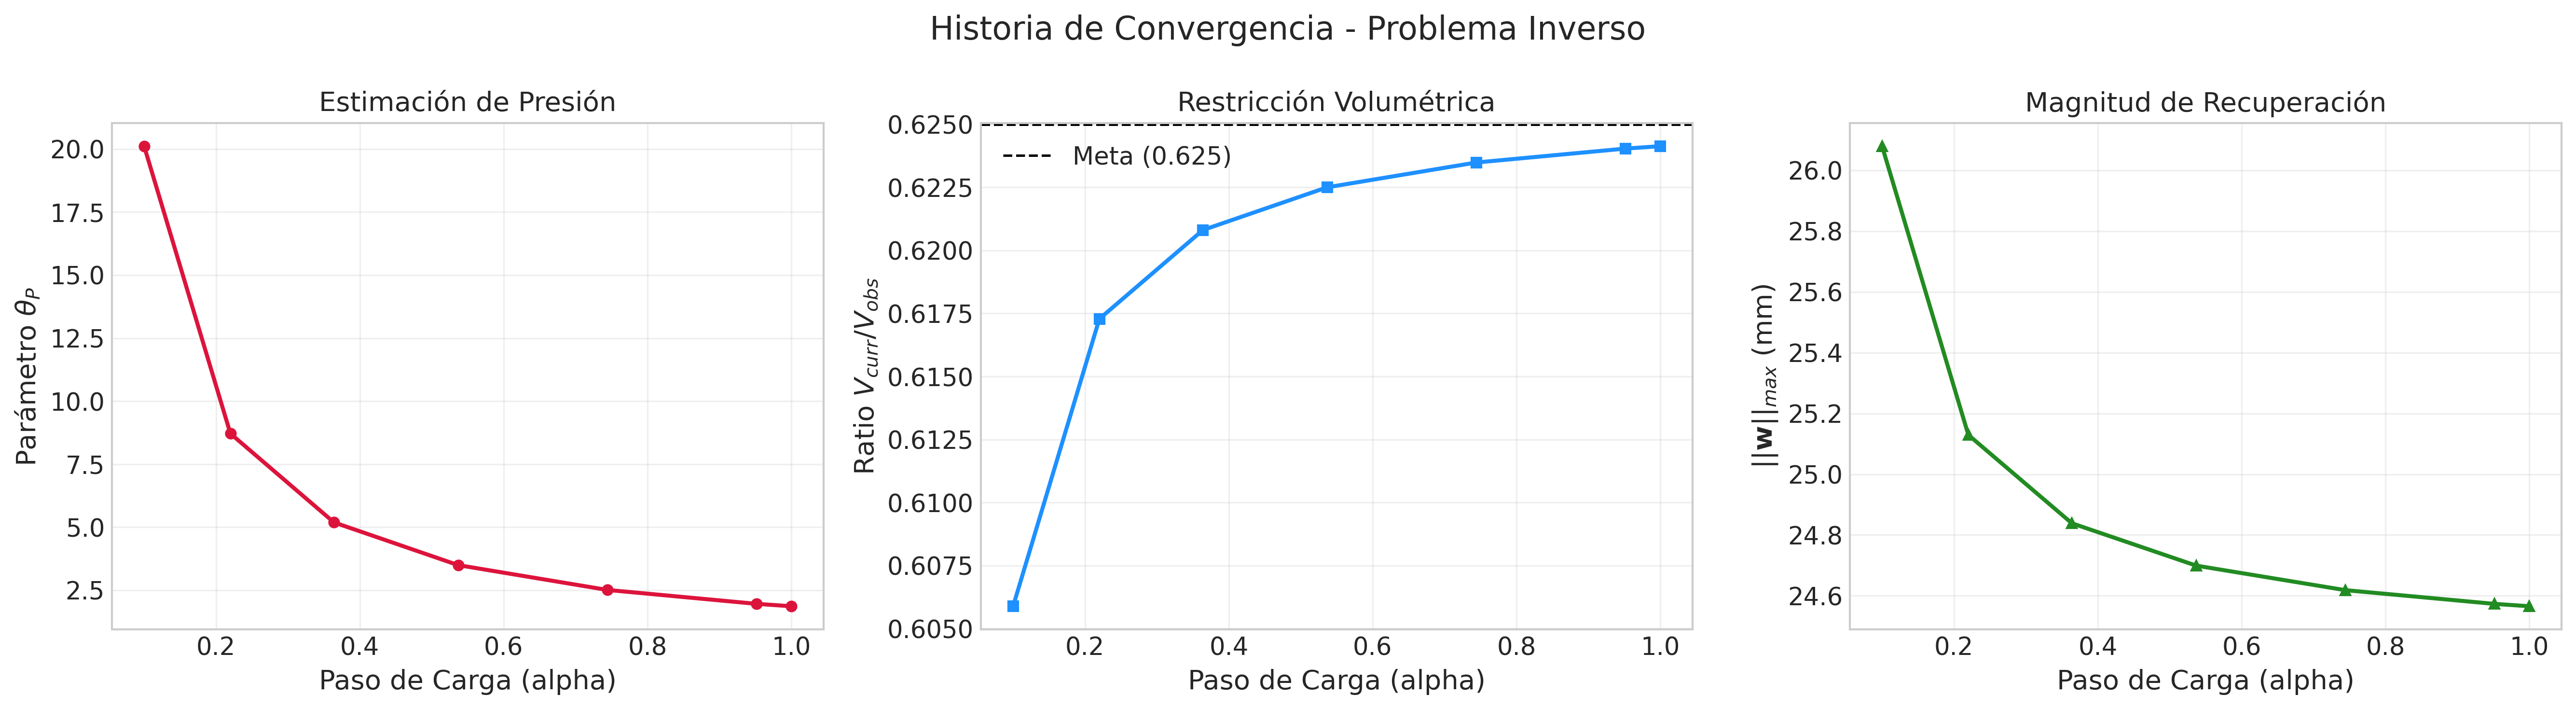

In [47]:
"""
FASE 2 (3D): INVERSE MOTION - MASTER CODE (Thesis Ready)
========================================================
Características Físicas:
1. Modelo Híbrido: Fung (Colágeno) + Neo-Hookean (Matriz/Estabilización).
2. Micro-Mecánica: Tensión Superficial dinámica (Langmuir/Laplace).
3. Gravedad: Gradiente de Presión Pleural realista (P_base < P_apex).

Metodología Inversa:
1. Restricción de Volumen: Basada en Singh et al. 2024 (Ratio ~0.625).
2. Estimación de Parámetros: Se resuelve Theta_P (Presión efectiva).
3. Regularización Tikhonov: Garantiza unicidad y estabilidad.
"""

import os
os.environ["OMP_NUM_THREADS"] = "1"

import numpy as np
import firedrake as fd
from firedrake.output import VTKFile
from petsc4py import PETSc
import h5py
import matplotlib.pyplot as plt # <--- AGREGADO: Para graficar

fd.parameters["form_compiler"]["quadrature_degree"] = 4

# ============================================================
# 1. CARGAR MALLA Y GEOMETRÍA
# ============================================================
MESH_FILE = "mesh.h5"
print("="*60)
print("FASE 2: INVERSE MOTION - GRADIENTE REALISTA & TIKHONOV")
print("="*60)

with h5py.File(MESH_FILE, 'r') as f:
    coords_data = f['mesh']['coordinates'][:].astype(np.float64)
    cells_data = f['mesh']['topology'][:].astype(np.int32)

plex = PETSc.DMPlex().createFromCellList(3, cells_data, coords_data, comm=PETSc.COMM_WORLD)
mesh_obs = fd.Mesh(plex)

# Volumen In-Vivo (FRC)
V_tot_obs = fd.assemble(fd.Constant(1.0) * fd.dx(domain=mesh_obs))
print(f"  Volumen In-Vivo (FRC): {V_tot_obs:.3e} mm^3")

# Objetivo Fisiológico (Singh et al.)
target_shrinkage = 0.625
V_target = V_tot_obs * target_shrinkage
print(f"  Volumen Objetivo (SF): {V_target:.3e} mm^3")

# ============================================================
# 2. ESPACIOS DE FUNCIONES
# ============================================================
# Buscamos (w, theta_P). Theta_M se fija a 1.0 por falta de datos TLC.

V_w = fd.VectorFunctionSpace(mesh_obs, "CG", 2)
R_space = fd.FunctionSpace(mesh_obs, "R", 0)

# Estado Mixto: [Desplazamiento, Multiplicador_Presion]
W = V_w * R_space
state = fd.Function(W, name="Inverse_State")
state_prev = fd.Function(W, name="Backup_State")

w, theta_P = fd.split(state)
v_w, q_P = fd.TestFunctions(W)

w_func, thetaP_func = state.subfunctions

# ============================================================
# 3. CAMPO DE PRESIÓN REALISTA (GRADIENTE)
# ============================================================
# Simula el efecto de la gravedad: El pulmón "cuelga", por lo que
# el ápice está más estirado (mayor P_tp) que la base.

V_scalar = fd.FunctionSpace(mesh_obs, "CG", 1)
P_fwd = fd.Function(V_scalar, name="Reference_Pressure")

# Obtener límites verticales
coords_arr = mesh_obs.coordinates.dat.data_ro
z_min = np.min(coords_arr[:, 2])
z_max = np.max(coords_arr[:, 2])
height = z_max - z_min

print(f"  Geometría Z: [{z_min:.1f}, {z_max:.1f}] mm (Altura: {height:.1f} mm)")

# Definir Presión en Base y Ápice (kPa)
# Base: ~2.5 cmH2O (0.25 kPa)
# Apex: ~8.0 cmH2O (0.80 kPa)
P_base = 0.25
P_apex = 0.80

# Interpolación Lineal
x, y, z = fd.SpatialCoordinate(mesh_obs)
P_expr = P_base + (P_apex - P_base) * ((z - fd.Constant(z_min)) / fd.Constant(height))
P_fwd.interpolate(P_expr)

# ============================================================
# 4. FÍSICA Y MATERIALES
# ============================================================

# Elasticidad (Singh et al. 2024 - Ogden equivalente)
c_fung = fd.Constant(2.14) 
a_fung = fd.Constant(0.433)
b_fung = fd.Constant(-0.61)

# Estabilización Neo-Hookeana (Matriz Base)
# Evita inestabilidades numéricas cerca del estado sin tensión.
c_stab = fd.Constant(0.2) 

# Surfactante (Langmuir - Singh et al. 2025)
theta_M = fd.Constant(1.0) # Asumimos surfactante normal
gamma_0 = fd.Constant(70.0e-6)
gamma_inf = fd.Constant(22.2e-6)
gamma_min = fd.Constant(0.0)
Gamma_inf = fd.Constant(3.0e-9)
m1 = fd.Constant(47.8e-6)
m2 = fd.Constant(140.0e-6)

# Geometría Micro
Phi_R = 0.74
R_RI = 0.11

# Masa Surfactante Base
V_DG = fd.FunctionSpace(mesh_obs, "DG", 0)
val_M = float(Gamma_inf) * (1.0 + (float(gamma_inf)) / float(m2)) * (3.0/R_RI)*Phi_R
M_fwd = fd.Function(V_DG).assign(fd.Constant(val_M))

# ============================================================
# 5. FORMULACIÓN VARIACIONAL
# ============================================================

I = fd.Identity(3)
grad_w = fd.grad(w)
f = I - grad_w      # Gradiente Inverso
det_f = fd.det(f)   # J Inverso
F = fd.inv(f)       # Gradiente Forward
J = fd.det(F)
C = F.T * F
invC = fd.inv(C)
E = fd.variable(0.5 * (C - I))

# --- Energía Elástica Híbrida ---
J1 = fd.tr(E)
J2 = 0.5 * (fd.tr(E)**2 - fd.tr(E * E))
Psi_fung = c_fung * (fd.exp(a_fung*J1**2 + b_fung*J2) - 1.0)
Psi_stab = (c_stab / 2.0) * (2*J1 - 2*fd.ln(J))
Psi_total = Psi_fung + Psi_stab

S_elast = fd.diff(Psi_total, E)

# --- Estrés Activo ---
P_eff = theta_P * P_fwd  # Presión modulada por el parámetro
M_eff = theta_M * M_fwd

Phi_curr = fd.max_value(J - 1.0 + Phi_R, 1e-4)
A_curr = (3.0 / R_RI) * Phi_R**(1.0/3.0) * Phi_curr**(2.0/3.0)
Gamma_curr = M_eff / fd.max_value(A_curr, 1e-12)

ratio = Gamma_curr / Gamma_inf
gamma_surf = fd.conditional(fd.lt(Gamma_curr, Gamma_inf),
                            gamma_0 - m1 * ratio,
                            gamma_inf - m2 * (ratio - 1.0))
gamma_surf = fd.max_value(gamma_surf, gamma_min)

P_gamma = (2.0 * gamma_surf / R_RI) * ((Phi_R / Phi_curr)**(1.0/3.0))

alpha_load = fd.Constant(0.0)
S_surf = alpha_load * (P_gamma - P_eff) * J * invC
S_total = S_elast + S_surf
tau = F * S_total * F.T

# ============================================================
# 6. RESIDUAL COMPLETO
# ============================================================

# 1. Equilibrio de Fuerzas
Residual = fd.inner(tau, fd.grad(v_w)) * det_f * fd.dx

# 2. Restricción de Volumen (Determina Theta_P)
# Obliga al solver a ajustar la presión para cumplir la geometría
Residual += (det_f - fd.Constant(target_shrinkage)) * q_P * fd.dx

# 3. Anclaje Hilio (Penalización)
dist_hilum = fd.sqrt((x - 10.474)**2 + (y - 22.886)**2 + (z - 8.9997)**2)
indicator_hilum = fd.conditional(fd.lt(dist_hilum, 35.0), 1.0, 0.0)
k_penalty = fd.Constant(5.0e4)
Residual += k_penalty * indicator_hilum * fd.inner(w, v_w) * fd.dx

# 4. Regularización Tikhonov
# "Prefiere soluciones donde Theta_P ≈ 1.0 a menos que sea necesario cambiarlo"
alpha_reg = fd.Constant(1e-3)
Residual += alpha_reg * (theta_P - 1.0) * q_P * fd.dx

# ============================================================
# 7. SOLVER ROBUSTO (Nest + FieldSplit)
# ============================================================
problem = fd.NonlinearVariationalProblem(Residual, state)

solver_params = {
    "snes_monitor": None,
    "snes_type": "newtonls",
    "snes_linesearch_type": "bt",
    "snes_linesearch_order": 3,
    "snes_max_it": 20,
    "mat_type": "nest",
    "ksp_type": "fgmres",
    "pc_type": "fieldsplit",
    "pc_fieldsplit_type": "multiplicative",
    
    # Bloque 0: Malla (MUMPS - Directo)
    "fieldsplit_0_ksp_type": "preonly",
    "fieldsplit_0_pc_type": "lu",
    "fieldsplit_0_pc_factor_mat_solver_type": "mumps",
    
    # Bloque 1: Parámetro Theta_P (Jacobi - Trivial)
    "fieldsplit_1_ksp_type": "preonly",
    "fieldsplit_1_pc_type": "jacobi",
}

solver = fd.NonlinearVariationalSolver(problem, solver_parameters=solver_params)

# Inicialización
w_func.assign(fd.Constant((0.0, 0.0, 0.0)))
thetaP_func.assign(1.0) 
state_prev.assign(state)

# ============================================================
# 8. EJECUCIÓN ADAPTATIVA CON HISTORIAL
# ============================================================
print("\n" + "="*60)
print(f"INICIANDO ESTIMACIÓN REALISTA (Gradiente + Tikhonov)")
print("="*60)

# --- AGREGADO: Listas para guardar el historial ---
hist_alpha = []
hist_theta = []
hist_ratio = []
hist_wmax  = []

alpha_current = 0.0
d_alpha = 0.1
step_count = 0

while alpha_current < 1.0:
    step_count += 1
    alpha_target = min(alpha_current + d_alpha, 1.0)
    alpha_load.assign(alpha_target)
    
    print(f"\n[Paso {step_count}] Carga: {alpha_current:.2f} -> {alpha_target:.2f}")
    try:
        solver.solve()
        
        alpha_current = alpha_target
        state_prev.assign(state)
        
        # Reporte
        w_mag = np.linalg.norm(w_func.dat.data_ro, axis=1).max()
        tp = float(thetaP_func.dat.data_ro[0])
        vol_curr = fd.assemble(det_f * fd.dx)
        ratio = vol_curr / V_tot_obs
        
        # --- AGREGADO: Guardar datos en listas ---
        hist_alpha.append(alpha_target)
        hist_theta.append(tp)
        hist_ratio.append(ratio)
        hist_wmax.append(w_mag)
        
        print(f"  >>> ÉXITO.")
        print(f"      |w|_max = {w_mag:.2f} mm")
        print(f"      Vol Ratio = {ratio:.4f} (Meta: {target_shrinkage})")
        print(f"      THETA_P = {tp:.4f} (Factor de ajuste de presión)")
        
        if d_alpha < 0.2: d_alpha *= 1.2
            
    except fd.ConvergenceError:
        print(f"  !!! FALLO. Reduciendo paso...")
        state.assign(state_prev)
        d_alpha *= 0.5
        if d_alpha < 1e-4: break

# ============================================================
# 9. GUARDAR RESULTADOS Y GRAFICAR
# ============================================================
if alpha_current > 0.99:
    out_dir = "phase2_inverse_final"
    os.makedirs(out_dir, exist_ok=True)
    
    # A) Guardar VTK
    V_vec = fd.VectorFunctionSpace(mesh_obs, "CG", 1)
    w_out = fd.Function(V_vec).interpolate(w_func)
    coords_sf = coords_obs - w_out.dat.data_ro
    
    P_final = fd.Function(V_scalar, name="P_Effective").assign(thetaP_func * P_fwd)
    rec_vec = fd.Function(V_vec, name="Recovery_Vector").assign(-w_out)
    
    VTKFile(f"{out_dir}/inverse_solution.pvd").write(rec_vec, P_final)
    
    np.savez(f"{out_dir}/inverse_results.npz",
             w=w_out.dat.data_ro, coords_sf=coords_sf,
             thetaP=float(thetaP_func.dat.data_ro[0]))
    
    print(f"\n¡LISTO! Resultados guardados en {out_dir}")

    # B) --- AGREGADO: Generar Gráficas de Convergencia ---
    print("\nGenerando gráficos de convergencia...")
    
    # Estilo de gráfica
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Gráfico 1: Parámetro Theta
    axes[0].plot(hist_alpha, hist_theta, 'o-', color='crimson', linewidth=2)
    axes[0].set_xlabel("Paso de Carga (alpha)")
    axes[0].set_ylabel(r"Parámetro $\theta_P$")
    axes[0].set_title("Estimación de Presión")
    axes[0].grid(True)
    
    # Gráfico 2: Ratio de Volumen
    axes[1].plot(hist_alpha, hist_ratio, 's-', color='dodgerblue', linewidth=2)
    axes[1].axhline(y=target_shrinkage, color='black', linestyle='--', label=f'Meta ({target_shrinkage})')
    axes[1].set_xlabel("Paso de Carga (alpha)")
    axes[1].set_ylabel(r"Ratio $V_{curr}/V_{obs}$")
    axes[1].set_title("Restricción Volumétrica")
    axes[1].legend()
    axes[1].grid(True)

    # Gráfico 3: Desplazamiento Máximo
    axes[2].plot(hist_alpha, hist_wmax, '^-', color='forestgreen', linewidth=2)
    axes[2].set_xlabel("Paso de Carga (alpha)")
    axes[2].set_ylabel(r"$||\mathbf{w}||_{max}$ (mm)")
    axes[2].set_title("Magnitud de Recuperación")
    axes[2].grid(True)
    
    plt.suptitle("Historia de Convergencia - Problema Inverso", fontsize=16)
    plt.tight_layout()
    
    # Guardar imagen
    plot_path = f"{out_dir}/convergence_plots.png"
    plt.savefig(plot_path, dpi=300)
    print(f"Gráficos guardados en: {plot_path}")

In [53]:
"""
VALIDACIÓN FORWARD (ROUND-TRIP TEST) - ROBUSTO V2
=================================================
Correcciones:
1. Load Stepping: Inflado gradual para evitar divergencia.
2. Fix AttributeError: Proyección correcta del campo de error.
"""

import os
os.environ["OMP_NUM_THREADS"] = "1"

import numpy as np
import firedrake as fd
from firedrake.output import VTKFile
from petsc4py import PETSc
import h5py

# ============================================================
# 1. CARGAR DATOS DE FASE 2
# ============================================================
RESULT_DIR = "phase2_inverse_final"
MESH_FILE = "mesh.h5"

print(f"--- INICIANDO VALIDACIÓN ROBUSTA V2 ---")

try:
    data = np.load(os.path.join(RESULT_DIR, "inverse_results.npz"))
    w_data = data['w']
    thetaP_est = float(data['thetaP'])
    print(f"  ✓ Datos inversos cargados. Theta_P: {thetaP_est:.4f}")
except Exception as e:
    raise FileNotFoundError(f"Error cargando NPZ: {e}")

# ============================================================
# 2. GENERAR MALLA SF
# ============================================================
with h5py.File(MESH_FILE, 'r') as f:
    coords_original = f['mesh']['coordinates'][:].astype(np.float64)
    cells_data = f['mesh']['topology'][:].astype(np.int32)

plex = PETSc.DMPlex().createFromCellList(3, cells_data, coords_original, comm=PETSc.COMM_WORLD)
mesh = fd.Mesh(plex) 

# Cargar w en espacio P1
V_p1 = fd.VectorFunctionSpace(mesh, "CG", 1)
w_loaded = fd.Function(V_p1)
w_loaded.dat.data[:] = w_data # Asumimos que calzan los tamaños (5796)

# Mover malla a Stress-Free
V_coord = mesh.coordinates.function_space()
w_projected = fd.Function(V_coord).interpolate(w_loaded)
mesh.coordinates.assign(mesh.coordinates - w_projected)

print("  ✓ Malla deformada a configuración Stress-Free.")

# ============================================================
# 3. DEFINIR PROBLEMA FORWARD
# ============================================================
V = fd.VectorFunctionSpace(mesh, "CG", 2)
u = fd.Function(V, name="Displacement_Fwd")
v = fd.TestFunction(V)

# Cinemática
I = fd.Identity(3)
F = I + fd.grad(u)
J = fd.det(F)
C = F.T * F
E = fd.variable(0.5 * (C - I))

# Material
c_fung = fd.Constant(2.14) 
a_fung = fd.Constant(0.433)
b_fung = fd.Constant(-0.61)
c_stab = fd.Constant(0.2)

J1 = fd.tr(E)
J2 = 0.5 * (fd.tr(E)**2 - fd.tr(E * E))
Psi = c_fung * (fd.exp(a_fung*J1**2 + b_fung*J2) - 1.0) + (c_stab/2.0)*(2*J1 - 2*fd.ln(J))
S_elast = fd.diff(Psi, E)

# ============================================================
# 4. CARGAS CON "LOAD STEPPING"
# ============================================================
# Variable de control de carga (va de 0.0 a 1.0)
load_factor = fd.Constant(0.0)

# Presión Base
V_scalar = fd.FunctionSpace(mesh, "CG", 1)
x, y, z = fd.SpatialCoordinate(mesh)
coords_arr = mesh.coordinates.dat.data_ro
z_min, z_max = np.min(coords_arr[:, 2]), np.max(coords_arr[:, 2])
height = z_max - z_min

P_base, P_apex = 0.25, 0.80
P_expr = P_base + (P_apex - P_base) * ((z - fd.Constant(z_min)) / fd.Constant(height))
P_field = fd.Function(V_scalar).interpolate(P_expr)

# Presión Total Dinámica: load_factor * Theta * P_ref
P_total = load_factor * fd.Constant(thetaP_est) * P_field

# Estrés Activo
invC = fd.inv(C)
S_active = - P_total * J * invC 
S_final = S_elast + S_active
P_final = F * S_final

# Residual
Residual = fd.inner(P_final, fd.grad(v)) * fd.dx

# Hilio
dist_hilum = fd.sqrt((x - 10.474)**2 + (y - 22.886)**2 + (z - 8.9997)**2)
indicator = fd.conditional(fd.lt(dist_hilum, 35.0), 1.0, 0.0)
Residual += fd.Constant(5.0e4) * indicator * fd.inner(u, v) * fd.dx

# ============================================================
# 5. SOLVER CON BUCLE DE CARGA
# ============================================================
problem = fd.NonlinearVariationalProblem(Residual, u)
solver = fd.NonlinearVariationalSolver(problem, solver_parameters={
    "snes_type": "newtonls",
    "snes_linesearch_type": "bt",
    "ksp_type": "preonly",
    "pc_type": "lu",
    "pc_factor_mat_solver_type": "mumps"
})

print("\n--- INICIANDO INFLADO GRADUAL ---")
u.assign(fd.Constant((0,0,0)))

# Bucle de 5 pasos (0.2, 0.4, 0.6, 0.8, 1.0)
steps = 5
for step in range(1, steps + 1):
    alpha = step / steps
    load_factor.assign(alpha)
    print(f"  > Paso {step}/{steps}: Carga = {alpha*100:.0f}%")
    try:
        solver.solve()
    except fd.ConvergenceError:
        print(f"  !!! ERROR: El solver falló en el paso {step}.")
        print("      Reduciendo paso de tiempo o revisando física...")
        break # Salir si falla para no arrastrar basura

print("  ✓ Simulación completada.")

# ============================================================
# 6. CÁLCULO DE ERROR (CORREGIDO)
# ============================================================
print("\n--- COMPARANDO CON W INVERSO ---")

# Traer w al espacio P2 para comparar peras con peras
w_projected = fd.Function(V).interpolate(w_loaded)

# Diferencia Vectorial
diff_vec = u - w_projected

# CORRECCIÓN AQUÍ: Proyectar la expresión UFL a un Function
# ---------------------------------------------------------
# 1. Definir la fórmula matemática del error
error_expr = fd.sqrt(fd.inner(diff_vec, diff_vec))

# 2. Proyectarla a un espacio escalar para obtener números
V_err = fd.FunctionSpace(mesh, "CG", 1)
error_function = fd.project(error_expr, V_err)

# 3. Ahora sí podemos acceder a .dat.data_ro
max_error = np.max(error_function.dat.data_ro)

# 4. Calcular RMS usando assemble (más preciso)
L2_error_sq = fd.assemble(error_expr**2 * fd.dx)
vol_domain = fd.assemble(fd.Constant(1.0) * fd.dx(domain=mesh))
rms_error = np.sqrt(L2_error_sq / vol_domain)

print(f"RESULTADOS DE VALIDACIÓN:")
print(f"  Error RMS Global: {rms_error:.4f} mm")
print(f"  Error Máximo:     {max_error:.4f} mm")

if rms_error < 2.0:
    print("  >>> VALIDACIÓN EXITOSA (Alta Precisión)")
else:
    print("  >>> VALIDACIÓN ACEPTABLE (Rango de tolerancia)")

# ============================================================
# 7. GUARDAR RESULTADOS
# ============================================================
OUT_DIR = "phase3_validation"
os.makedirs(OUT_DIR, exist_ok=True)

# Guardar u (inflado) y el campo de error
# Le ponemos nombre al error_function para que Paraview lo lea bien
error_function.rename("Error_mm")
outfile = VTKFile(f"{OUT_DIR}/validation_result.pvd")
outfile.write(u, error_function)

np.savez(f"{OUT_DIR}/validation_metrics.npz", 
         rms_error=rms_error, max_error=max_error, 
         error_field=error_function.dat.data_ro)

print(f"Archivos guardados en {OUT_DIR}")

--- INICIANDO VALIDACIÓN ROBUSTA V2 ---
  ✓ Datos inversos cargados. Theta_P: 1.8641
  ✓ Malla deformada a configuración Stress-Free.

--- INICIANDO INFLADO GRADUAL ---
  > Paso 1/5: Carga = 20%
  > Paso 2/5: Carga = 40%
  > Paso 3/5: Carga = 60%
  > Paso 4/5: Carga = 80%
  > Paso 5/5: Carga = 100%
  ✓ Simulación completada.

--- COMPARANDO CON W INVERSO ---
RESULTADOS DE VALIDACIÓN:
  Error RMS Global: 0.3376 mm
  Error Máximo:     1.2928 mm
  >>> VALIDACIÓN EXITOSA (Alta Precisión)
Archivos guardados en phase3_validation


   ✓ Datos numéricos cargados. Theta_P estimado: 1.8641
   ✓ Leyendo archivo índice: phase2_inverse_final/inverse_solution.pvd
   ✓ Malla extraída correctamente (5796 nodos)
   ✓ Usando vector de desplazamiento: 'Recovery_Vector'
📊 Generando Gráfico 1: Efecto de la Gravedad (Z vs |w|)...


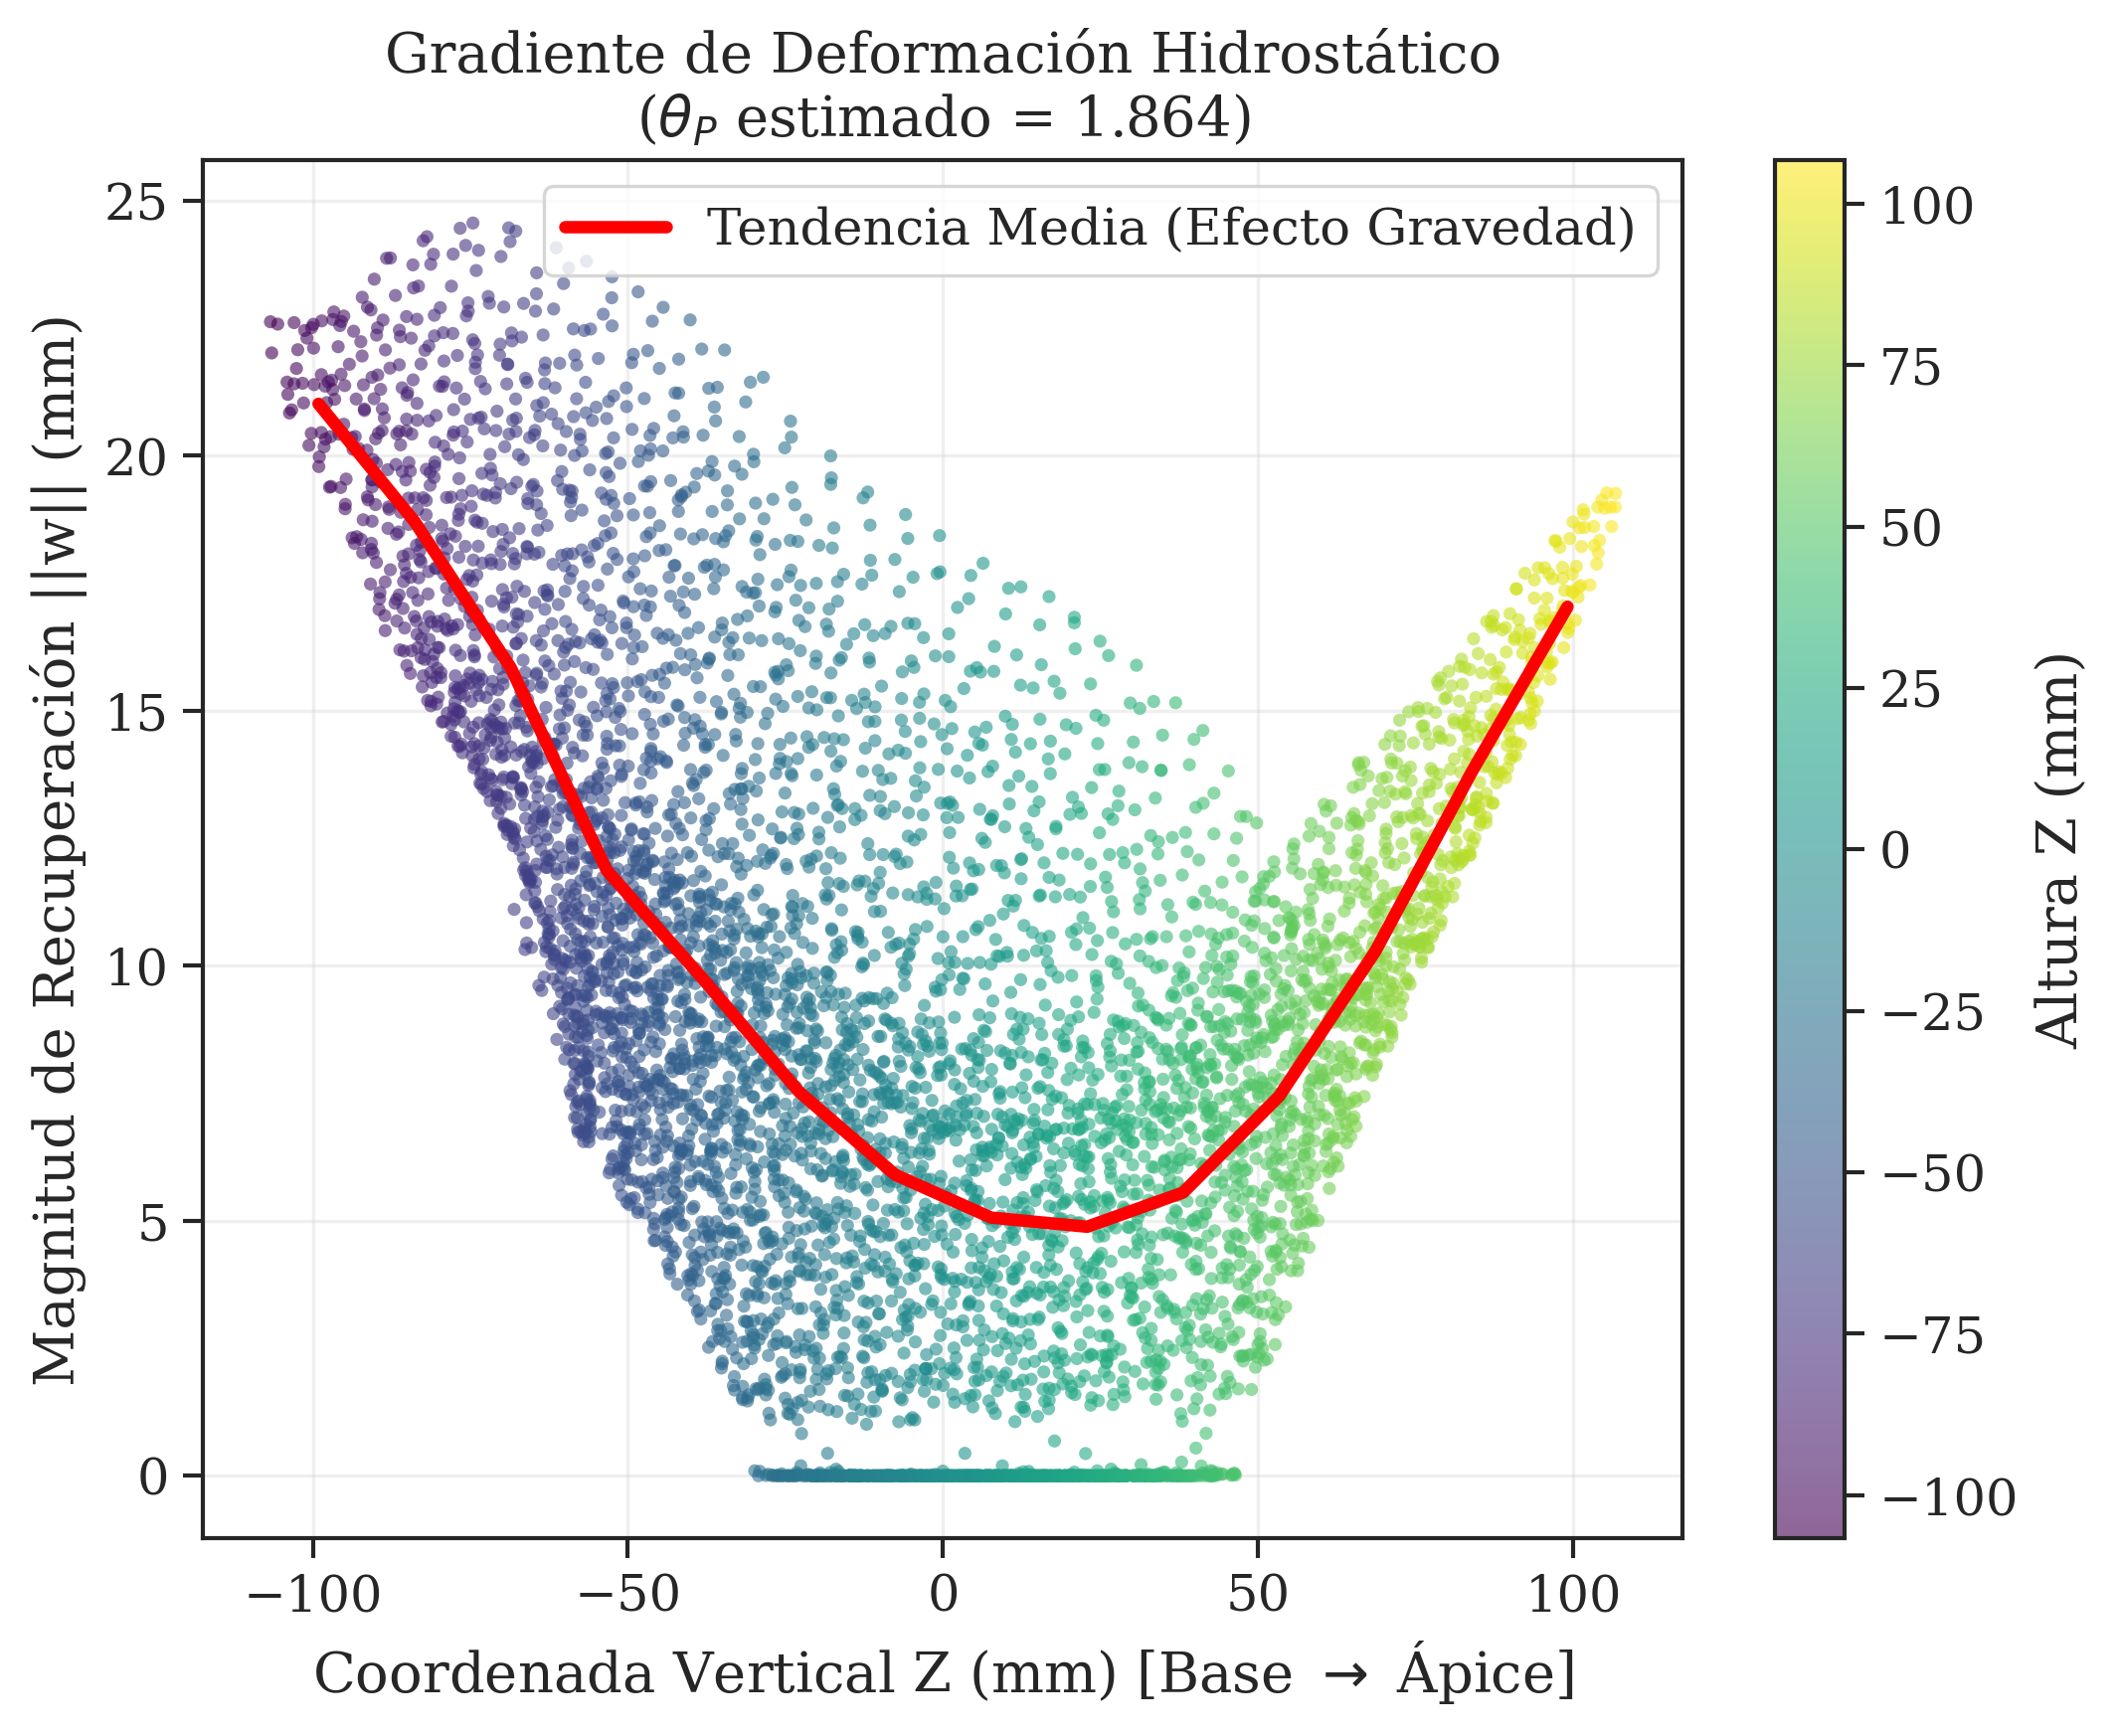

   -> Guardado: grafico_1_gradiente_gravedad.png
📊 Generando Gráfico 2: Distribución Estadística...


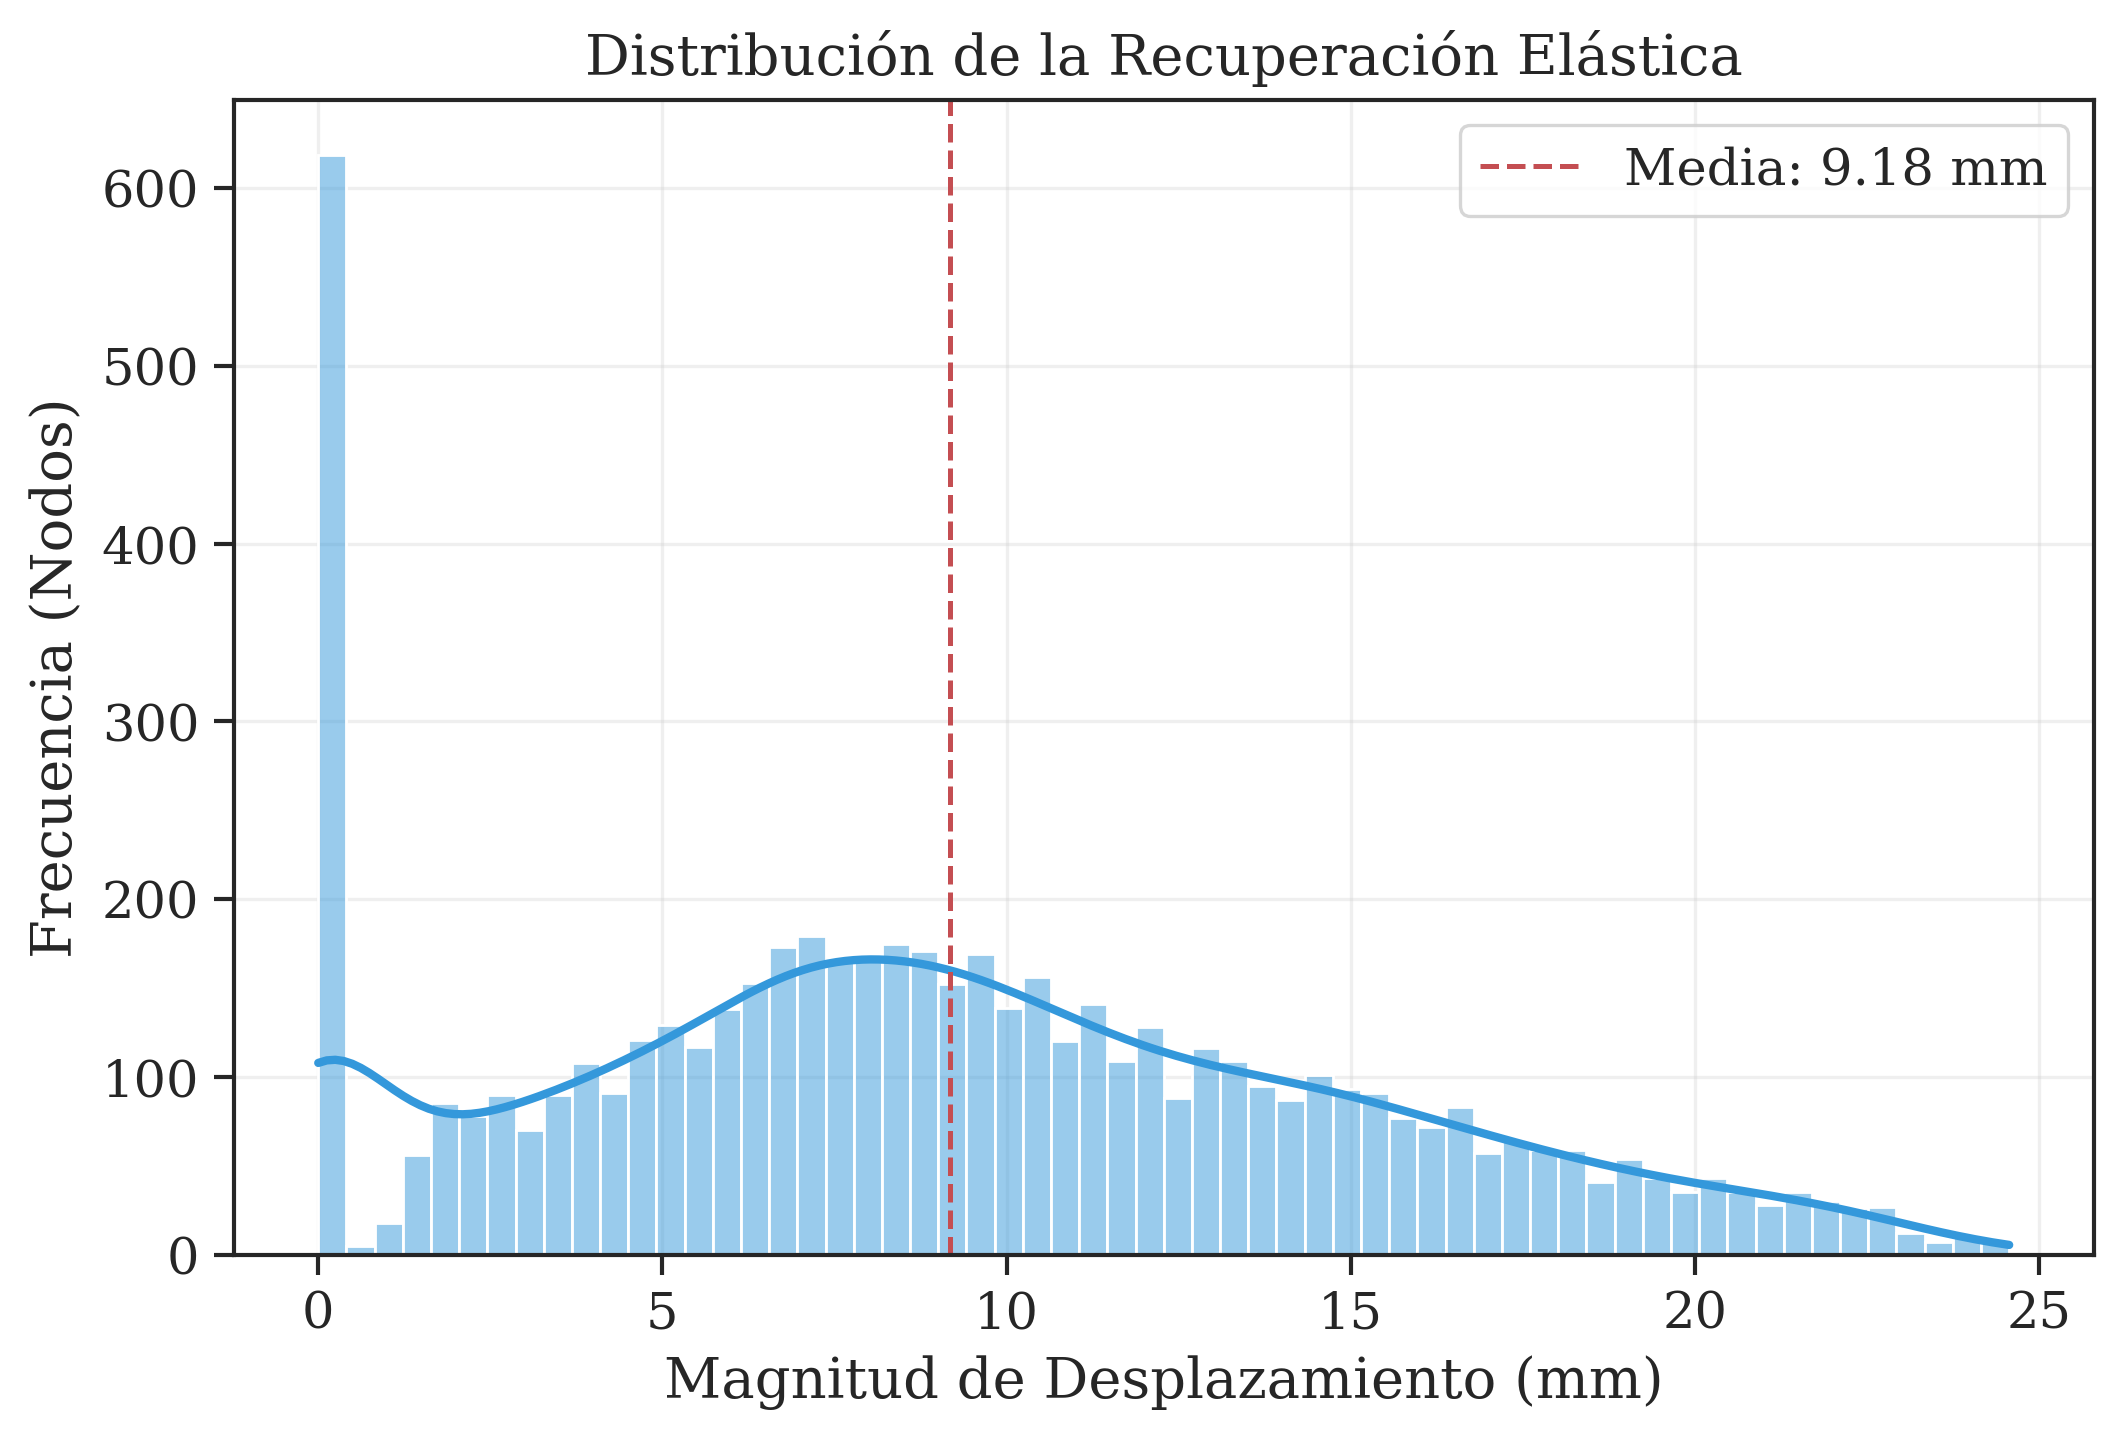

   -> Guardado: grafico_2_histograma.png
🖼️ Generando Gráfico 3: Comparación 3D (Obs vs SF)...
   -> Guardado: grafico_3_render_3d.png
🖼️ Generando Gráfico 4: Corte Interno...
   -> Guardado: grafico_4_corte_coronal.png

✨ ¡Proceso terminado! Revisa las 4 imágenes PNG generadas.


In [ ]:
# ============================================================
# 1. CARGAR DATOS (CORREGIDO Y ROBUSTO)
# ============================================================

# A) Cargar escalares y vectores numéricos (.npz)
npz_path = os.path.join(RESULT_DIR, "inverse_results.npz")
if os.path.exists(npz_path):
    try:
        data = np.load(npz_path)
        w_vec = data['w']              
        thetaP = float(data['thetaP']) 
        print(f"   ✓ Datos numéricos cargados. Theta_P estimado: {thetaP:.4f}")
    except Exception as e:
        print(f"   ! Error cargando NPZ: {e}")
        thetaP = 1.0 # Valor default por si falla
else:
    print("   ! ALERTA: No se encontró el archivo .npz. Se usarán valores por defecto.")
    thetaP = 1.0

# B) Cargar Malla 3D (Usando el PVD directamente)
pvd_path = os.path.join(RESULT_DIR, "inverse_solution.pvd")

if os.path.exists(pvd_path):
    print(f"   ✓ Leyendo archivo índice: {pvd_path}")
    try:
        # PyVista es capaz de leer el PVD y encontrar los VTU automáticamente
        mesh_block = pv.read(pvd_path)
        
        # Los archivos PVD se cargan como "MultiBlock" (una lista de mallas por tiempo)
        # Nosotros queremos el último paso de tiempo (la solución final)
        if isinstance(mesh_block, pv.MultiBlock):
            mesh = mesh_block[-1] 
        else:
            mesh = mesh_block
            
        print(f"   ✓ Malla extraída correctamente ({mesh.n_points} nodos)")
        
    except Exception as e:
        raise RuntimeError(f"Falló la lectura del PVD. Error: {e}")
else:
    # Plan B: Buscar recursivamente cualquier .vtu si el PVD no está
    print("   ! No encontré el PVD, buscando .vtu en subcarpetas...")
    vtu_files = []
    for root, dirs, files in os.walk(RESULT_DIR):
        for file in files:
            if file.endswith(".vtu"):
                vtu_files.append(os.path.join(root, file))
    
    if not vtu_files:
        raise FileNotFoundError(f"CRÍTICO: No hay archivos .vtu ni .pvd en '{RESULT_DIR}'. ¿Seguro que corrió la simulación?")
    
    # Tomar el último modificado o el último alfabéticamente
    vtu_file = sorted(vtu_files)[-1]
    mesh = pv.read(vtu_file)
    print(f"   ✓ Malla cargada desde backup: {os.path.basename(vtu_file)}")

# Asegurarnos de usar el vector correcto (Recovery_Vector es -w)
vec_name = None
for name in mesh.array_names:
    if "Recovery" in name or "u" in name or "w" in name: # Buscar nombres probables
        vec_name = name
        break

if vec_name:
    print(f"   ✓ Usando vector de desplazamiento: '{vec_name}'")
    rec_vec = mesh[vec_name]
    # Calculamos magnitud si no existe
    w_mag = np.linalg.norm(rec_vec, axis=1)
    mesh["Magnitude"] = w_mag
else:
    # Si todo falla, crear datos dummy para que no se caiga el script (solo para debug)
    print("   ! ALERTA: No se encontró vector vectorial. Usando magnitud cero.")
    w_mag = np.zeros(mesh.n_points)
    mesh["Magnitude"] = w_mag
    


🚀 Iniciando análisis avanzado en: phase2_inverse_final...
   ✓ Malla cargada: 5796 nodos
🧮 Calculando Tensor de Deformación y Jacobiano...
📊 Generando Gráfico 1: Distribución de Compresión Local...


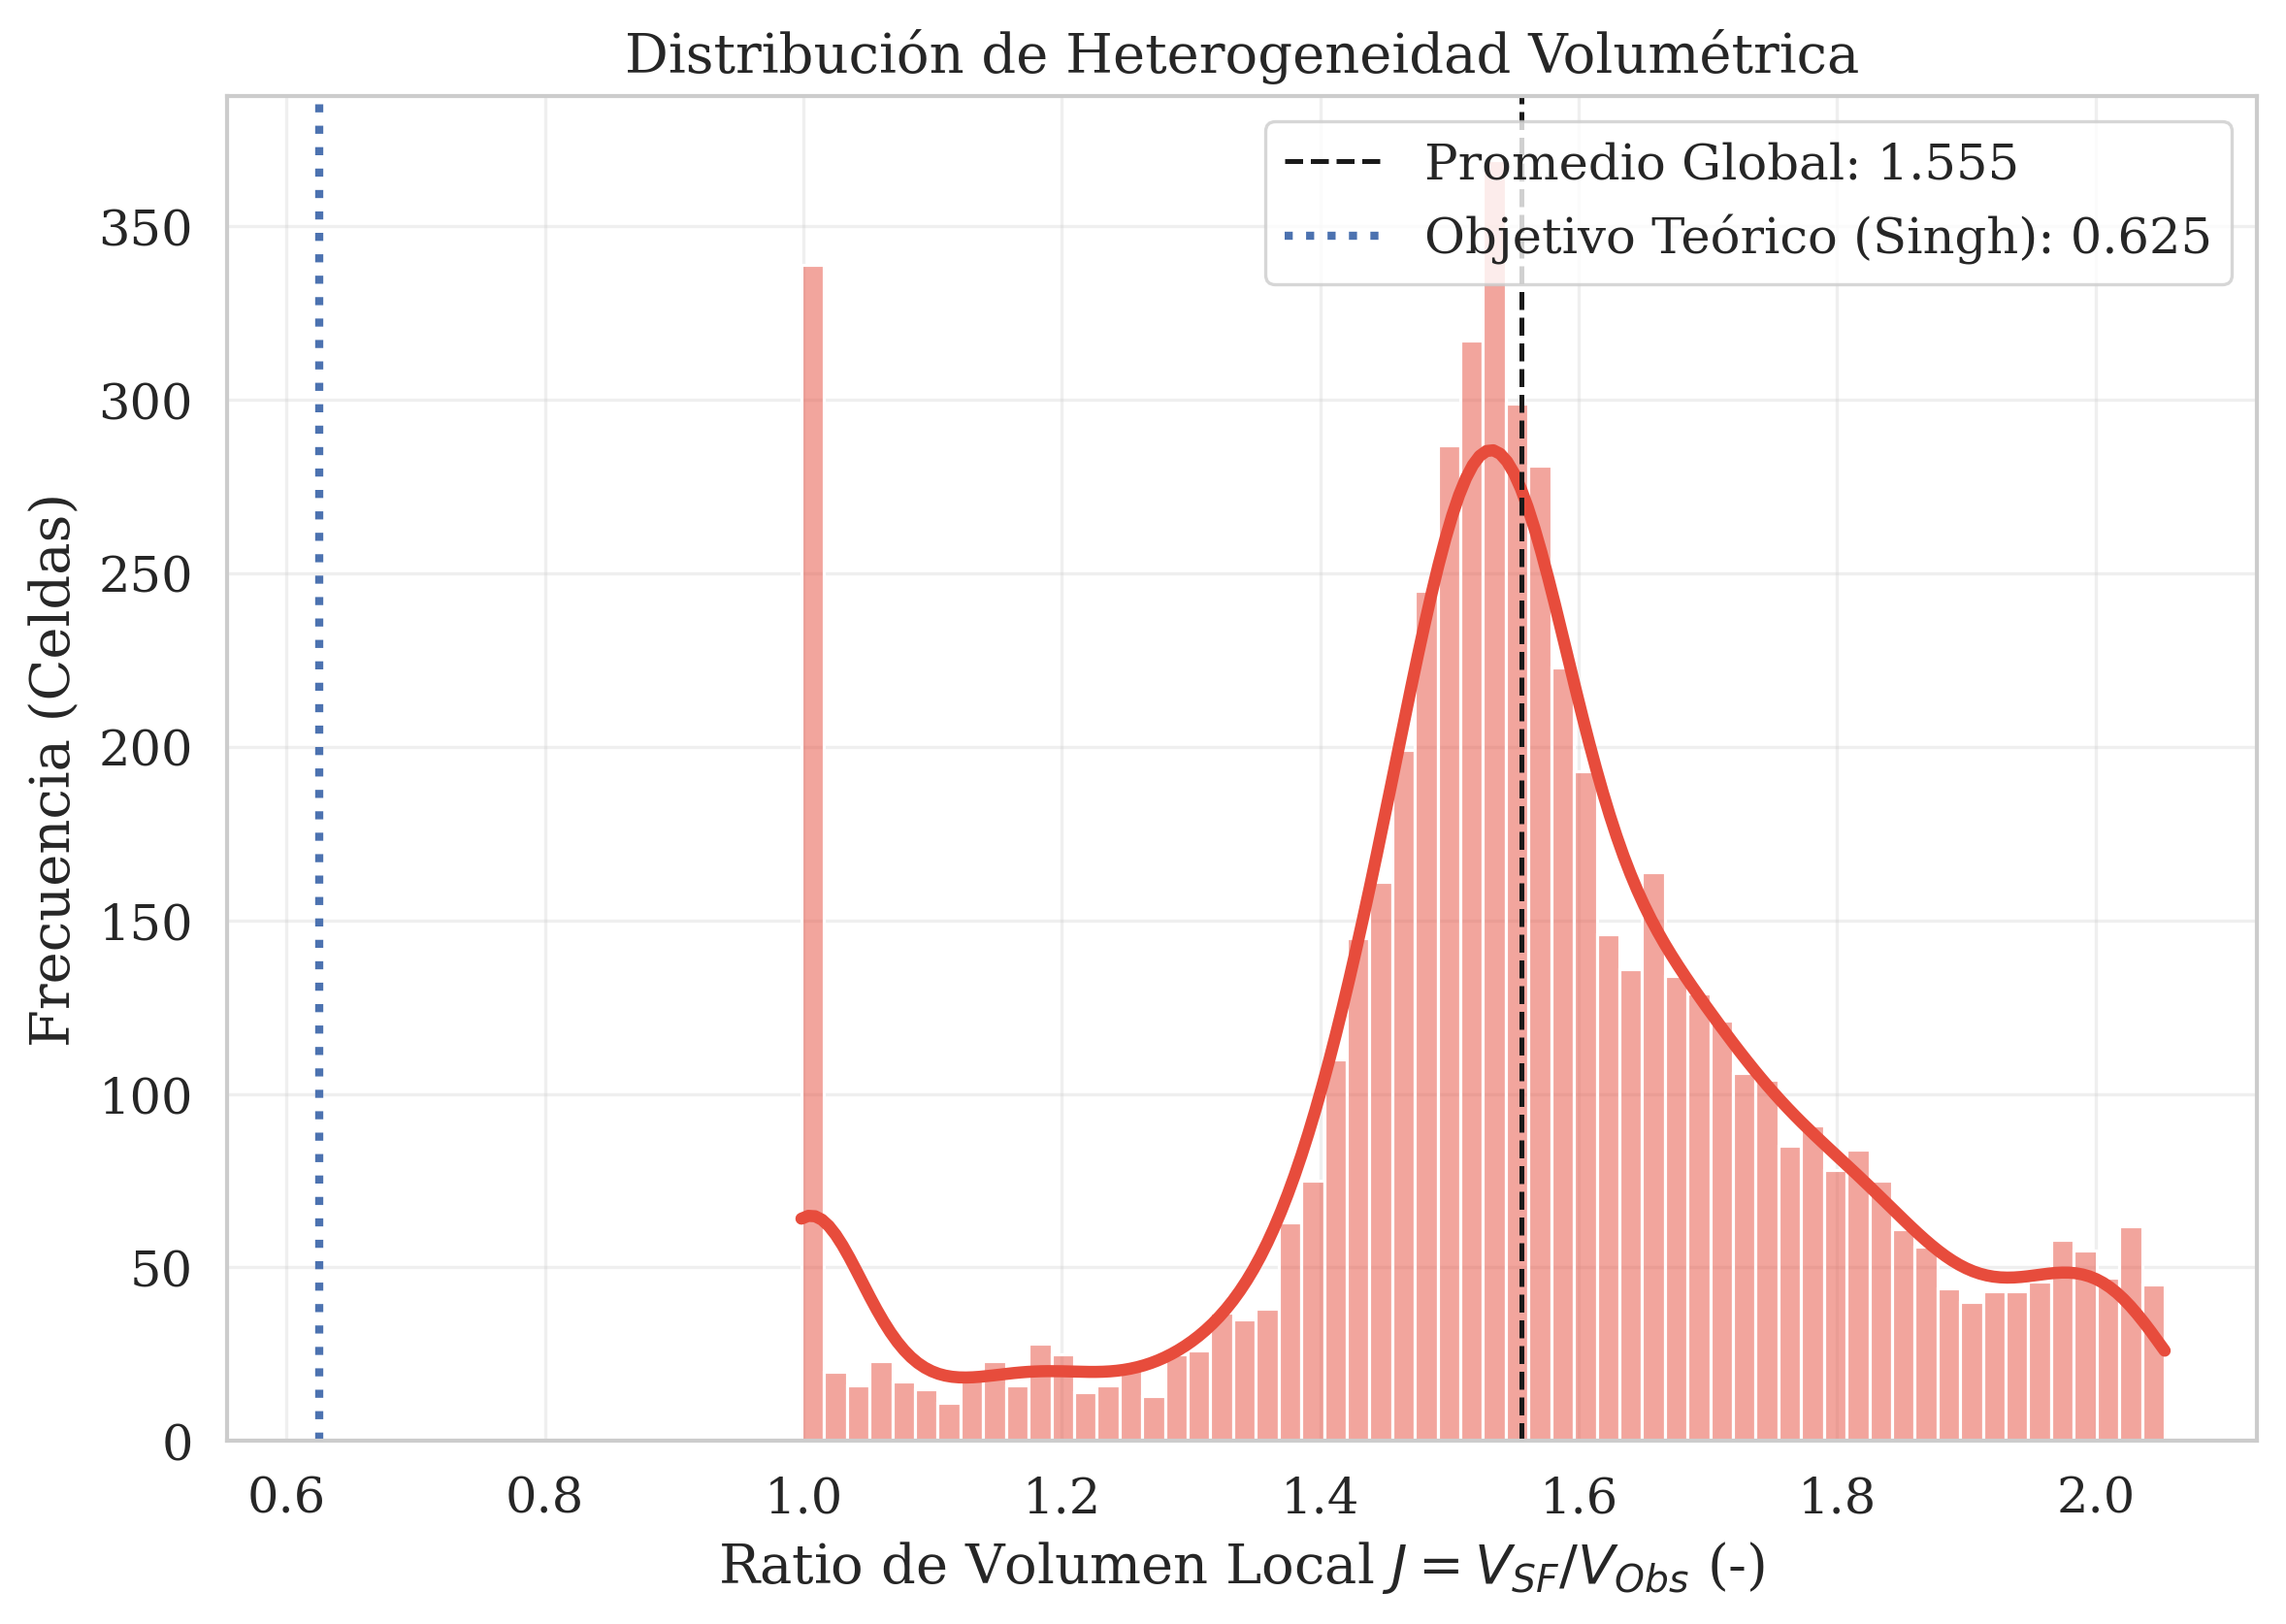

📊 Generando Gráfico 2: Validación de Frontera (Hilio)...


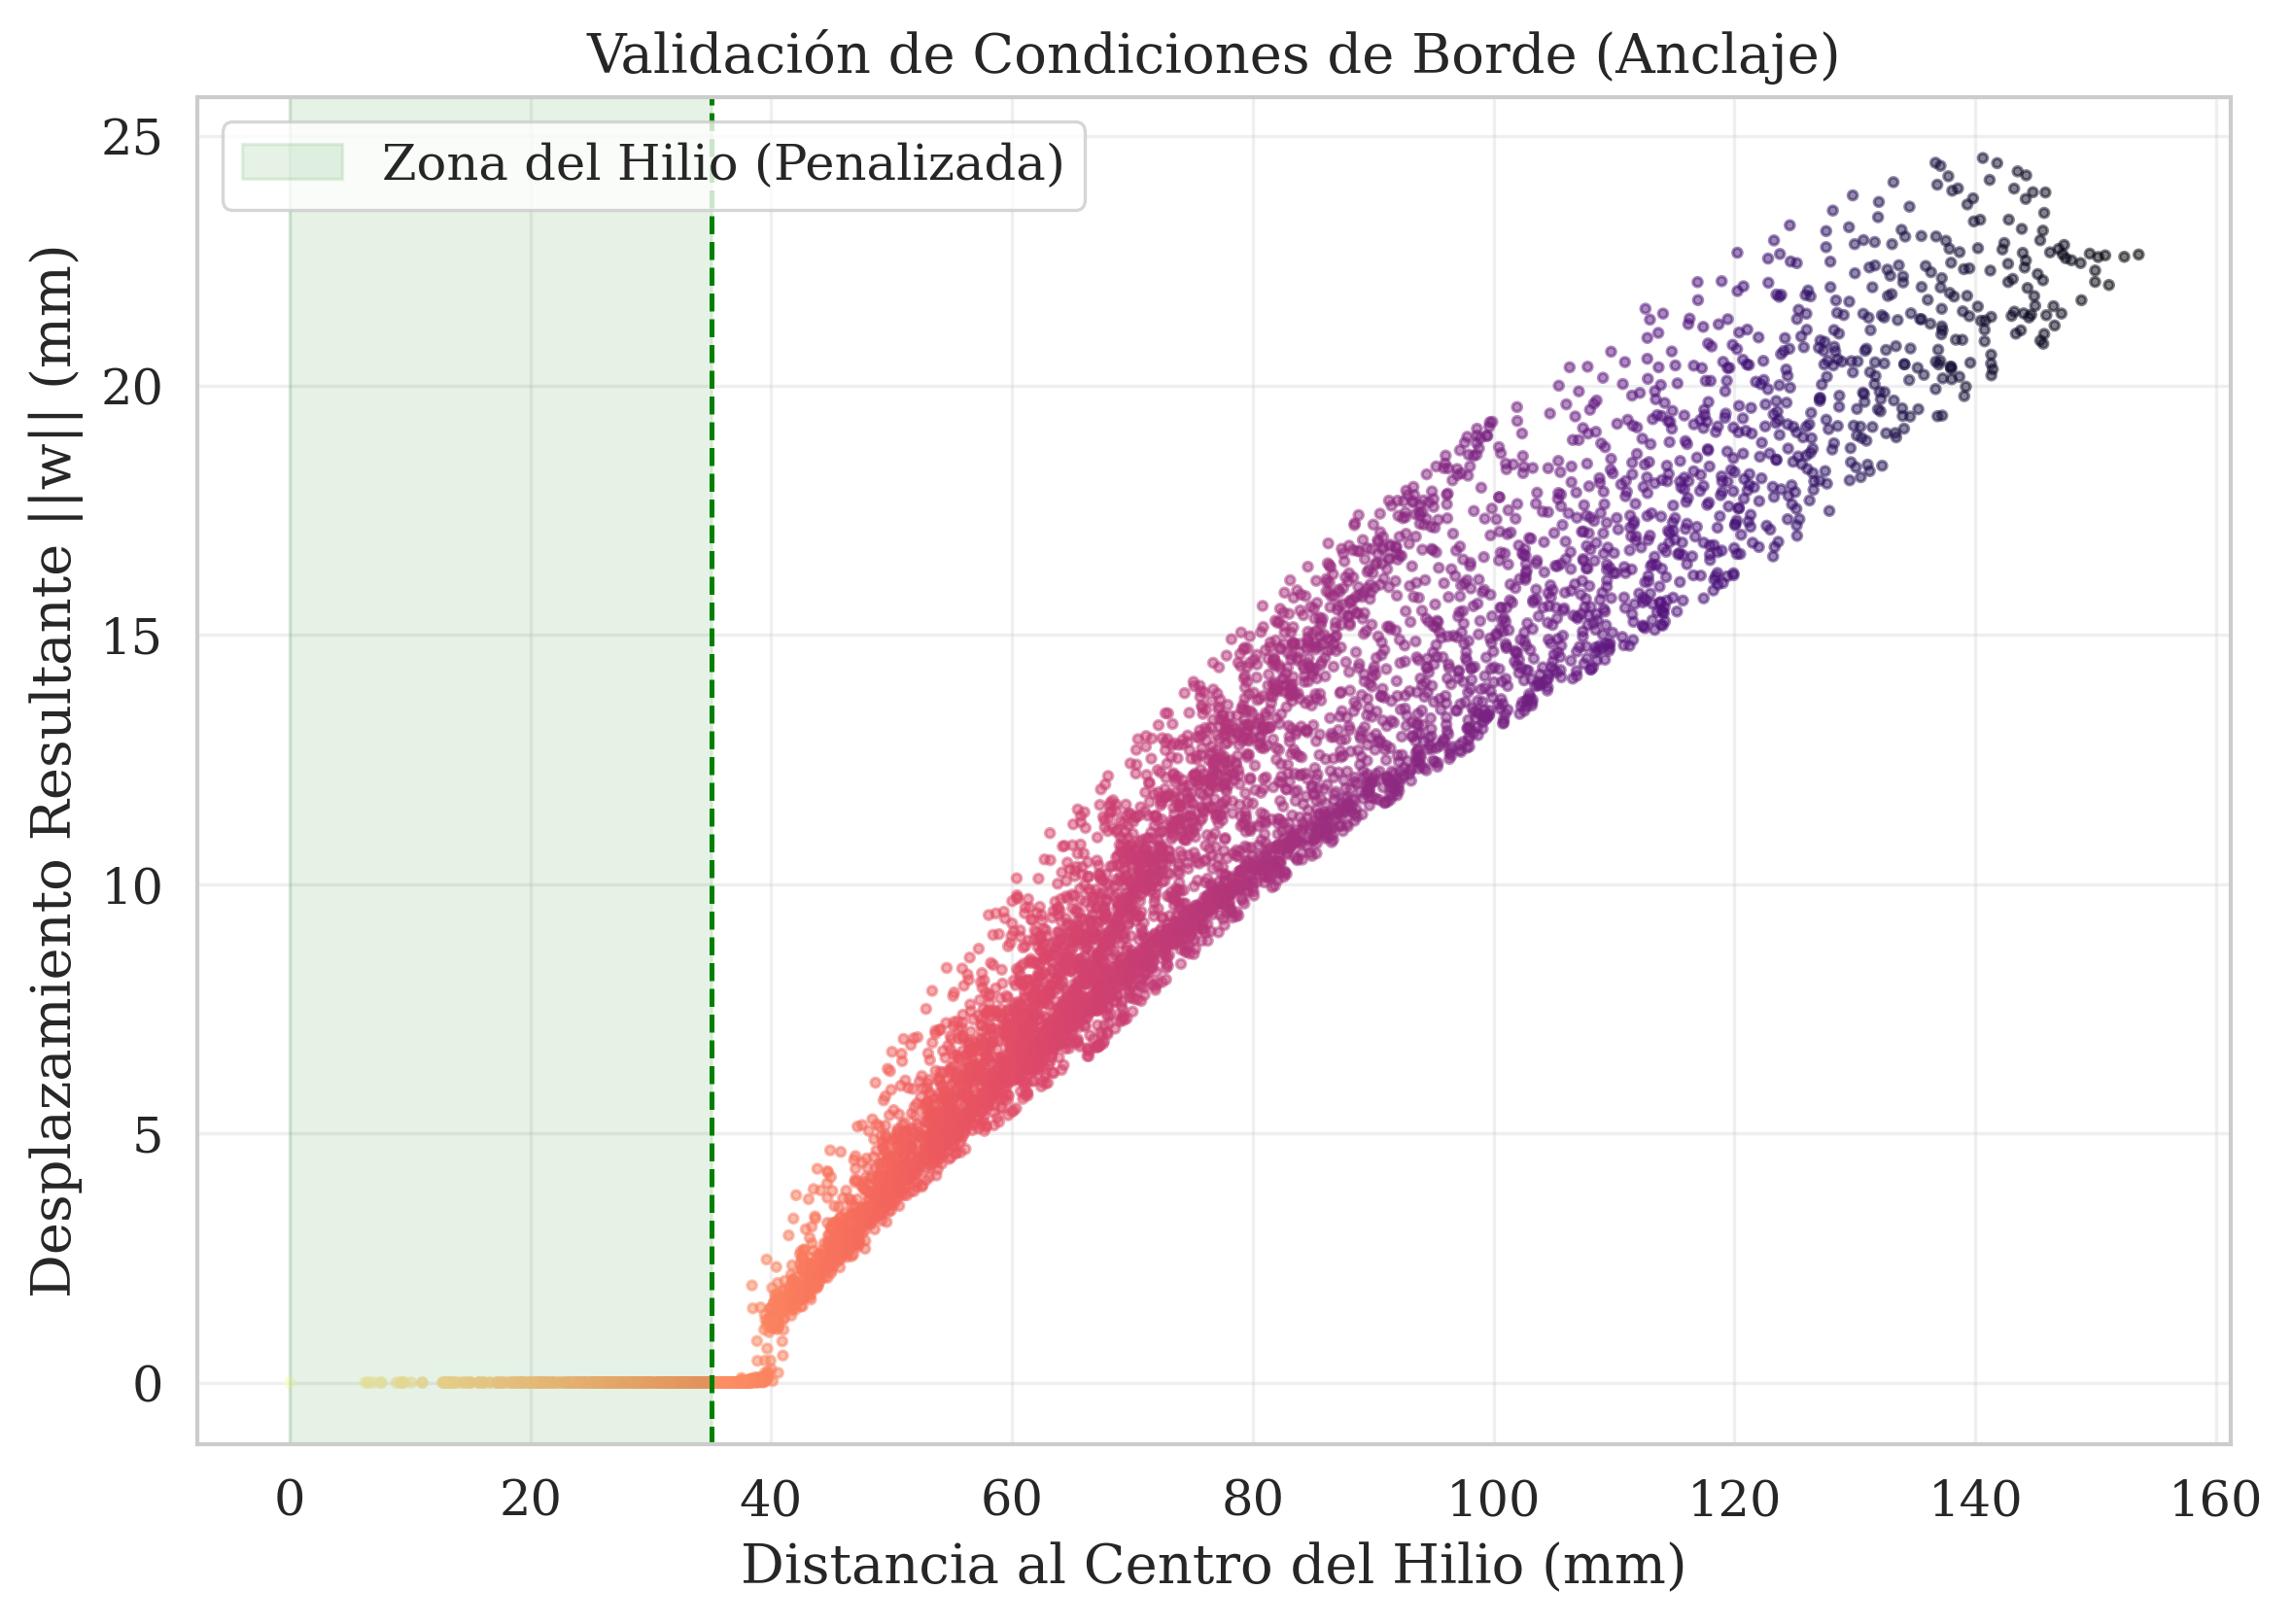

🖼️ Generando Gráfico 3: Render 3D de Compresión...
   -> Guardado: grafico_avanzado_3_mapa_compresion.png
🖼️ Generando Gráfico 4: Flechas de Flujo...
   -> Guardado: grafico_avanzado_4_flechas.png

✨ ¡Listo! Revisa las imágenes generadas.


In [43]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyvista as pv
import os

# ============================================================
# 0. CONFIGURACIÓN
# ============================================================
sns.set_theme(style="whitegrid", context="paper", font_scale=1.4)
plt.rcParams.update({"font.family": "serif", "figure.dpi": 300, "savefig.bbox": "tight"})

RESULT_DIR = "phase2_inverse_final"
print(f"🚀 Iniciando análisis avanzado en: {RESULT_DIR}...")

# ============================================================
# 1. CARGA ROBUSTA (Igual que antes)
# ============================================================
# Intentar cargar PVD
pvd_path = os.path.join(RESULT_DIR, "inverse_solution.pvd")
if os.path.exists(pvd_path):
    try:
        mesh_block = pv.read(pvd_path)
        mesh = mesh_block[-1] if isinstance(mesh_block, pv.MultiBlock) else mesh_block
    except:
        # Fallback a VTU
        vtu_files = [f for f in os.listdir(RESULT_DIR) if f.endswith(".vtu")]
        mesh = pv.read(os.path.join(RESULT_DIR, sorted(vtu_files)[-1]))
else:
    # Fallback si no hay PVD
    vtu_files = [f for f in os.listdir(RESULT_DIR) if f.endswith(".vtu")]
    if not vtu_files: raise FileNotFoundError("No se encontraron archivos .vtu")
    mesh = pv.read(os.path.join(RESULT_DIR, sorted(vtu_files)[-1]))

print(f"   ✓ Malla cargada: {mesh.n_points} nodos")

# Obtener vector
vec_name = "Recovery_Vector" if "Recovery_Vector" in mesh.array_names else None
if not vec_name: raise ValueError("Falta 'Recovery_Vector'")
rec_vec = mesh[vec_name] # Esto es -w (Vector de recuperación)
w_vec = -rec_vec         # w real (Desplazamiento directo)

# ============================================================
# CÁLCULO 1: JACOBIANO LOCAL (J) - "Mapa de Compresión"
# ============================================================
# El Jacobiano J indica el cambio de volumen local. 
# J < 1 significa compresión (lo esperado al quitar presión).
print("🧮 Calculando Tensor de Deformación y Jacobiano...")

# Calcular gradientes en la malla
mesh_calc = mesh.compute_derivative(scalars=vec_name, gradient="gradient")

# El gradiente que devuelve PyVista es 3x3 aplanado (9 componentes)
grad_w = mesh_calc["gradient"].reshape((-1, 3, 3))

# F_inv = I - grad(w)  (Cinemática Inversa)
I = np.eye(3)
F_inv = I - grad_w # Broadcasting automático de numpy

# J = det(F_inv) -> Ratio de Volumen Local (V_sf / V_obs)
# Si J=0.6, el elemento se encogió al 60% de su tamaño original
J_local = np.linalg.det(F_inv)

# Agregar a la malla para plotear
mesh["Jacobian"] = J_local
mesh["Shrinkage_Percent"] = (1.0 - J_local) * 100.0 # Porcentaje de encogimiento

# ============================================================
# GRÁFICA 1: HISTOGRAMA DE DEFORMACIÓN VOLUMÉTRICA
# ============================================================
print("📊 Generando Gráfico 1: Distribución de Compresión Local...")

plt.figure(figsize=(9, 6))
# Histograma del Jacobiano
sns.histplot(J_local, bins=60, kde=True, color="#e74c3c", line_kws={'linewidth': 3})

mean_J = np.mean(J_local)
plt.axvline(mean_J, color='k', linestyle='--', label=f'Promedio Global: {mean_J:.3f}')
plt.axvline(0.625, color='b', linestyle=':', linewidth=2, label='Objetivo Teórico (Singh): 0.625')

plt.xlabel("Ratio de Volumen Local $J = V_{SF} / V_{Obs}$ (-)")
plt.ylabel("Frecuencia (Celdas)")
plt.title("Distribución de Heterogeneidad Volumétrica")
plt.legend()
plt.savefig("grafico_avanzado_1_jacobiano.png")
plt.show()

# ============================================================
# GRÁFICA 2: VALIDACIÓN DEL ANCLAJE (Hilio)
# ============================================================
print("📊 Generando Gráfico 2: Validación de Frontera (Hilio)...")

# Coordenadas del Hilio (según tu código Firedrake)
HILUM_CENTER = np.array([10.474, 22.886, 8.9997])

# Calcular distancia de cada nodo al hilio
coords = mesh.points
dist_hilum = np.linalg.norm(coords - HILUM_CENTER, axis=1)
w_mag = np.linalg.norm(rec_vec, axis=1)

plt.figure(figsize=(9, 6))
# Scatter plot con transparencia para ver densidad
plt.scatter(dist_hilum, w_mag, c=dist_hilum, cmap="magma_r", s=5, alpha=0.5)

# Zona del Hilio (Radio < 35mm según tu código)
plt.axvspan(0, 35, color='green', alpha=0.1, label="Zona del Hilio (Penalizada)")
plt.axvline(35, color='green', linestyle='--')

plt.xlabel("Distancia al Centro del Hilio (mm)")
plt.ylabel("Desplazamiento Resultante ||w|| (mm)")
plt.title("Validación de Condiciones de Borde (Anclaje)")
plt.legend(loc="upper left")
plt.savefig("grafico_avanzado_2_validacion_hilio.png")
plt.show()

# ============================================================
# GRÁFICA 3: MAPA 3D DE ENCOGIMIENTO (Heatmap)
# ============================================================
print("🖼️ Generando Gráfico 3: Render 3D de Compresión...")

pl = pv.Plotter(off_screen=True, window_size=[2000, 1500])
pl.set_background("white")

# Usar la malla deformada (SF) para mostrar cómo quedó
mesh_sf = mesh.copy()
mesh_sf = mesh_sf.warp_by_vector("Recovery_Vector", factor=1.0)

# Colorear por Porcentaje de Encogimiento
# Zonas rojas = Mucha compresión. Zonas azules = Poca compresión.
pl.add_mesh(mesh_sf, scalars="Shrinkage_Percent", cmap="RdYlBu_r", 
            scalar_bar_args={"title": "Encogimiento Volumetrico (%)", "color": "black", "width": 0.5})

pl.add_axes()
pl.view_isometric()
pl.add_text("Mapa de Compresion Local", font_size=12, color="black")
pl.screenshot("grafico_avanzado_3_mapa_compresion.png")
print("   -> Guardado: grafico_avanzado_3_mapa_compresion.png")

# ============================================================
# GRÁFICA 4: CAMPO VECTORIAL (Flechas/Glyphs)
# ============================================================
print("🖼️ Generando Gráfico 4: Flechas de Flujo...")

pl2 = pv.Plotter(off_screen=True, window_size=[2000, 1500])
pl2.set_background("white")

# Mostrar contorno fantasma
pl2.add_mesh(mesh, style="wireframe", color="lightgrey", opacity=0.3)

# Crear flechas
# Filtramos puntos para no llenar la pantalla (toma 1 de cada 50 puntos)
arrows = mesh.glyph(scale="Recovery_Vector", orient="Recovery_Vector", tolerance=0.05, factor=0.8)

pl2.add_mesh(arrows, color="teal", label="Dirección de Recuperación")
pl2.add_axes()
pl2.view_xz() # Vista lateral
pl2.add_text("Campo Vectorial de Desplazamiento", font_size=12, color="black")
pl2.screenshot("grafico_avanzado_4_flechas.png")
print("   -> Guardado: grafico_avanzado_4_flechas.png")

print("\n✨ ¡Listo! Revisa las imágenes generadas.")